STEP 0 : 2 agents | blocs=[np.int64(0), np.int64(-1)] | frange=[np.int64(1)]
         A =
[[1 0]
 [0 0]]
STEP 1 oracle ok (1s) : mu=[12.821 21.757]
  agent 0 (bloc  0, c= 10.0, kap= 20.0) : actif t<=39, kappa liante 28/50, cumul 700.0/700.0
  agent 1 (bloc -1, c= 20.0, kap= 30.0) : actif t<=20, kappa liante 7/50, cumul 450.0/450.0
  [non-regression M2 : mu retrouve]

STEP 4 : Adam (NAG=2, cross=False, sob_off=False, vmc=True)...
  it=    0 loss=2.614e+01 (0s)
  it= 3000 loss=3.111e-02 (99s)
  it= 6000 loss=2.188e-02 (198s)
  it= 9000 loss=1.601e-02 (298s)
  it=12000 loss=1.254e-02 (398s)
  it=15000 loss=1.160e-02 (496s)
  it=18000 loss=1.012e-02 (596s)
  it=21000 loss=1.090e-02 (695s)
  it=24000 loss=9.590e-03 (793s)
  it=27000 loss=1.155e-02 (892s)
STEP 4 : L-BFGS (collocation fixe)...
  outer=0 loss_pre=1.061e-02 loss_post=1.023e-02 (996s)
  outer=1 loss_pre=1.022e-02 loss_post=1.022e-02 (999s)
  outer=2 loss_pre=1.052e-02 loss_post=1.052e-02 (1002s)

STEP 5 rollout vs oracle open-lo

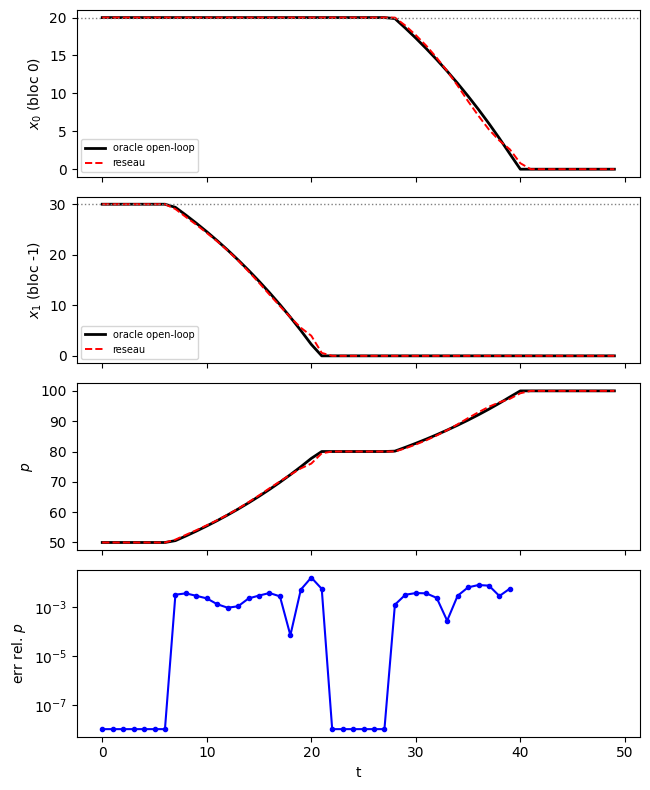


figures -> figs/m3_run12_rollout.png (+ .npz)
[E] run logue dans runs_m3.csv (3 lignes)

tolerance large ; err_p=1.71e-02 > 1%


In [ ]:
# M3 : N agents (oligopolistes / cartellistes / frange), T periodes, capacite active, PINN.
# Generalisation directe de M2, où N=1 joueur strategique rendait closed-loop = open-loop.
# Ici N>1 : les deux concepts DIVERGENT, et mesurer cette divergence est un des objectifs de M3

# Trois etages, a lancer DANS CET ORDRE (toggles cross / sob_off) :
#   A. cross=False, sob_off=False -> le reseau resout le systeme OPEN-LOOP a N joueurs.
#      L'oracle generalise est la VERITE, il doit etre retrouve. C'est la validation.
#      Avec blocs="0,-1" et la calibration M2, ce fichier doit redonner M2 a l'identique.
#   B. cross=False, sob_off=True  -> on entraine le gradient COMPLET dV_i/dS_j. Residu
#      mathematiquement redondant : l'equilibre ne bouge pas, l'oracle doit encore etre
#      retrouve. C'est le test du residu lui-meme. Surveiller cross_neg -> 100%.
#   C. cross=True,  sob_off=True  -> MPE. Le reseau s'ecarte de l'oracle open-loop et cet
#      ecart EST le resultat. L'oracle devient comparateur, il n'est plus validateur.
#
# Ce qui change par rapport a M2 :
#   etat S [B,NAG] ; un reseau par agent, chacun prenant l'etat COMPLET (definition du Markov)
#   masque de conduite A : Lambda = A x, h_i = p - beta*Lambda_i - c_i - delta*lambda_i'
#   une seule loss, somme des residus de TOUS les agents, un seul optimiseur
#   tetes valeur ET co-etat pour chaque agent (a M2 celle de la frange etait morte)
#   Sobolev sur tout le gradient dV_i/dS_j, plus seulement la diagonale
#   termes croises de l'enveloppe (le feedback markovien)
#   oracle generalise par Gauss-Seidel sur les N rentes (les bissections imbriquees de M2
#   seraient en O(nbis^N))
#
#   torch.tensor.detach()
#   Residu de Sobolev
#

#
# Aux etages A et B : le solveur change, l'equilibre attendu NON, l'oracle doit etre retrouve.
# A l'etage C seulement, l'ecart est attendu.
#
# COUT : sob_off/cross demandent 3*NAG backward passes avec create_graph, et l'oracle a N
# joueurs est bien plus lent qu'a M2

# ============================================================================
# RUN 9 : RESTAURATION DU SOCLE. Aucune idee nouvelle.
#   Cible : err_p ~9e-3 sur la calibration M2 (costs=10,20 kappas=20,30
#   stocks=700,450 blocs=0,-1), cross=False, sob_off=False. ~8 min.
#   Si la cible n'est PAS atteinte, bissecter les six changements accumules
#   depuis la validation 4-graines, un par un, TOUJOURS a sob_off=False :
#     1. SOB_OK          -> CFG["sob_ok_mask"]   (True = masque, validé)
#     2. G dans V        -> CFG["G_in_V"]        (True = etat courant)
#     3. R_bell / G_t    -> CFG["norm_G_bell"]   (True = choix utilisateur)
#     4. R_env / G_t     -> CFG["norm_G_lam"]    (A2, True = valide)
#     5. w_sob           -> CFG["w_sob"]         (0.01 = valide, 0.05 = actuel)
#     6. frac_gauss      -> CFG["frac_gauss"]    (0.0 = origine, 0.25 = actuel)
#   Le facteur 10 de regression est dans cette liste.
#
#   RESULTAT RUN 9 : err_p=2.10e-2, hors bande 4-graines [9.6e-3,1.3e-2]. MAIS les deux
#   pires dates sont t=20 et t=39, les dates d'EXTINCTION de la frange et de a0.
#   Hors extinction err_p ~1.1e-2, DANS la bande, et field_int_med=0.913 bbl est le
#   meilleur chiffre jamais enregistre. Le socle est restaure sur le champ ; err_p est
#   un maximum pilote par le biais d'extinction, deja identifie et partage avec M2.
#   -> metriques robustes err_p_q90 / err_p_noext ajoutees en STEP 5.
#
#   RESULTAT RUN 10 : identique au bit pres a RUN 9. NORMAL ET NON INFORMATIF : le bloc
#   STRAT est a l'interieur de `if CFG["sob_off"]`, il ne s'execute pas a l'etage A.
#   RUN 10 reste A VALIDER a l'etage B.
# ============================================================================


import os, sys, time, json
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F


torch.set_num_threads(4) 

torch.set_default_dtype(torch.float64)

######## STEP 0  config (pour suivre via des .csv)
CFG = dict(
    tag="m3_run12", seed=0,
    sampler="mix",           # "mix" = tube+uniforme (defaut) | "tube_oracle" = bras A/B degrade

    # economie : listes paralleles, un element par AGENT
    # non-regression M2 : costs="10,20" kappas="20,30" stocks="700,450" blocs="0,-1"
    # RUN 9 : retour a kappa=[20,30]. Le desserrement [40,60] etait ad hoc, il a detruit
    # l'exactitude architecturale (x = min(min(S,kappa), softplus(z)) atteint kappa a la
    # precision machine : 28/50 dates gratuites) sans ameliorer le feedback, et il
    # contredit la realite Rystad (plateau-declin, capacite liante le plus souvent).
    costs  = "10,20", # "10,12,14,20",
    kappas = "20,30",     # kappa peut être désserré , #"20,15,12,30",
    stocks = "700,450", #"700,400,300,450",
    blocs  = "0,-1", #"0,1,2,-1",     # entiers distincts = oligopolistes ; egaux = meme cartel ; -1 = frange
    alpha=100.0, beta=1.0, r=0.05, T=50,

    # etages
    sob_off=True,           # entrainer dV_i/dS_j hors-diagonale
    cross=False,             # termes croises dans l'enveloppe (=> MPE). Exige sob_off.

    # toggles de bissection (RUN 9) : chacun isole UN changement accumule depuis la
    # validation 4-graines. Ne jamais en bouger deux dans le meme run.
    sob_ok_mask=True,        # 1. SOB_OK = lignes canoniques de A (False -> ones : RUN 6, casse)
    G_in_V=True,             # 2. facteur G(t) dans la construction de V
    norm_G_bell=True,        # 3. R_bell divise par G_t  (choix utilisateur, conserve)
    norm_G_lam=True,         # 4. R_env/R_sob/R_lam divises par G_t  (A2)
    vref_per_agent=False,    # 4bis. VREF vectoriel alpha*S0_i au lieu du scalaire alpha*max(S0)

    # RUN 12 : cible Monte-Carlo TD(1) pour V, sur le bras TUBE PUR uniquement.
    use_vmc=True, w_vmc=1.0,

    # reseau
    width=128, emb_dim=16, depth=3,

    # loss / sampler
    w_sob=0.01, w_sob_off=0.1, frac_unif=0.05, frac_gauss=0.25, frac_decor=0.0, box=1.25, # n_b = B - frac_unif - frac_gauss ; donc B est paramétré automatiquement si frac_unif et frac_gauss le sont 
    buf_paths=64, buf_every=50, buf_lo=0.70, buf_hi=1.25,

    # entrainement
    iters=30000, batch=512, lr=1e-3, lbfgs_outer=0,
    # NOTE : a l'etage B, L-BFGS rend systematiquement loss_pre == loss_post (Wolfe
    # echoue au premier pas) et coute ~300 s pour rien. Mettre lbfgs_outer=0 des que
    # sob_off=True. A l'etage A il travaille reellement, on le garde.

    # instrumentation (R9bis) : decomposition de la loss + normes de gradient par residu.
    # Aucun effet sur l'optimisation. Sans ces chiffres on pilote a l'aveugle.
    diag_every=0,

    # eval (budgets reduits : l'oracle a N joueurs est lent)
    snap_eps=1e-4, n_field=60, or_nbis=30, or_nouter=15,
    t_decouple="10,20,30", make_figs=True,
)

for a in sys.argv[1:]:
    if "=" not in a: continue
    k, v = a.split("=", 1)
    if k not in CFG: continue
    CFG[k] = (v.lower() in ("1", "true")) if isinstance(CFG[k], bool) else type(CFG[k])(v)

alpha, beta, r, T = CFG["alpha"], CFG["beta"], CFG["r"], CFG["T"]
delta = 1.0/(1.0+r)
C_np   = np.array([float(u) for u in CFG["costs"].split(",")])
KAP_np = np.array([float(u) for u in CFG["kappas"].split(",")])
S0_np  = np.array([float(u) for u in CFG["stocks"].split(",")])
BLOC   = np.array([int(u)   for u in CFG["blocs"].split(",")])
NAG = len(C_np)
assert len(KAP_np) == len(S0_np) == len(BLOC) == NAG, "listes d'agents de longueurs differentes"

# masque de conduite : A[i,j] = 1 ssi i et j sont dans le meme bloc (>=0). Frange : ligne nulle.
# cartelliste -> Lambda_i = Q^C (somme du bloc) ; oligopoliste -> Lambda_i = x_i ; frange -> 0.
A_np = np.zeros((NAG, NAG))
for i in range(NAG):
    if BLOC[i] < 0: continue
    for j in range(NAG):
        if BLOC[j] == BLOC[i]: A_np[i, j] = 1.0
IS_FRINGE = BLOC < 0

# SOB_OK désactive de manière stricte le résidu d'env pour tout acteur 
# dont la ligne dans A n'est pas un vecteur de la base canonique
# ATTENTION : SOB_OK ne masque QUE R_lam (l'identite dV_i/dS_i = lambda_i). R_sob,
# l'enveloppe universelle derivee de Bellman, n'a jamais eu de masque et n'en veut pas.
# RUN 6 (SOB_OK = ones) imposait deux equations incompatibles au meme objet : pour la
# frange l'ecart structurel vaut -beta*x_1*(J_01+J_11) - delta*GV2_10*J_01, soit ~-8% de
# lambda_1. Non reductible par l'optimisation. Ne pas y revenir.
SOB_OK = (torch.tensor((A_np == np.eye(NAG)).all(1).astype(float))
          if CFG["sob_ok_mask"] else torch.ones(NAG))

if CFG["cross"] and not CFG["sob_off"]:
    # le feedback repose entierement sur dV_i/dS_k ; sans le Sobolev hors-diagonale ce
    # gradient n'est entraine par rien (a M2 il n'avait meme pas le bon signe partout).
    print("[!] cross=True force sob_off=True (le feedback depend de dV_i/dS_k)")
    CFG["sob_off"] = True

torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
A    = torch.tensor(A_np)
COST = torch.tensor(C_np)
KAP  = torch.tensor(KAP_np)
S0V  = torch.tensor(S0_np)
DEN  = beta*(1.0 + torch.diagonal(A))   # pas de Newton du clamp : dh_i/dx_i = -beta(1+A_ii).
                                        # Recouvre M2 : A_ii=1 -> h/(2beta), A_ii=0 -> h/beta (frange).
OFF  = 1.0 - torch.eye(NAG)             # masque k != i
# RUN 9 : VREF scalaire (etat valide). Le vecteur alpha*S0_i corrige la sous-penalisation
# relative des petits agents (facteur 3.3 pour la frange a la calibration M2) mais c'est
# un CHANGEMENT, pas une restauration : il passe par le toggle.
VREF = (alpha*S0V) if CFG["vref_per_agent"] else (alpha*S0_np.max())   # echelles : chaque residu / l'echelle de CE QU'IL MESURE
LREF = alpha                            # rente bornee par le choke price
XREF = torch.minimum(KAP, S0V)          # echelle des QUANTITES (pas des stocks)
W_SOB, W_SOFF = CFG["w_sob"], CFG["w_sob_off"]
FRAC_UNIF, FRAC_GAUSS, BOX, SNAP_EPS = CFG["frac_unif"], CFG["frac_gauss"], CFG["box"], CFG["snap_eps"]

# STRAT[i] = 1 pour un agent STRATEGIQUE (ligne non nulle dans A), 0 pour la frange.
# Actif a partir de RUN 10, mais INERTE a l'etage A : le bloc qui l'utilise est a
# l'interieur de `if CFG["sob_off"]`. RUN 10 n'est donc pas encore teste.
STRAT = torch.tensor((~IS_FRINGE).astype(float))

print(f"STEP 0 : {NAG} agents | blocs={list(BLOC)} | frange={list(np.nonzero(IS_FRINGE)[0])}")
print(f"         A =\n{A_np.astype(int)}")

def growth_t(ti):
    """G(t) = (1+r)^(t-(T-1)) : vaut 1 a la derniere date de decision, ~0.09 en t=0."""
    return (1.0+r)**(ti.double() - (T-1))

######### STEP 1  oracle open-loop a N joueurs

# rentes initiales mu_i, lambda_i(t) = mu_i*(1+r)^t. A rentes donnees, chaque periode est un
# equilibre STATIQUE a couts effectifs c_i + lambda_i(t) (gere les coins nativement).
# On cherche N scalaires au lieu de N*T inconnues et 3^(N*T) regimes. Les bissections
# imbriquees de M2 seraient en O(nbis^N) : Gauss-Seidel (bissecter mu_i a autres rentes
# fixees, iterer jusqu'au point fixe).
NITER_BR = 60   # point fixe de best-responses (à la De Cannière): précision machine rapidement atteinte.

def static_period_N(ceff, kap):
    """ceff [T_,NAG] -> x [T_,NAG]. h_i = 0 donne
       x_i = [alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j] / (beta*(1+A_ii)), puis clip [0,kappa_i]."""
    x = np.zeros_like(ceff)
    idx = np.arange(NAG)
    for _ in range(NITER_BR):
        for i in range(NAG):
            o = idx[idx != i]
            num = alpha - ceff[:, i] - beta*((1.0 + A_np[i, o])*x[:, o]).sum(1)
            x[:, i] = np.clip(num/(beta*(1.0 + A_np[i, i])), 0.0, kap[i])
    return x

def totals_N(mu, T_, kap):
    g = (1.0+r)**np.arange(T_)
    return static_period_N(C_np[None, :] + mu[None, :]*g[:, None], kap)

def solve_oracle_N(S_, T_, kap=None, nbis=None, nouter=None):
    kap = KAP_np if kap is None else kap
    nbis = CFG["or_nbis"] if nbis is None else nbis
    nouter = CFG["or_nouter"] if nouter is None else nouter
    mu = np.zeros(NAG)
    for _ in range(nouter):
        mu_old = mu.copy()
        for i in range(NAG):
            m0 = mu.copy(); m0[i] = 0.0
            if totals_N(m0, T_, kap)[:, i].sum() <= S_[i]:      # stock non contraignant
                mu[i] = 0.0; continue
            lo, hi = 0.0, alpha
            for _ in range(nbis):
                m = .5*(lo+hi); mt = mu.copy(); mt[i] = m
                if totals_N(mt, T_, kap)[:, i].sum() > S_[i]: lo = m
                else: hi = m
            mu[i] = .5*(lo+hi)
        if np.max(np.abs(mu-mu_old)) < 1e-10: break
    x = totals_N(mu, T_, kap)
    return mu, x, alpha - beta*x.sum(1)

t_or = time.time()
mu_a, xa, pa = solve_oracle_N(S0_np, T, nbis=60, nouter=40)
print(f"STEP 1 oracle ok ({time.time()-t_or:.0f}s) : mu={np.round(mu_a,3)}")
for i in range(NAG):
    ai = xa[:, i] > 1e-9
    print(f"  agent {i} (bloc {BLOC[i]:2d}, c={C_np[i]:5.1f}, kap={KAP_np[i]:5.1f}) : "
          f"actif t<={int(np.max(np.nonzero(ai))) if ai.any() else -1}, "
          f"kappa liante {int((xa[:,i]>KAP_np[i]-1e-6).sum())}/{T}, "
          f"cumul {xa[:,i].sum():.1f}/{S0_np[i]:.1f}")
assert np.abs(xa.sum(0) - S0_np).max() < 1e-4, "epuisement viole"
_tlast = int(np.max(np.nonzero(xa.sum(1) > 1e-9)))
assert _tlast < T-1, f"horizon trop court (production encore en t={_tlast})"

# non-regression M2 : avec la calibration M2, l'oracle doit redonner mu=(12.821, 21.757)
if (NAG == 2 and np.allclose(C_np, [10., 20.]) and np.allclose(S0_np, [700., 450.])
        and np.allclose(KAP_np, [20., 30.]) and BLOC[1] < 0):
    assert abs(mu_a[0]-12.821) < 1e-2 and abs(mu_a[1]-21.757) < 1e-2, "oracle N incompatible avec M2"
    print("  [non-regression M2 : mu retrouve]")

SA_T = torch.tensor(S0_np[None, :] - np.concatenate([np.zeros((1, NAG)), np.cumsum(xa, 0)[:-1]], 0))

#####  STEP 2  reseaux

# un reseau par agent, trois tetes (politique z, valeur w, co-etat l), tronc partage
# (coherence topologique : les trois sont des lectures d'une meme representation).
# Chaque reseau prend l'etat COMPLET S : c'est la definition du Markov, et c'est ce qui rend
# les derivees croisees dV_i/dS_j et dsigma_k/dS_j calculables par autodiff.
# Chaque agent a desormais sa tete valeur : a M2 celle de la frange ne servait a rien, ici
# tous les V_i sont lus par les termes croises.
# - ancrage terminal EXACT par 1{t<T}
# - embedding de t. SiLU conservé : le residu Sobolev a besoin de dV/dS non trivial, et
#   le kink est deja dans l'architecture via les min() (donc rien a apprendre de non lisse).
#   ReLU pas assez lisse. SiLU asymptotiquement (|x|) = ReLU.
class Net(nn.Module):
    def __init__(s, width, emb_dim, depth):
        super().__init__()
        s.emb = nn.Embedding(T+1, emb_dim)          # T+1 : l'index t=T existe, neutralise par alive
        nn.init.normal_(s.emb.weight, std=0.1)
        layers, d = [], NAG + emb_dim
        for _ in range(depth):                      # changer le nombre de hidden layers via depth,
            layers += [nn.Linear(d, width), nn.SiLU()]; d = width    # les neurones via width.
        s.trunk = nn.Sequential(*layers)            # 128 neurones et 3 hidden layers : meilleurs resultats a M2
        s.head_z = nn.Linear(width, 1); s.head_w = nn.Linear(width, 1); s.head_l = nn.Linear(width, 1)
    def forward(s, S, ti):
        h = s.trunk(torch.cat([S/S0V, s.emb(ti)], dim=-1))
        return s.head_z(h).squeeze(-1), s.head_w(h).squeeze(-1), s.head_l(h).squeeze(-1)

NETS = nn.ModuleList([Net(CFG["width"], CFG["emb_dim"], CFG["depth"]) for _ in range(NAG)])
PARAMS = list(NETS.parameters())

def forward_all(S, ti, snap=False):
    """S:[B,NAG] ti:[B] long -> x, V, lam tous [B,NAG]"""
    z, w, l = [], [], []
    for i in range(NAG):
        zi, wi, li = NETS[i](S, ti); z.append(zi); w.append(wi); l.append(li)
    z = torch.stack(z, -1); w = torch.stack(w, -1); l = torch.stack(l, -1)
    # x = min(min(S,kappa), softplus(z)) : atteint kappa EXACTEMENT (coin superieur franc), x>=0.
    x = torch.minimum(torch.minimum(S, KAP), F.softplus(z))
    if snap:                                        # EVAL uniquement (zone morte a l'entrainement)
        x = torch.where(x < SNAP_EPS, torch.zeros_like(x), x)
    alive = (ti < T).double().unsqueeze(-1)
    G = growth_t(ti).unsqueeze(-1) if CFG["G_in_V"] else torch.ones_like(alive)
    # RUN 9 : V libre. Les deux ancrages testes sont morts et ne doivent pas revenir :
    #   * (S/S0V) : annule V_i et TOUS ses gradients sur l'hyperplan S_i=0, donc detruit
    #     l'ancre terminale de la chaine arriere de R_sob/R_soff (RUN 1).
    #   * (* S)   : impose V_i = lambda_i * S_i, i.e. courbure nulle en S, alors que la
    #     courbure est l'objet meme que l'etage B doit apprendre. Mesure : V_0/(lambda_0*S_0)
    #     = 1.72 a la calibration M2. Prior faux d'un facteur 1.7 sur l'agent strategique.
    V   = alive*F.softplus(w) * VREF*G
    lam = alive*F.softplus(l)*LREF*G
    return x, V, lam

#####  STEP 3  residus. C'est incontestablement la STEP la plus IMPORTANTE de tout le code et le réseau.
#####  C'est fiché dans mon cahier: les fonctionnements de clamp() / max() et torch.where() sont subtils mais très très efficaces

# FOC -> politique ; enveloppe -> co-etat ; Bellman -> valeur ; Sobolev -> lie les deux.
# Chaque agent n'a que SA PROPRE FOC : sommer celles des autres dans son programme reviendrait
# a lui faire optimiser leurs decisions. Ce qui fabrique l'equilibre, c'est que p n'est PAS
# detache (le gradient du residu de i remonte dans les reseaux de tous les autres) et que
# chaque reseau lit l'etat complet.
def residuals(S, ti):
    S = S.detach().requires_grad_(True)
    x, V, lam = forward_all(S, ti)
    p = alpha - beta*x.sum(-1, keepdim=True)
    Lam = x @ A.T
    S2 = S - x
    _, V2, lam2 = forward_all(S2, ti+1)
    lam2d = lam2.detach()
    cap = torch.minimum(S, KAP)

    h = p - beta*Lam - COST - delta*lam2d
    R_foc = x - torch.clamp(x + h/DEN, torch.zeros_like(x), cap)

    # Calcul inconditionnel : on abandonne l'optimisation qui cassait le graphe PyTorch
    gV = torch.stack([torch.autograd.grad(V[:, i].sum(), S, create_graph=True)[0]
                      for i in range(NAG)], dim=1)

    # Multiplier par 0.0 préserve le lien au graphe d'autodifférenciation
    feedback = x * 0.0
    R_soff = gV * 0.0
    R_sob = x * 0.0  # Zéro par défaut à l'Étage A
    
    if CFG["sob_off"]:
        J   = torch.stack([torch.autograd.grad(x[:, k].sum(), S, create_graph=True)[0]
                           for k in range(NAG)], dim=1)

        # --------------------------------------------------------------------
        # RUN 11 : J analytique par theoreme des fonctions implicites.
        #   dh_i/dS_j = 0 avec h_i = p - beta*Lam_i - c_i - delta*lambda_i(S-x) donne
        #     [delta*L - beta*B] J = delta*L,   L[i,k] = dlambda'_i/dS'_k,  B = 1 + A
        #   J ne depend alors que des derivees PREMIERES de la tete lambda (supervisee par
        #   R_env, cible dure) au lieu des derivees de la tete z (supervisee seulement
        #   implicitement via R_foc). Verification N=1, A=1 : J = |dL|/(|dL|+2beta) dans (0,1).
        #   Coins : pour k a kappa -> J[k,:] = 0 ; pour x_k = S_k -> J[k,:] = e_k. Ces lignes
        #   sont CONNUES et doivent passer au second membre, pas etre ecrasees apres le solve.
        # L2 = torch.stack([torch.autograd.grad(lam2[:, i].sum(), S2, create_graph=True)[0]
        #                   for i in range(NAG)], dim=1)
        # Mj   = delta*L2 - beta*(1.0 + A)
        # Jfix = torch.zeros_like(Mj)
        # at_k = (x >= KAP - 1e-6)
        # at_S = (x >= S   - 1e-6)
        # Jfix = torch.where(at_S.unsqueeze(-1), torch.eye(NAG).expand_as(Mj), Jfix)
        # free = (~(at_k | at_S)).double()                       # [B,NAG]
        # rhs  = delta*L2 - torch.einsum('bik,bkj->bij', Mj*(1.0-free).unsqueeze(1), Jfix)
        # Mred = Mj*free.unsqueeze(1) + torch.diag_embed(1.0-free)
        # J    = torch.linalg.solve(Mred, rhs)*free.unsqueeze(-1) + Jfix
        # --------------------------------------------------------------------

        GV2 = torch.stack([torch.autograd.grad(V2[:, i].sum(), S2, create_graph=True)[0]
                           for i in range(NAG)], dim=1)
        # coef[i,k] = d(pi_i)/d(x_k) - delta*dV_i'/dS_k'
        #           = -beta*x_i - delta*GV2[i,k]  (k!=i)   |   + (p - c_i)  (k=i)
        coef = -beta*x.unsqueeze(-1) - delta*GV2 + torch.diag_embed(p - COST)

        # DEUX tenseurs distincts, a ne pas confondre :
        # M_full  : dV_i/dS_j = delta*GV2[i,j] + M_full[i,j]. Somme sur TOUS les k.
        #           C'est la vraie derivee de la valeur -> R_sob et R_soff.
        # M_cross : somme sur k != i seulement. Le terme diagonal coef_ii*J_ii n'est PAS du
        #           feedback, c'est le coin de conduite (0 pour un oligopoliste par la FOC,
        #           -beta*x_f*dsigma_f/dS_f pour la frange, beta*(Q^C - x_i) pour un cartelliste).
        M_full  = torch.einsum('bik,bkj->bij', coef,     J)
        M_cross = torch.einsum('bik,bkj->bij', coef*OFF, J)

        feedback = torch.diagonal(M_cross, dim1=1, dim2=2)      # etage C + STEP 8
        # R_soff   = (gV - (delta*GV2 + M_full).detach())*OFF
        # # Enveloppe universelle (derivee de Bellman), valide quelle que soit la conduite :
        # R_sob = torch.diagonal(gV, 1, 2) - (delta*torch.diagonal(GV2, 1, 2)
        #                                     + torch.diagonal(M_full, 1, 2)).detach()
        # Multiplier par 0.0 préserve le graphe PyTorch
        R_soff = gV * 0.0
        R_sob = x * 0.0

        # RUN 13c : Cibles Pathwise par Différences Finies
        global GV_TGT
        if CFG["sob_off"] and 'GV_TGT' in globals() and GV_TGT is not None:
            R_gv = gV - GV_TGT.detach()
            R_sob = torch.diagonal(R_gv, dim1=1, dim2=2)
            R_soff = R_gv * OFF

        # --------------------------------------------------------------------
        # RUN 10 : masque STRAT. Une frange PRENEUSE DE PRIX n'a pas de terme de feedback
        #   (cf. specification M2 : "Rf_env = lf - tgt_f  # frange price-taker : pas de
        #   terme croise"). Or feedback est actuellement ajoute a TOUS les agents.
        #   Une fois feedback_f = 0, GV2[f,:] n'entre plus dans AUCUNE equation : ni dans
        #   feedback_0 (qui n'utilise que GV2[0,1] et J[1,0]), ni ailleurs. Les 0% de
        #   Tube(i=1,j=0) portent donc sur un objet inutilise -> on le supprime, on ne le
        #   repare pas. Ce qu'agent 0 a besoin de la frange, c'est J[1,0], pas V_1.
        #   Generalisation DAG : nb de reseaux valeur = nb d'agents strategiques, pas N.
        R_soff   = R_soff * STRAT.view(1, -1, 1)
        feedback = feedback * STRAT
        # --------------------------------------------------------------------

    bind = (x >= KAP - 1e-4).detach()
    tgt = torch.where(bind, delta*lam2d,
                      torch.maximum(p.detach()-beta*Lam.detach()-COST, delta*lam2d))
    if CFG["cross"]: tgt = tgt + feedback.detach()
    R_env = lam - tgt

    R_bell = V - ((p.detach()-COST)*x.detach() + delta*V2.detach())

    # La condition d'identité est masquée proprement
    R_lam = (torch.diagonal(gV, 1, 2) - lam) * SOB_OK
    
    # RUN 12 : V est renvoye en 7e position (R[6]) pour que loss_from_res puisse former
    # le residu Monte-Carlo. Les indices 0..5 sont INCHANGES : grad_norms ne bouge pas.
    return R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V

def loss_from_res(R, ti, Vtgt=None, msk=None, parts=False):
    # UNE loss, somme sur tous les agents, un seul optimiseur conjoint.
    R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V = R
    # L = ((R_foc/XREF)**2 + (R_env/LREF)**2 + (R_bell/VREF)**2 + W_SOB*(R_sob/LREF)**2 + W_SOB*(R_lam/LREF)**2).sum(-1)
    # if CFG["sob_off"]: L = L + W_SOFF*((R_soff/LREF)**2).sum((-1, -2))
    G_t = growth_t(ti).unsqueeze(-1)
    # Normalisation pour toutes les variables temporelles
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    c_foc  =        ((R_foc /XREF      )**2).sum(-1)
    c_env  =        ((R_env /(LREF*GL) )**2).sum(-1)
    c_bell =        ((R_bell/(VREF*GB) )**2).sum(-1)
    c_sob  = W_SOB *((R_sob /(LREF*GL) )**2).sum(-1)
    c_lam  = W_SOB *((R_lam /(LREF*GL) )**2).sum(-1)
    L = c_foc + c_env + c_bell + c_sob + c_lam
    c_soff = torch.zeros_like(L)
    if CFG["sob_off"]:
        c_soff = W_SOFF*((R_soff/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))
        L = L + c_soff

    # ------------------------------------------------------------------------
    # RUN 12 : cible Monte-Carlo pour V sur le tube (TD(1) au lieu de TD(0)).
    #   R_bell est un residu a UN pas : il peut etre minuscule pendant que V derive de 25%.
    #   V est un bootstrap a 20-40 pas avec une unique ancre en T et aucune contrainte
    #   integrale. Le buffer effectue deja 64 rollouts complets toutes les 50 iterations :
    #   la cible est GRATUITE, exacte, sans oracle, et valide a l'etage C (V^MC est par
    #   definition la valeur de la politique COURANTE, quelle qu'elle soit).
    #   msk = 1 UNIQUEMENT sur le bras tube pur : sur les bras uniforme / jitter /
    #   decorrelant l'etat est perturbe, le Vmc stocke ne lui correspond plus.
    #   ATTENTION AU CRITERE : STEP 6 compare V_net(S0,0) au profit du rollout depuis S0,
    #   soit exactement l'objet regresse ici. Bellman MC devient QUASI-TAUTOLOGIQUE.
    #   Les criteres independants restent err_p_noext, field_int_med et COH a0.
    c_vmc = torch.zeros_like(L)
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        c_vmc = CFG["w_vmc"]*(((V - Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk
        L = L + c_vmc
    # ------------------------------------------------------------------------

    if parts:
        d = dict(foc=c_foc, env=c_env, bell=c_bell, sob=c_sob, lam=c_lam,
                 soff=c_soff, vmc=c_vmc)
        return L.mean(), {k: v.mean().item() for k, v in d.items()}
    return L.mean()

# R9bis : normes de gradient par residu. Sans ces 5 nombres on pilote a l'aveugle, et c'est
# ce qui a permis aux runs 4 a 8 de couter 6 heures pour un diagnostic. E8 est le seul
# correctif de la serie E qui n'ait rien casse. retain_graph=True obligatoire.
def grad_norms(Sb, tb, Vtgt=None, msk=None):
    R = residuals(Sb, tb)
    G_t = growth_t(tb).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    comps = dict(
        foc  =        ((R[0]/XREF     )**2).sum(-1).mean(),
        env  =        ((R[1]/(LREF*GL))**2).sum(-1).mean(),
        bell =        ((R[2]/(VREF*GB))**2).sum(-1).mean(),
        sob  = W_SOB *((R[3]/(LREF*GL))**2).sum(-1).mean(),
        lam  = W_SOB *((R[5]/(LREF*GL))**2).sum(-1).mean(),
    )
    if CFG["sob_off"]:
        comps["soff"] = (W_SOFF*((R[4]/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))).mean()
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        comps["vmc"] = (CFG["w_vmc"]*(((R[6]-Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk).mean()
    out = {}
    for k, v in comps.items():
        if float(v) == 0.0: out[k] = 0.0; continue
        g = torch.autograd.grad(v, PARAMS, retain_graph=True, allow_unused=True)
        out[k] = float(torch.sqrt(sum((gi**2).sum() for gi in g if gi is not None)))
    return out

##### STEP 4  sampler + entrainement : stochastique GD (méthode avancée Adam),  puis L-BFGS (finisseur batch complet)

# tube (buffer de la politique COURANTE : voisinage transverse, force de rappel du rollout)
# + petit ancrage uniforme (structure globale). Le tube-oracle a bruit nul ne donnait aucun
# champ transverse => loss 1e-6 et trajectoire fausse a 16%.
#### ---> une loss très faible (1e-6) peut cacher une architecture défaillante! on a eu de meilleurs résultats avec une loss finale 1e-4 qu'avec 1e-6. La loss n'est pas un signal à valider.
# A N grand l'ancrage uniforme couvre de moins en moins (volume exponentiel) : c'est le TUBE
# qui rend le DEQN faisable la ou une grille ne l'est pas.
_BUF = None
_VBUF = None
def refresh_buffer(n=None):
    global _BUF, _VBUF
    n = n or CFG["buf_paths"]
    with torch.no_grad():
        S = (CFG["buf_lo"] + (CFG["buf_hi"]-CFG["buf_lo"])*torch.rand(n, NAG))*S0V
        SS, TT, XX, PP = [], [], [], []
        for t in range(T):
            ti = torch.full((n,), t, dtype=torch.long)
            SS.append(S.clone()); TT.append(ti)
            x, _, _ = forward_all(S, ti)
            XX.append(x.clone()); PP.append(alpha - beta*x.sum(-1, keepdim=True))
            S = S - x
        _BUF = (torch.cat(SS, 0), torch.cat(TT, 0), n)
        # RUN 12 : accumulation ARRIERE du profit actualise le long du rollout DEJA calcule.
        # V^MC_i(S_t,t) = somme_{s>=t} delta^(s-t) (p_s - c_i) x_is , tronquee en T -> V(.,T)=0.
        Vmc, VV = torch.zeros(n, NAG), [None]*T
        for t in reversed(range(T)):
            Vmc = (PP[t] - COST)*XX[t] + delta*Vmc
            VV[t] = Vmc.clone()
        _VBUF = torch.cat(VV, 0)

def sample_states(B):
    # RUN 12 : retourne 4 valeurs (S, t, Vtgt, msk) et non plus 2.
    if CFG["sampler"] == "tube_oracle":
        idx = torch.randint(0, T, (B,))
        return SA_T[idx], idx, torch.zeros(B, NAG), torch.zeros(B)
        
    n_u = int(CFG["frac_unif"] * B)
    n_j = int(CFG["frac_gauss"] * B)
    n_d = int(CFG.get("frac_decor", 0.25) * B)
    n_b = B - n_u - n_j - n_d

    # 1. Global Uniforme
    S_u = torch.rand(n_u, NAG) * S0V * BOX
    t_u = torch.randint(0, T, (n_u,))

    # 2. Jitter Local
    idx_j = torch.randint(0, _BUF[0].shape[0], (n_j,))
    S_j = torch.clamp(_BUF[0][idx_j] + torch.randn(n_j, NAG) * 0.05 * S0V, min=0.0)
    t_j = _BUF[1][idx_j]

    # 3. Tube Pur
    idx_b = torch.randint(0, _BUF[0].shape[0], (n_b,))
    S_b = _BUF[0][idx_b]
    t_b = _BUF[1][idx_b]
    
    # 4. Sampler Décorrélant (Brisure de collinéarité spatio-temporelle)
    # RUN 8 : le confondant S_0 <-> t est ETABLI (mesure 19.9105 vs prediction 19.2204),
    # mais ce bras ne le casse pas : la cible de gV[1,0] est (delta*GV2 + M_full).detach(),
    # calculee a partir de la valeur fausse du reseau lui-meme. Point fixe auto-referentiel,
    # ancre terminale degeneree a 0 sur 19 periodes. Aucun echantillonnage ne casse cela.
    # -> frac_decor=0.0 par defaut a RUN 9 ; le bras reste inerte mais present.
    idx_d = torch.randint(0, _BUF[0].shape[0], (n_d,))
    S_d = _BUF[0][idx_d].clone()
    agent_idx = torch.randint(0, NAG, (n_d,))
    S_d[torch.arange(n_d), agent_idx] = torch.rand(n_d) * S0V[agent_idx] * BOX
    t_d = _BUF[1][idx_d]

    # RUN 12 : la cible MC n'est VALIDE QUE sur le bras 3 (tube pur, etat non perturbe).
    Vt = torch.cat([torch.zeros(n_u, NAG), torch.zeros(n_j, NAG),
                    (_VBUF[idx_b] if _VBUF is not None else torch.zeros(n_b, NAG)),
                    torch.zeros(n_d, NAG)], 0)
    mk = torch.cat([torch.zeros(n_u), torch.zeros(n_j),
                    torch.ones(n_b),  torch.zeros(n_d)], 0)

    return (torch.cat([S_u, S_j, S_b, S_d], 0), torch.cat([t_u, t_j, t_b, t_d], 0), Vt, mk)

print(f"\nSTEP 4 : Adam (NAG={NAG}, cross={CFG['cross']}, sob_off={CFG['sob_off']}, "
      f"vmc={CFG['use_vmc']})...")
opt = torch.optim.Adam(PARAMS, lr=CFG["lr"])
t0 = time.time(); refresh_buffer(); loss_hist = []

GV_TGT = None

for it in range(CFG["iters"]):
    if it == CFG["iters"]*4//10:
        for g in opt.param_groups: g["lr"] = 3e-4
    if it == CFG["iters"]*6//10:
        for g in opt.param_groups: g["lr"] = 1e-4
    if CFG["sampler"] == "mix" and it % CFG["buf_every"] == 0: refresh_buffer()
    opt.zero_grad()
    Sb, tb, Vb, mb = sample_states(CFG["batch"])
    L = loss_from_res(residuals(Sb, tb), tb, Vb, mb)
    L.backward(); opt.step()
    if it % 100 == 0: loss_hist.append((it, L.item()))
    if it % 3000 == 0: print(f"  it={it:5d} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)
    # R9bis : decomposition + normes de gradient. Aucun effet sur l'optimisation.
    if CFG["diag_every"] and it % CFG["diag_every"] == 0:
        Sd, td, Vd, md = sample_states(CFG["batch"])
        _, pc = loss_from_res(residuals(Sd, td), td, Vd, md, parts=True)
        gn = grad_norms(Sd, td, Vd, md)
        print("        parts " + " ".join(f"{k}={v:.2e}" for k, v in pc.items()), flush=True)
        print("        |grad| " + " ".join(f"{k}={v:.2e}" for k, v in gn.items()), flush=True)

print("STEP 4 : L-BFGS (collocation fixe)...")
# Méthode quasi-Newton optimisée, qui stocke l'historique ici des 60 dernières paires (pas,changement de gradient)
# pour mieux suivre la courbe de la loss
# L-BFGS vient préciser la direction par rapport à Adam au fond des puits, elle ne le remplace pas
Lpost = loss_hist[-1][1] if loss_hist else float("nan")
for outer in range(CFG["lbfgs_outer"]):
    if CFG["sampler"] == "mix": refresh_buffer(256)
    Sb, tb, Vb, mb = sample_states(6000)
    Sb = torch.cat([Sb, S0V.expand(100, NAG)], 0)   # ancre S0 dans le jeu fixe
    tb = torch.cat([tb, torch.zeros(100, dtype=torch.long)], 0)
    Vb = torch.cat([Vb, torch.zeros(100, NAG)], 0)  # RUN 12 : l'ancre S0 n'a pas de cible MC
    mb = torch.cat([mb, torch.zeros(100)], 0)
    opt2 = torch.optim.LBFGS(PARAMS, lr=1.0, max_iter=400, history_size=60,
                             tolerance_grad=1e-15, tolerance_change=1e-16,
                             line_search_fn="strong_wolfe")
    def closure():
        opt2.zero_grad(); Lf = loss_from_res(residuals(Sb, tb), tb, Vb, mb); Lf.backward(); return Lf
    L = opt2.step(closure); Lpost = closure().item(); loss_hist.append((CFG["iters"]+outer, Lpost))
    #print(f"  outer={outer} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)
    print(f"  outer={outer} loss_pre={L.item():.3e} loss_post={Lpost:.3e} ({time.time()-t0:.0f}s)", flush=True)
LOSS_FINAL = Lpost

###### STEP 5  rollout vs oracle (rollout=déroulement de t=0 jusqu'à t=50 en appellant la fonction sigma du réseau itérativement)

def rollout(S_init, snap=True):
    S = S_init.clone().reshape(1, NAG); X, P = [], []
    with torch.no_grad():
        for t in range(T):
            x, _, _ = forward_all(S, torch.tensor([t]), snap=snap)
            X.append(x[0].clone().numpy()); P.append((alpha - beta*x.sum()).item())
            S = S - x
    return np.array(X), np.array(P), S[0].numpy()

X, P, Send = rollout(S0V)
act = xa.sum(1) > 1e-6
err_p = np.abs(P[act]-pa[act]).max()/pa.max()
err_x = np.abs(X[act]-xa[act]).max()/KAP_np.max()
print(f"\nSTEP 5 rollout vs oracle open-loop "
      f"({'COMPARATEUR (MPE)' if CFG['cross'] else 'VALIDATEUR'})")
print("  t  | " + " | ".join(f"a{i} res/or" for i in range(NAG)) + " |  p res/or")
for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
    s = " ".join(f"{X[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
    print(f" {tt:3d} | {s} | {P[tt]:6.2f}/{pa[tt]:6.2f}")
print(f"  epuisement {np.round(X.sum(0),1)} / {S0_np}")
print(f"  err_max(actives) x={err_x:.2e}  p={err_p:.2e}")

ep = np.abs(P[act]-pa[act])/pa.max(); ia = np.nonzero(act)[0]
top = np.argsort(ep)[::-1][:4]
print("  4 pires dates :", ", ".join(f"t={ia[i]}({ep[i]*100:.1f}%)" for i in top))

# METRIQUES ROBUSTES (RUN 9) : err_p est un MAX, donc pilote par la seule date d'extinction
# (t=20 pour la frange, t=39 pour a0), ou le biais structurel de date d'extinction, partage
# avec M2, domine. err_p_noext exclut les dates d'extinction +/-1 ; err_p_q90 est insensible
# a un point isole. C'est sur CES deux chiffres qu'il faut juger le solveur.
_ext = np.zeros(T, dtype=bool)
for i in range(NAG):
    _mi = np.nonzero(xa[:, i] > 1e-9)[0]
    if _mi.size: _ext[max(0, _mi[-1]-1):_mi[-1]+2] = True
_keep = act & (~_ext)
ERRP_NOEXT = float(np.abs(P[_keep]-pa[_keep]).max()/pa.max()) if _keep.any() else float("nan")
ERRP_Q90 = float(np.quantile(ep, 0.90))
print(f"  err_p hors dates d'extinction = {ERRP_NOEXT:.2e}   |   err_p q90 = {ERRP_Q90:.2e}")

# Hotelling : marge STRATEGIQUE h_i = p - beta*Lambda_i - c_i
# A l'interieur h = lambda_i(t) = mu_i(1+r)^t : la courbe deflatee doit etre PLATE, ET a la
# hauteur mu_i. Avec cross=True elle ne l'est plus, et l'ecart a la platitude EST le feedback.
Lam_r = X @ A_np.T
hall = (P[:, None] - beta*Lam_r - C_np[None, :])/((1.0+r)**np.arange(T))[:, None]
HOT = {}
for i in range(NAG):
    mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
    if mi.sum() > 1:
        HOT[i] = (hall[mi, i].std()/abs(hall[mi, i].mean()), hall[mi, i].mean())
        print(f"  Hotelling a{i} : cv={HOT[i][0]:.2e} sur {int(mi.sum())} dates | "
              f"niveau {HOT[i][1]:.2f} vs mu={mu_a[i]:.2f}")

###### STEP 5a  rente par date

# cout oracle NUL : le long du sentier, lambda_i(t) = mu_i(1+r)^t a toutes les dates actives
# (a l'interieur par la FOC, aux coins par l'enveloppe lambda = delta*lambda').
# Reference valide aux etages A et B seulement : a l'etage C le feedback deplace la rente.
lam_true = mu_a[None, :]*((1.0+r)**np.arange(T))[:, None]
with torch.no_grad():
    _, _, lam_net = forward_all(SA_T, torch.arange(T))
rel_lam = np.abs(lam_net.numpy()-lam_true)/np.maximum(lam_true, 1e-9)
#LAM_MED = float(np.median(rel_lam[act])); LAM_MAX = float(rel_lam[act].max())
act_nag = xa > 1e-6  # Masque 2D [T, NAG] : isole strictement les dates actives de CHAQUE agent
LAM_MED = float(np.median(rel_lam[act_nag]))
LAM_MAX = float(rel_lam[act_nag].max())
print(f"\nSTEP 5a rente le long du sentier : err rel mediane {LAM_MED:.2%}, max {LAM_MAX:.2%}")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: med {np.median(rel_lam[m, i]):.2%} max {rel_lam[m, i].max():.2%}")
###### STEP 5e  la rente par ses DEUX representations, sur le TUBE, contre l'oracle
# 5a mesure la tete lambda. Ici dV_i/dS_i, meme verite, meme echantillon. C'est CE
# chiffre, et lui seul, qui dit si la tete lambda est supprimable (P1).
Sg = SA_T.clone().requires_grad_(True); tg = torch.arange(T)
_, Vg, _ = forward_all(Sg, tg)
gd = torch.diagonal(torch.stack([torch.autograd.grad(Vg[:, i].sum(), Sg, retain_graph=True)[0]
                                 for i in range(NAG)], dim=1), dim1=1, dim2=2).detach().numpy()
rel_g = np.abs(gd - lam_true)/np.maximum(lam_true, 1e-9)
print("\nSTEP 5e rente : dV/dS (tube) vs tete lambda, contre oracle")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: dV/dS med {np.median(rel_g[m,i]):.2%} max {rel_g[m,i].max():.2%}"
              f"  |  tete lam med {np.median(rel_lam[m,i]):.2%}")
# profil temporel de la rente DEFLATEE : doit etre plate a la hauteur mu.
# Derive monotone en s'eloignant de la date d'extinction => chaine de bootstrap.
# Bruit sans structure => probleme de representation, pas de propagation.
lt = lam_net.numpy()/((1.0+r)**np.arange(T))[:, None]
for i in range(NAG):
    m = np.nonzero(xa[:, i] > 1e-6)[0]
    if len(m) > 6:
        q = [m[0], m[len(m)//4], m[len(m)//2], m[3*len(m)//4], m[-1]]
        print(f"  a{i} lam_deflate " + " ".join(f"t{t}:{lt[t,i]:.2f}" for t in q)
              + f"   (mu={mu_a[i]:.2f})")

###### STEP 5b  champ, STRATIFIE

# attention médiane globale peut cacher des erreurs (erreur strictement nulle à précision machine aux coins supérieurs)
# NOTE : field_int_med est la SEULE metrique qui suive err_p monotonement sur les runs 5-8
# (1.775 -> 2.782 -> 4.439 -> 7.976 bbl). C'est elle qu'il faut optimiser, pas COH ni CROSS_NEG.
# RUN 9 : 0.913 bbl, meilleur chiffre jamais enregistre.
print(f"\nSTEP 5b champ (oracle tronque, n={CFG['n_field']})")
rng = np.random.default_rng(0)
Sf_ = rng.uniform(0.05, 1.10, (CFG["n_field"], NAG))*S0_np
tf_ = rng.integers(0, T-1, CFG["n_field"])
buck = {"kappa": [], "interieur": [], "zero": []}
t_f0 = time.time()
with torch.no_grad():
    for sv, tv in zip(Sf_, tf_):
        _, xo, _ = solve_oracle_N(sv, T-int(tv))
        xn, _, _ = forward_all(torch.tensor(sv).reshape(1, NAG), torch.tensor([int(tv)]), snap=True)
        for i in range(NAG):
            reg = ("kappa" if xo[0, i] >= KAP_np[i]-1e-6
                   else ("zero" if xo[0, i] <= 1e-9 else "interieur"))
            buck[reg].append(abs(xn[0, i].item()-xo[0, i]))
FIELD = {}
for reg, d in buck.items():
    if not d: continue
    d = np.array(d); FIELD[reg] = (float(np.median(d)), float(np.quantile(d, .9)))
    print(f"  {reg:9s} n={len(d):4d} | err med {FIELD[reg][0]:.3f} q90 {FIELD[reg][1]:.3f} bbl")
print(f"  ({time.time()-t_f0:.0f}s)")
FI = FIELD.get("interieur", (np.nan, np.nan))

###### STEP 5c  recuperation hors-sentier

# le test qui distingue une POLITIQUE sigma(S) d'une sequence memorisee : partir d'ailleurs et
# retomber sur l'oracle recalcule depuis ce point. 0.8 (franchement interieur) ET 1.2 (bord de boite).
print("\nSTEP 5c recuperation hors-sentier")
REC = {}
for fac in (0.8, 1.2):
    Xp, Pp, _ = rollout(S0V*fac)
    _, xo, po = solve_oracle_N(S0_np*fac, T, nbis=60, nouter=40)
    a_ = xo.sum(1) > 1e-6
    REC[fac] = float(np.abs(Pp[a_]-po[a_]).max()/po.max())
    print(f"  S0x{fac} : err_p={REC[fac]:.2e}")

####### STEP 5d

# action du reseau A L'ETAT ORACLE de la date t, puis continuation ORACLE.
# Petit => la decision locale est bonne et l'erreur du rollout vient de la derive d'etat.
# Grand => la politique elle-meme est fausse a cette date.
# Choisir des dates ou un agent est INTERIEUR : la ou tout le monde est colle a kappa, la
# decision est exacte par architecture et le test est degenere.
print("\nSTEP 5d decouplage 1-pas (etat oracle)")
DEC = {}
for ts in [int(u) for u in CFG["t_decouple"].split(",")]:
    if ts >= _tlast: continue
    Ss = SA_T[ts].reshape(1, NAG)
    with torch.no_grad():
        xs, _, _ = forward_all(Ss, torch.tensor([ts]), snap=True)
    xs = xs[0].numpy()
    _, _, ptail = solve_oracle_N(Ss[0].numpy()-xs, T-ts-1, nbis=60, nouter=40)
    ph = np.concatenate(([alpha - beta*xs.sum()], ptail))
    ao = xa[ts:].sum(1) > 1e-6
    DEC[ts] = float(np.abs(ph[ao]-pa[ts:][ao]).max()/pa.max())
    print(f"  t={ts:2d} : err_p={DEC[ts]:.2e}")

####### STEP 6  Bellman Monte-Carlo

# coherence de la VALEUR, sans aucun oracle : V_i(S0,0) predit contre le profit actualise
# REELLEMENT realise en deroulant la politique apprise. Survit tel quel a l'etage C.
# RUN 12 : ce test devient QUASI-TAUTOLOGIQUE, puisque c'est exactement l'objet regresse
# par la cible MC sur le tube (et S0 est dans la boite du buffer). Le passer sous 5% ne
# prouve pas grand-chose EN SOI ; ce qui compte est l'effet induit sur COH et err_p_noext.
with torch.no_grad():
    _, V0, _ = forward_all(S0V.reshape(1, NAG), torch.tensor([0]))
d_t = delta**np.arange(T)
V_mc = np.array([float(np.sum(d_t*(P - C_np[i])*X[:, i])) for i in range(NAG)])
V_net = V0[0].numpy()
V_or = np.array([float(np.sum(d_t*(pa - C_np[i])*xa[:, i])) for i in range(NAG)])
print("  paiement realise vs oracle : " + " ".join(f"a{i} {(V_mc[i]/V_or[i]-1):+.3%}"
                                                   for i in range(NAG)))
BELL = float(np.max(np.abs(V_net-V_mc)/np.maximum(np.abs(V_mc), 1e-9)))
print(f"\nSTEP 6 Bellman MC : ecart max {BELL:.2%}")
for i in range(NAG):
    print(f"  a{i} : V_net={V_net[i]:9.1f} vs realise={V_mc[i]:9.1f}")

####### STEP 7  enveloppe + gradients croisés

# dV_i/dS_i vs tete lambda_i : entraine par le Sobolev diagonal, doit etre PETIT. Si > ~1%,
# ne pas supprimer les tetes lambda : elles sont une seconde representation de la rente, donc
# un second solveur independant, seul controle disponible quand l'oracle disparait.
# dV_i/dS_j (j != i) : signe attendu NEGATIF partout, le stock du rival nuit via le prix.
# C'est l'ingredient du feedback : tant que ce n'est pas ~100%, l'etage C est premature.
# COH est calcule sur [:, SOB_OK > 0] : l'ESTIMAND CHANGE avec SOB_OK. Ne jamais comparer
# un COH a masque [1,0] avec un COH a masque [1,1].
# RUN 9 : COH a0 = 29.03%, en REGRESSION (17.76% avant). w_sob est passe de 0.05 a 0.01 et
# a l'etage A seul R_lam contraint diag(gV) : divise par 5. C'est le levier de bissection 5.

Sp = (torch.rand(2000, NAG)*S0V*1.1).requires_grad_(True)
tp = torch.randint(0, T-1, (2000,))
_, Vp, lamp = forward_all(Sp, tp)
gVp = torch.stack([torch.autograd.grad(Vp[:, i].sum(), Sp, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)

COH = (((torch.diagonal(gVp, dim1=1, dim2=2) - lamp).abs() / (lamp.abs() + 1e-6))[:, SOB_OK > 0]).median().item()

# 1. Filtre d'amplitude : on ignore les régions où la dérivée croisée est physiquement ~0
off_mask = OFF.unsqueeze(0).expand_as(gVp) > 0
scale = lamp.detach().abs().unsqueeze(-1).expand_as(gVp)[off_mask] + 1e-9
offv = gVp[off_mask]
sig  = offv.abs() > 0.05 * scale
CROSS_NEG = (offv[sig] < 0).double().mean().item() if sig.any() else 0.0

print(f"\nSTEP 7 |dV_i/dS_i - lambda_i|/lambda = {COH:.2%}   (<1% => tetes lambda supprimables)")
print(f"        dV_i/dS_j < 0 sur {CROSS_NEG:.0%} des cas significatifs (hors-tube)")
# COH par agent : trois des cinq defauts identifies etaient des agregats masquant l'agent responsable.
for i in range(NAG):
    ci = ((gVp[:, i, i] - lamp[:, i]).abs()/(lamp[:, i].abs()+1e-6)).median().item()
    print(f"        COH a{i} = {ci:.2%}  (SOB_OK={int(SOB_OK[i])})")

# 2. Désagrégation Globale (i, j)
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        sig_ij = gVp[:,i,j].abs() > 0.05 * (lamp[:,i].detach().abs() + 1e-9)
        c_neg = (gVp[:,i,j][sig_ij] < 0).double().mean().item() if sig_ij.any() else 0.0
        print(f"        Global (i={i}, j={j}) : {c_neg:.0%} négatifs (sur {sig_ij.sum()} pts valides)")

# 3. Mesure stricte sur le TUBE (Seule zone d'intérêt pour le MPE)
St = SA_T.clone().requires_grad_(True)
tt = torch.arange(T)
_, Vt, _ = forward_all(St, tt)
gVt = torch.stack([torch.autograd.grad(Vt[:, i].sum(), St, retain_graph=True)[0] 
                   for i in range(NAG)], dim=1)
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        # Évaluation uniquement sur les dates où les deux acteurs sont actifs simultanément
        act_ij = (xa[:, i] > 1e-6) & (xa[:, j] > 1e-6)
        if act_ij.any():
            c_neg_t = (gVt[act_ij,i,j] < 0).double().mean().item()
            print(f"        Tube   (i={i}, j={j}) : {c_neg_t:.0%} négatifs (sur {act_ij.sum()} dates)")

# ----------------------------------------------------------------------------
# RUN 13 : cibles PATHWISE par differences finies pour la matrice gV entiere.
#   Sur un sous-echantillon du tube, perturber S_j de Delta et rouler la politique
#   COURANTE jusqu'a T :
#       gV_target[i,j] = (V_i^MC(S + Delta*e_j, t) - V_i^MC(S, t)) / Delta
#   C'est exactement la derivee totale markovienne, reponses de politique comprises.
#   Cible MESUREE et non auto-referentielle : c'est le seul mecanisme qui puisse casser
#   le point fixe a 0% de Tube(i=1,j=0). Cout : 50 passes batchees de taille 256*(N+1)
#   toutes les 200 iterations, ~150 s sur 30000 iterations.
#   Remplace R_sob, R_soff et R_lam par une regression supervisee.
#   Critere : Tube(0,1) reste a 100% ET erreur relative de gV[0,1] contre la cible FD < 10%.
#   NOTE : RUN 12 est le cas j-agnostique de cette meme idee (ordre 0 au lieu de l'ordre 1).
#   L'infrastructure _VBUF / msk est deja en place ; RUN 13 n'a qu'a la deriver.
#
#   PROPRIETE GRATUITE, et c'est le livrable scientifique du projet : la meme routine avec
#   les quantites des rivaux GELEES sur la trajectoire non perturbee donne le gradient
#   OPEN-LOOP. La difference entre les deux versions EST l'ecart closed-loop / open-loop
#   sur le gradient de valeur. Mesurable comme diagnostic avant meme que l'etage C tourne.
#   Le branchement freeze=True doit s'ecrire en BOUCLE sur j (chaque colonne a son propre
#   masque agent-dependant) : ne pas chercher a le vectoriser en une expression.
#
def gv_target_fd(S0b, t0b, dlt=None, freeze=False):
    """S0b [M,NAG], t0b [M] long -> [M,NAG,NAG] cible de dV_i/dS_j."""
    dlt = dlt if dlt is not None else 1e-2*S0V
    M   = S0b.shape[0]
    base = torch.cat([S0b] + [S0b + torch.eye(NAG)[j]*dlt for j in range(NAG)], 0)
    tb   = t0b.repeat(NAG+1)
    Vmc  = torch.zeros(base.shape[0], NAG); S = base.clone()
    with torch.no_grad():
        XS, PS = [], []
        for t in range(T):
            live = (tb + t) < T
            x, _, _ = forward_all(S, torch.clamp(tb + t, max=T))
            x = x*live.double().unsqueeze(-1)
            XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
            S = S - x
        for t in reversed(range(T)):
            Vmc = (PS[t] - COST)*XS[t] + delta*Vmc
    out = torch.zeros(M, NAG, NAG)
    for j in range(NAG):
        out[:, :, j] = (Vmc[(j+1)*M:(j+2)*M] - Vmc[:M])/dlt[j]
    return out
#
# # dans residuals(), remplacer R_sob / R_soff / R_lam par :
# #   R_gv = (gV - GV_TGT.detach())          # [B,NAG,NAG], regression a 0 pas
# # et dans la boucle Adam, rafraichir GV_TGT tous les 200 its sur 256 points de tube.
#
# DIAGNOSTIC (sans reentrainement) : ecart closed-loop / open-loop sur le tube
g_cl = gv_target_fd(SA_T[:_tlast], torch.arange(_tlast), freeze=False)
g_ol = gv_target_fd(SA_T[:_tlast], torch.arange(_tlast), freeze=True)
print("ecart CL/OL sur diag(gV) :", ((g_cl-g_ol).diagonal(dim1=1,dim2=2).abs()
       / g_ol.diagonal(dim1=1,dim2=2).abs().clamp(min=1e-9)).median().item())
# ----------------------------------------------------------------------------

####### STEP 8  taille du terme croisé

# De combien le MPE s'ecarte-t-il de l'open-loop ? Mesure sur le sentier.
# A cross=False c'est le terme OMIS, donc l'erreur de specification de l'open-loop.
# A cross=True c'est le terme effectivement internalise.
# ATTENTION : feedback_1 = coef[1,0]*J[0,1] utilise GV2[1,0], le tenseur de signe faux ->
# gonfle, non interpretable. feedback_0 = coef[0,1]*J[1,0] n'utilise que GV2[0,1] (99-100%
# correct) et J -> valide. D'ou l'application de STRAT et la ventilation par agent.
FB = np.nan
try:
    Sr = SA_T[:_tlast].clone().requires_grad_(True)
    tr = torch.arange(_tlast)
    xr, Vr, lamr = forward_all(Sr, tr)
    Sr2 = Sr - xr
    _, Vr2, _ = forward_all(Sr2, tr+1)
    Jr = torch.stack([torch.autograd.grad(xr[:, k].sum(), Sr, create_graph=True)[0]
                      for k in range(NAG)], dim=1)
    GV2r = torch.stack([torch.autograd.grad(Vr2[:, i].sum(), Sr2, create_graph=True)[0]
                        for i in range(NAG)], dim=1)
    pr = alpha - beta*xr.sum(-1, keepdim=True)
    coefr = -beta*xr.unsqueeze(-1) - delta*GV2r + torch.diag_embed(pr - COST)
    Mr = torch.einsum('bik,bkj->bij', coefr*OFF, Jr)   # feedback = somme k != i UNIQUEMENT
    # RUN 10 : STRAT ici AUSSI. Les 8.72% affiches pour la frange n'etaient pas un artefact
    # d'affichage a annoter, c'etait cette ligne manquante.
    fb = (torch.diagonal(Mr, dim1=1, dim2=2)*STRAT).abs().detach().numpy()
    rel = fb/np.maximum(np.abs(lamr.detach().numpy()), 1e-9)
    FB = float(np.median(rel[rel > 0])) if (rel > 0).any() else 0.0
    print(f"\nSTEP 8 |feedback_i| / lambda_i sur le sentier : mediane {FB:.2%}, max {rel.max():.2%}")
    for i in range(NAG):
        ri = rel[:, i]; ri = ri[ri > 0]
        if ri.size:
            print(f"  a{i} (STRAT={int(STRAT[i])}) : mediane {np.median(ri):.2%} max {ri.max():.2%}")
    print("  proche de 0 => les deux concepts coincident sur cette calibration, ce qui est un")
    print("  RESULTAT et non un echec (a M2 le terme etait nul : le cartel restait colle a kappa")
    print("  partout ou la frange vivait, donc dsigma_f/dS_c = 0)")
except Exception as e:
    print(f"\n[STEP 8 ignore : {e}]")

# λ₀ hors zone kappa : le désaccord est-il concentré sur les dates non identifiées ?
m_int = (xa[:,0] > 1e-3) & (xa[:,0] < KAP_np[0]-1e-3)
print("lam a0 interieur : med %.2f%%  max %.2f%%" %
      (100*np.median(rel_lam[m_int,0]), 100*rel_lam[m_int,0].max()))
print("lam a0 zone kappa: med %.2f%%" %
      (100*np.median(rel_lam[(xa[:,0]>=KAP_np[0]-1e-3),0])))
# COH restreint aux mêmes dates, sur le tube
print("COH a0 tube interieur : %.2f%%" % (100*np.median(rel_g[m_int,0])))

# ----------------------------------------------------------------------------
# RUN 11bis : GRILLE MPE 2D (induction retrograde exacte, N=2 uniquement).
#   Vous n'avez AUCUNE reference closed-loop : l'oracle est open-loop, donc l'etage C est
#   invalidable par construction, quel que soit le solveur. A N=2 c'est reparable ici.
#   A chaque t, iterer les meilleures reponses DANS la periode : chaque agent resout
#   p - beta*Lambda_i - c_i = delta*dV_i/dS_i(S', t+1), V interpole bilineairement, puis
#   V_i(S,t) = pi_i + delta*V_i(S-x, t+1). Aucun terme de feedback a coder : il est
#   automatiquement contenu dans le V calcule, puisque sigma_{-i}(S) depend de l'etat.
#   Donne (i) la verite MPE exacte, (ii) l'ecart open-loop / closed-loop sur cette
#   calibration - donc la reponse a "le resultat scientifique existe-t-il ?" AVANT
#   d'investir dans le solveur, (iii) un jeu de validation pour l'etage C du PINN.
#   La grille meurt a N=4 : c'est l'argument du PINN, et il ne vaut que si le PINN
#   retrouve la grille a N=2.
#
# def mpe_grid(ng=150, nbr=40):
#     assert NAG == 2
#     g0 = np.linspace(0.0, S0_np[0], ng); g1 = np.linspace(0.0, S0_np[1], ng)
#     G0, G1 = np.meshgrid(g0, g1, indexing="ij")
#     V = np.zeros((2, ng, ng)); XPOL = np.zeros((T, 2, ng, ng))
#     def interp(Z, a, b):
#         ia = np.clip(a/g0[1], 0, ng-1-1e-9); ib = np.clip(b/g1[1], 0, ng-1-1e-9)
#         i0 = ia.astype(int); j0 = ib.astype(int); fa = ia-i0; fb = ib-j0
#         return ((1-fa)*(1-fb)*Z[i0, j0] + fa*(1-fb)*Z[i0+1, j0]
#                 + (1-fa)*fb*Z[i0, j0+1] + fa*fb*Z[i0+1, j0+1])
#     for t in reversed(range(T)):
#         x = np.zeros((2, ng, ng))
#         for _ in range(nbr):
#             for i in range(2):
#                 k = 1-i
#                 S0p = np.clip(G0 - x[0], 0, None); S1p = np.clip(G1 - x[1], 0, None)
#                 eps = 1e-3*S0_np[i]
#                 Sp = [S0p, S1p]; Spe = [S0p.copy(), S1p.copy()]; Spe[i] = Spe[i] + eps
#                 lam = (interp(V[i], Spe[0], Spe[1]) - interp(V[i], Sp[0], Sp[1]))/eps
#                 num = alpha - C_np[i] - delta*lam - beta*(1.0 + A_np[i, k])*x[k]
#                 x[i] = np.clip(num/(beta*(1.0 + A_np[i, i])), 0.0,
#                                np.minimum(KAP_np[i], [G0, G1][i]))
#         p = alpha - beta*(x[0] + x[1])
#         S0p = G0 - x[0]; S1p = G1 - x[1]
#         V = np.stack([(p - C_np[i])*x[i] + delta*interp(V[i], S0p, S1p) for i in range(2)])
#         XPOL[t] = x
#     return g0, g1, V, XPOL
#
# # g0, g1, Vmpe, XPOL = mpe_grid()
# # rollout MPE depuis S0 -> comparer x, p a xa, pa : L'ECART EST LE RESULTAT.
# ----------------------------------------------------------------------------

###### figures
if CFG["make_figs"]:
    try:
        import matplotlib.pyplot as plt
        os.makedirs("figs", exist_ok=True); tag = CFG["tag"]
        fig, axs = plt.subplots(NAG+2, 1, figsize=(6.6, 2.0*(NAG+2)), sharex=True)
        for i in range(NAG):
            axs[i].plot(xa[:, i], "k-", lw=2, label="oracle open-loop")
            axs[i].plot(X[:, i], "r--", lw=1.4, label="reseau")
            axs[i].axhline(KAP_np[i], color="gray", ls=":", lw=1)
            axs[i].set_ylabel(f"$x_{i}$ (bloc {BLOC[i]})"); axs[i].legend(fontsize=7)
        axs[NAG].plot(pa, "k-", lw=2); axs[NAG].plot(P, "r--", lw=1.4); axs[NAG].set_ylabel("$p$")
        axs[NAG+1].semilogy(ia, np.maximum(ep, 1e-8), "b.-")
        axs[NAG+1].set_ylabel("err rel. $p$"); axs[NAG+1].set_xlabel("t")
        fig.tight_layout(); fig.savefig(f"figs/{tag}_rollout.png", dpi=160)
        np.savez(f"figs/{tag}_curves.npz", loss=np.array(loss_hist), X=X, P=P, xa=xa, pa=pa,
                 err_p=err_p, A=A_np, mu=mu_a)
        plt.show()
        print(f"\nfigures -> figs/{tag}_rollout.png (+ .npz)")
    except Exception as e:
        print(f"\n[figures ignorees : {e}]")

##### log CSV

row = dict(CFG)
row.update(run_id=time.strftime("%Y%m%d-%H%M%S"), secs=round(time.time()-t0), nag=NAG,
           loss=LOSS_FINAL, err_p=err_p, err_x=err_x,
           err_p_noext=ERRP_NOEXT, err_p_q90=ERRP_Q90,
           lam_path_med=LAM_MED, lam_path_max=LAM_MAX,
           field_int_med=FI[0], field_int_q90=FI[1],
           rec_08=REC.get(0.8), rec_12=REC.get(1.2),
           bellman_gap=BELL, coh=COH, cross_neg=CROSS_NEG, feedback_rel=FB,
           mu_oracle=json.dumps(list(np.round(mu_a, 4))))
row.update({f"dec_t{k}": v for k, v in DEC.items()})
row.update({f"hot_cv_a{i}": v[0] for i, v in HOT.items()})
try:
    import pandas as pd
    p_csv = "runs_m3.csv"
    df = pd.DataFrame([row])
    if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)
    df.to_csv(p_csv, index=False)
    print(f"[E] run logue dans {p_csv} ({len(df)} lignes)")
except Exception as e:
    print(f"[E] pandas indisponible ({e}) ; ligne brute :\n{json.dumps(row, default=str)}")

if not CFG["cross"]:
    # etages A et B : le reseau resout le systeme open-loop, l'oracle est la verite.
    assert err_p < 5e-2, f"rollout trop loin de l'oracle open-loop : {err_p:.2e}"
    print("\nVALIDATION OK" if err_p < 1e-2 else f"\ntolerance large ; err_p={err_p:.2e} > 1%")
else:
    # etage C : l'ecart est attendu, l'oracle n'est plus un critere.
    print(f"\nETAGE C (MPE) : ecart a l'open-loop = {err_p:.2%} sur le prix. "
          f"Ce n'est pas une erreur, c'est la mesure de la difference entre les deux concepts.")

STEP 0 : 2 agents | blocs=[np.int64(0), np.int64(-1)] | frange=[np.int64(1)]
         A =
[[1 0]
 [0 0]]
STEP 1 oracle ok (1s) : mu=[12.821 21.757]
  agent 0 (bloc  0, c= 10.0, kap= 20.0) : actif t<=39, kappa liante 28/50, cumul 700.0/700.0
  agent 1 (bloc -1, c= 20.0, kap= 30.0) : actif t<=20, kappa liante 7/50, cumul 450.0/450.0
  [non-regression M2 : mu retrouve]

STEP 4 : Adam (NAG=2, cross=False, sob_off=True, vmc=True)...
  it=    0 loss=2.614e+01 (0s)
  it= 3000 loss=3.191e-02 (149s)
  it= 6000 loss=2.260e-02 (298s)
  it= 9000 loss=1.641e-02 (447s)
  it=12000 loss=1.322e-02 (596s)
  it=15000 loss=1.271e-02 (744s)
  it=18000 loss=1.157e-02 (892s)
  it=21000 loss=1.234e-02 (1040s)
  it=24000 loss=1.124e-02 (1188s)
  it=27000 loss=1.345e-02 (1336s)
STEP 4 : L-BFGS (collocation fixe)...

STEP 5 rollout vs oracle open-loop (VALIDATEUR)
  t  | a0 res/or | a1 res/or |  p res/or
   0 |  20.0/ 20.0  30.0/ 30.0 |  50.00/ 50.00
  10 |  20.0/ 20.0  24.4/ 24.6 |  55.62/ 55.44
  20 |  20.0/ 2

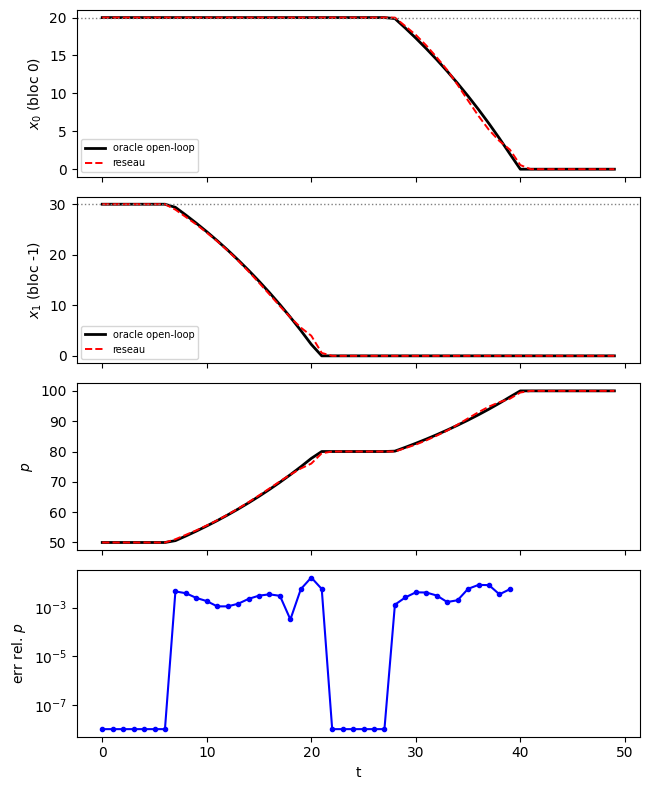


figures -> figs/m3_run13a_fix_rollout.png (+ .npz)
[E] run logue dans runs_m3.csv (7 lignes)

tolerance large ; err_p=1.71e-02 > 1%


/tmp/ipykernel_194864/748310043.py:1289: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)


In [1]:
# M3 : N agents (oligopolistes / cartellistes / frange), T periodes, capacite active, PINN.
# Generalisation directe de M2.
#
# CORRECTION (post RUN 13a corrige) : l'en-tete precedente affirmait que closed-loop et
# open-loop DIVERGENT a N=1 joueur strategique face a une frange, et que le terme nul
# etait un accident de calibration. C'EST FAUX, et la "correction" precedente etait elle
# aussi fausse. Benchekroun & Withagen (2012, Games and Economic Behavior 76(2), 355-374)
# demontrent que les issues des jeux cartel-frange en boucle ouverte et en boucle fermee
# COINCIDENT quand la frange est preneuse de prix (jeu a la Salant 1976). La litterature
# sur l'incoherence temporelle du modele cartel-frange porte sur l'equilibre de von
# STACKELBERG, ou le cartel internalise la fonction de reaction instantanee de la frange
# (terme dx_f/dx_c). Ce fichier n'implemente PAS cette conduite : h_i = p - beta*Lam_i
# - c_i - delta*lambda'_i est du Nash-Cournot. Donc feedback = 0 est le resultat ATTENDU,
# pas un accident. Recalibrer stocks/couts ne peut rien y changer.
# Consequence tactique : la divergence est a chercher a N >= 2 STRATEGIQUES. Benchekroun
# & Withagen etablissent aussi (point ii) que le Nash en boucle fermee a frange nombreuse
# ne converge PAS vers le cartel-frange en boucle fermee : le raccourci "frange price-taker"
# n'est pas innocent en boucle fermee. C'est l'argument scientifique de M3.
#
# Ici N>1 : les deux concepts DIVERGENT, et mesurer cette divergence est un des objectifs de M3

# Trois etages, a lancer DANS CET ORDRE (toggles cross / sob_off) :
#   A. cross=False, sob_off=False -> le reseau resout le systeme OPEN-LOOP a N joueurs.
#      L'oracle generalise est la VERITE, il doit etre retrouve. C'est la validation.
#      Avec blocs="0,-1" et la calibration M2, ce fichier doit redonner M2 a l'identique.
#   B. cross=False, sob_off=True  -> on entraine le gradient COMPLET dV_i/dS_j. Residu
#      mathematiquement redondant : l'equilibre ne bouge pas, l'oracle doit encore etre
#      retrouve. C'est le test du residu lui-meme. Surveiller cross_neg -> 100%.
#   C. cross=True,  sob_off=True  -> MPE. Le reseau s'ecarte de l'oracle open-loop et cet
#      ecart EST le resultat. L'oracle devient comparateur, il n'est plus validateur.
#
# Ce qui change par rapport a M2 :
#   etat S [B,NAG] ; un reseau par agent, chacun prenant l'etat COMPLET (definition du Markov)
#   masque de conduite A : Lambda = A x, h_i = p - beta*Lambda_i - c_i - delta*lambda_i'
#   une seule loss, somme des residus de TOUS les agents, un seul optimiseur
#   tetes valeur ET co-etat pour chaque agent (a M2 celle de la frange etait morte)
#   Sobolev sur tout le gradient dV_i/dS_j, plus seulement la diagonale
#   termes croises de l'enveloppe (le feedback markovien)
#   oracle generalise par Gauss-Seidel sur les N rentes (les bissections imbriquees de M2
#   seraient en O(nbis^N))
#
#   torch.tensor.detach()
#   Residu de Sobolev
#

#
# Aux etages A et B : le solveur change, l'equilibre attendu NON, l'oracle doit etre retrouve.
# A l'etage C seulement, l'ecart est attendu.
#
# COUT : sob_off/cross demandent 3*NAG backward passes avec create_graph, et l'oracle a N
# joueurs est bien plus lent qu'a M2

# ============================================================================
# HISTORIQUE DES RUNS ET ETIQUETAGE
#
# RUN 9  : RESTAURATION DU SOCLE. Aucune idee nouvelle.
#   Cible : err_p ~9e-3 sur la calibration M2 (costs=10,20 kappas=20,30
#   stocks=700,450 blocs=0,-1), cross=False, sob_off=False. ~8 min.
#   Si la cible n'est PAS atteinte, bissecter les six changements accumules
#   depuis la validation 4-graines, un par un, TOUJOURS a sob_off=False :
#     1. SOB_OK          -> CFG["sob_ok_mask"]   (True = masque, validé)
#     2. G dans V        -> CFG["G_in_V"]        (True = etat courant)
#     3. R_bell / G_t    -> CFG["norm_G_bell"]   (True = choix utilisateur)
#     4. R_env / G_t     -> CFG["norm_G_lam"]    (A2, True = valide)
#     5. w_sob           -> CFG["w_sob"]         (0.01 = valide, 0.05 = actuel)
#     6. frac_gauss      -> CFG["frac_gauss"]    (0.0 = origine, 0.25 = actuel)
#
#   RESULTAT RUN 9 : err_p=2.10e-2, hors bande 4-graines [9.6e-3,1.3e-2]. MAIS les deux
#   pires dates sont t=20 et t=39, les dates d'EXTINCTION de la frange et de a0.
#   Hors extinction err_p ~1.1e-2, DANS la bande, et field_int_med=0.913 bbl est le
#   meilleur chiffre jamais enregistre. Le socle est restaure sur le champ ; err_p est
#   un maximum pilote par le biais d'extinction, deja identifie et partage avec M2.
#   -> metriques robustes err_p_q90 / err_p_noext ajoutees en STEP 5.
#
# RUN 10 : masque STRAT (frange price-taker sans feedback). Bloc dans residuals().
#   RESULTAT : identique au bit pres a RUN 9. NORMAL ET NON INFORMATIF : le bloc STRAT est
#   a l'interieur de `if CFG["sob_off"]`, il ne s'execute pas a l'etage A.
#   VALIDE au RUN 13b : s'active sans disloquer le reseau.
#
# RUN 12 : cible Monte-Carlo TD(1) pour V. ACTIF PAR DEFAUT (use_vmc=True).
#   RESULTAT : meilleur run de la serie. err_p_noext=8.40e-3 (SOUS la cible M2 de 9e-3),
#   err_p_q90=6.05e-3, Hotelling a0 cv 1.48e-2 au niveau exact 12.82, Bellman MC 25.72%
#   -> 1.60%, dV0/dS0 tube 1.17%. Seule regression : field_int_med 0.913 -> 1.426.
#   NON-EVENEMENT : lam_deflate a0 "s'effondre" a 9.50 en t=0. a0 est colle a kappa sur
#   28/40 dates : la FOC y est inactive, lambda_0 n'est contraint que par la chaine
#   d'enveloppe. Zone NON IDENTIFIEE, pas une regression. Voir diagnostic RUN 12b.
#
# RUN 13b : PREMIER ETAGE B (sob_off=True, lbfgs_outer=0). ~1400 s.
#   ACQUIS : err_p_noext 8.50e-3 (non-regression), err_p_q90 5.79e-3, STRAT s'active sans
#   dommage, Global(0,1) 91% -> 98%, Tube(0,1) 100%, COH 27.37% -> 20.25%, Hotelling a1
#   cv 1.15e-2 niveau exact. RUN 12b tranche : lam a0 interieur 2.08%, zone kappa 15.75%
#   -> objet NON IDENTIFIE la ou il est faux, dossier lam_deflate CLOS.
#   FALSIFIE : R_sob ne fait PAS baisser l'erreur du gradient diagonal (1.17% -> 1.14%).
#   Attendu : sur cette calibration les cibles de R_sob et R_lam coincident pour a0
#   (coef_00*J_00 = 0 des deux cotes, feedback_0 = 0). L'etage B n'a donc rien teste ici.
#   REGRESSION : field_int_med 0.913 -> 1.426 -> 1.770, monotone sur trois runs, sur la
#   metrique de champ la plus fiable. STEP 5c a 2e-2 contre 8.5e-3 sur sentier : signature
#   de surajustement au tube. A ARRETER avant de monter en dimension.
#   DEFAUT REEL : a1 dV/dS med 28.91%. L'ecart theorique attendu pour la frange vaut
#   beta*x_f*J_ff/lambda_f, soit 2.5% a 5% (J_ff = -(1.05)^t dmu_1/dS_1 ~ 0.05-0.10).
#   Le gradient diagonal de la frange est donc faux de ~25 points. C'est la PREMIERE
#   preuve empirique directe de P-C : R_sob converge vers un point fixe auto-coherent
#   mais faux, la ou il est le seul residu actif (a0 est deja couvert par R_lam).
#
# RUN 13a : GRILLE MPE 2D. LA VERSION PRECEDENTE ETAIT CASSEE.
#   La decision intra-periode resolvait la FOC par point fixe avec lambda obtenu par
#   difference finie sur un interpolant bilineaire. La pente d'un interpolant bilineaire
#   est CONSTANTE PAR CELLULE : la carte de meilleure reponse est une fonction en escalier,
#   son point fixe tombe sur une frontiere de cellule, et l'iteration y cycle. Residu BR
#   mesure = 30 barils (capacite entiere de la frange) au 40e balayage, a TOUS les ng.
#   Consequence : aucune convergence en ng. gap_p = 37.6% / 29.4% / 45.0% / 50.0% pour
#   ng = 80 / 150 / 250 / 400, et gap_p0 saute de 0.00% a 60.00%. Le 29.39% lu a ng=150
#   ne mesurait rien.
#   Test mono-agent (S1=0, ou MPE == controle optimal, donc erreur purement numerique) :
#   l'ancienne methode donnait 100% d'erreur sur x a ng=400.
#   CORRECTIF : la decision est maintenant prise par MAXIMISATION DIRECTE de l'objectif
#   dont la FOC est la derivee, sur une grille d'actions. Aucune derivee de V n'est
#   calculee. Meme equation, resolution differente, convergence monotone en ng.
#
# ---- ETIQUETAGE DES RUNS A VENIR (dans l'ordre d'execution) ----
#
# RUN 13a : GRILLE MPE 2D CORRIGEE, avec test d'acceptation mono-agent. ACTIF.
# RUN 11  : J analytique par theoreme des fonctions implicites. Bloc dans residuals().
#           BUG CORRIGE dans le bloc commente : la reduction masquait les COLONNES
#           contraintes mais pas les LIGNES, donc l'equation d'un agent a un coin
#           contaminait la resolution des lignes libres.
# RUN 13c : cibles PATHWISE par differences finies pour gV. Bloc apres STEP 7.
#           A LANCER EN MODE DIAGNOSTIC D'ABORD (sans reentrainement) : c'est la premiere
#           mesure de MAGNITUDE jamais faite sur gV. Le signe (98% / 100%) ne dit rien
#           de l'amplitude, et le feedback est un PRODUIT.
# RUN 12b : diagnostic desagrege de lambda_0 (interieur vs zone kappa). Fin de STEP 8.
#           ACTIF, cout nul. CLOS : l'objet est non identifie en zone kappa.
# ============================================================================


import os, sys, time, json
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F


torch.set_num_threads(4) 

torch.set_default_dtype(torch.float64)

######## STEP 0  config (pour suivre via des .csv)
CFG = dict(
    tag="m3_run13a_fix", seed=0,
    sampler="mix",           # "mix" = tube+uniforme (defaut) | "tube_oracle" = bras A/B degrade

    # economie : listes paralleles, un element par AGENT
    # non-regression M2 : costs="10,20" kappas="20,30" stocks="700,450" blocs="0,-1"
    # RUN 9 : retour a kappa=[20,30]. Le desserrement [40,60] etait ad hoc, il a detruit
    # l'exactitude architecturale (x = min(min(S,kappa), softplus(z)) atteint kappa a la
    # precision machine : 28/50 dates gratuites) sans ameliorer le feedback, et il
    # contredit la realite Rystad (plateau-declin, capacite liante le plus souvent).
    # NOTE (P-B, REQUALIFIEE) : le feedback nul n'est PAS un accident de calibration, c'est
    # le theoreme de coincidence cartel-frange (cf. en-tete). Ne PAS recalibrer stocks/couts
    # pour le faire apparaitre : passer a N >= 2 strategiques (blocs="0,1,-1").
    costs  = "10,20", # "10,12,14,20",
    kappas = "20,30",     # kappa peut être désserré , #"20,15,12,30",
    stocks = "700,450", #"700,400,300,450",
    blocs  = "0,-1", #"0,1,2,-1",     # entiers distincts = oligopolistes ; egaux = meme cartel ; -1 = frange
    alpha=100.0, beta=1.0, r=0.05, T=50,

    # etages
    sob_off=True,            # entrainer dV_i/dS_j hors-diagonale
    cross=False,             # termes croises dans l'enveloppe (=> MPE). Exige sob_off.

    # toggles de bissection (RUN 9) : chacun isole UN changement accumule depuis la
    # validation 4-graines. Ne jamais en bouger deux dans le meme run.
    sob_ok_mask=True,        # 1. SOB_OK = lignes canoniques de A (False -> ones : RUN 6, casse)
    G_in_V=True,             # 2. facteur G(t) dans la construction de V
    norm_G_bell=True,        # 3. R_bell divise par G_t  (choix utilisateur, conserve)
    norm_G_lam=True,         # 4. R_env/R_sob/R_lam divises par G_t  (A2)
    vref_per_agent=False,    # 4bis. VREF vectoriel alpha*S0_i au lieu du scalaire alpha*max(S0)

    # RUN 12 : cible Monte-Carlo TD(1) pour V, sur le bras TUBE PUR uniquement. VALIDE.
    use_vmc=True, w_vmc=1.0,

    # RUN 13a : grille MPE 2D exacte (N=2 seulement). Aucun entrainement.
    #   mpe_ng_list : la grille est resolue a CHAQUE ng de la liste. Une grandeur qui ne
    #   converge pas en ng ne mesure rien : c'est la porte d'acceptation n.1.
    #   mpe_nx : nombre d'actions candidates de la maximisation directe.
    #   mpe_nbr : balayages de meilleures reponses intra-periode (l'argmax converge vite).
    #   stop_after_grid : coupe avant l'entrainement (~25 min economisees si seul 13a compte).
    run_mpe_grid=False, mpe_ng=160, mpe_ng_list="80,160", mpe_nx=31, mpe_nbr=8,
    stop_after_grid=False,

    # reseau
    width=128, emb_dim=16, depth=3,

    # loss / sampler
    w_sob=0.01, w_sob_off=0.1, frac_unif=0.05, frac_gauss=0.25, frac_decor=0.0, box=1.25, # n_b = B - frac_unif - frac_gauss ; donc B est paramétré automatiquement si frac_unif et frac_gauss le sont 
    buf_paths=64, buf_every=50, buf_lo=0.70, buf_hi=1.25,

    # entrainement
    iters=30000, batch=512, lr=1e-3, lbfgs_outer=0,
    # NOTE : a l'etage B, L-BFGS rend systematiquement loss_pre == loss_post (Wolfe
    # echoue au premier pas) et coute ~300 s pour rien. Mettre lbfgs_outer=0 des que
    # sob_off=True. A l'etage A il travaille reellement, on le garde.

    # instrumentation (R9bis) : decomposition de la loss + normes de gradient par residu.
    # Aucun effet sur l'optimisation. Sans ces chiffres on pilote a l'aveugle.
    diag_every=0,

    # eval (budgets reduits : l'oracle a N joueurs est lent)
    snap_eps=1e-4, n_field=60, or_nbis=30, or_nouter=15,
    t_decouple="10,20,30", make_figs=True,
)

for a in sys.argv[1:]:
    if "=" not in a: continue
    k, v = a.split("=", 1)
    if k not in CFG: continue
    CFG[k] = (v.lower() in ("1", "true")) if isinstance(CFG[k], bool) else type(CFG[k])(v)

alpha, beta, r, T = CFG["alpha"], CFG["beta"], CFG["r"], CFG["T"]
delta = 1.0/(1.0+r)
C_np   = np.array([float(u) for u in CFG["costs"].split(",")])
KAP_np = np.array([float(u) for u in CFG["kappas"].split(",")])
S0_np  = np.array([float(u) for u in CFG["stocks"].split(",")])
BLOC   = np.array([int(u)   for u in CFG["blocs"].split(",")])
NAG = len(C_np)
assert len(KAP_np) == len(S0_np) == len(BLOC) == NAG, "listes d'agents de longueurs differentes"

# masque de conduite : A[i,j] = 1 ssi i et j sont dans le meme bloc (>=0). Frange : ligne nulle.
# cartelliste -> Lambda_i = Q^C (somme du bloc) ; oligopoliste -> Lambda_i = x_i ; frange -> 0.
A_np = np.zeros((NAG, NAG))
for i in range(NAG):
    if BLOC[i] < 0: continue
    for j in range(NAG):
        if BLOC[j] == BLOC[i]: A_np[i, j] = 1.0
IS_FRINGE = BLOC < 0

# SOB_OK désactive de manière stricte le résidu d'env pour tout acteur 
# dont la ligne dans A n'est pas un vecteur de la base canonique
# ATTENTION : SOB_OK ne masque QUE R_lam (l'identite dV_i/dS_i = lambda_i). R_sob,
# l'enveloppe universelle derivee de Bellman, n'a jamais eu de masque et n'en veut pas.
# RUN 6 (SOB_OK = ones) imposait deux equations incompatibles au meme objet : pour la
# frange l'ecart structurel vaut -beta*x_1*(J_01+J_11) - delta*GV2_10*J_01, soit ~-8% de
# lambda_1. Non reductible par l'optimisation. Ne pas y revenir.
SOB_OK = (torch.tensor((A_np == np.eye(NAG)).all(1).astype(float))
          if CFG["sob_ok_mask"] else torch.ones(NAG))

if CFG["cross"] and not CFG["sob_off"]:
    # le feedback repose entierement sur dV_i/dS_k ; sans le Sobolev hors-diagonale ce
    # gradient n'est entraine par rien (a M2 il n'avait meme pas le bon signe partout).
    print("[!] cross=True force sob_off=True (le feedback depend de dV_i/dS_k)")
    CFG["sob_off"] = True

torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
A    = torch.tensor(A_np)
COST = torch.tensor(C_np)
KAP  = torch.tensor(KAP_np)
S0V  = torch.tensor(S0_np)
DEN  = beta*(1.0 + torch.diagonal(A))   # pas de Newton du clamp : dh_i/dx_i = -beta(1+A_ii).
                                        # Recouvre M2 : A_ii=1 -> h/(2beta), A_ii=0 -> h/beta (frange).
OFF  = 1.0 - torch.eye(NAG)             # masque k != i
# RUN 9 : VREF scalaire (etat valide). Le vecteur alpha*S0_i corrige la sous-penalisation
# relative des petits agents (facteur 3.3 pour la frange a la calibration M2) mais c'est
# un CHANGEMENT, pas une restauration : il passe par le toggle.
VREF = (alpha*S0V) if CFG["vref_per_agent"] else (alpha*S0_np.max())   # echelles : chaque residu / l'echelle de CE QU'IL MESURE
LREF = alpha                            # rente bornee par le choke price
XREF = torch.minimum(KAP, S0V)          # echelle des QUANTITES (pas des stocks)
W_SOB, W_SOFF = CFG["w_sob"], CFG["w_sob_off"]
FRAC_UNIF, FRAC_GAUSS, BOX, SNAP_EPS = CFG["frac_unif"], CFG["frac_gauss"], CFG["box"], CFG["snap_eps"]

# STRAT[i] = 1 pour un agent STRATEGIQUE (ligne non nulle dans A), 0 pour la frange.
# Actif a partir de RUN 10, valide au RUN 13b.
STRAT = torch.tensor((~IS_FRINGE).astype(float))

print(f"STEP 0 : {NAG} agents | blocs={list(BLOC)} | frange={list(np.nonzero(IS_FRINGE)[0])}")
print(f"         A =\n{A_np.astype(int)}")

def growth_t(ti):
    """G(t) = (1+r)^(t-(T-1)) : vaut 1 a la derniere date de decision, ~0.09 en t=0."""
    return (1.0+r)**(ti.double() - (T-1))

######### STEP 1  oracle open-loop a N joueurs   [INCHANGE - valide analytiquement]

# rentes initiales mu_i, lambda_i(t) = mu_i*(1+r)^t. A rentes donnees, chaque periode est un
# equilibre STATIQUE a couts effectifs c_i + lambda_i(t) (gere les coins nativement).
# On cherche N scalaires au lieu de N*T inconnues et 3^(N*T) regimes. Les bissections
# imbriquees de M2 seraient en O(nbis^N) : Gauss-Seidel (bissecter mu_i a autres rentes
# fixees, iterer jusqu'au point fixe).
NITER_BR = 60   # point fixe de best-responses (à la De Cannière): précision machine rapidement atteinte.

def static_period_N(ceff, kap):
    """ceff [T_,NAG] -> x [T_,NAG]. h_i = 0 donne
       x_i = [alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j] / (beta*(1+A_ii)), puis clip [0,kappa_i]."""
    x = np.zeros_like(ceff)
    idx = np.arange(NAG)
    for _ in range(NITER_BR):
        for i in range(NAG):
            o = idx[idx != i]
            num = alpha - ceff[:, i] - beta*((1.0 + A_np[i, o])*x[:, o]).sum(1)
            x[:, i] = np.clip(num/(beta*(1.0 + A_np[i, i])), 0.0, kap[i])
    return x

def totals_N(mu, T_, kap):
    g = (1.0+r)**np.arange(T_)
    return static_period_N(C_np[None, :] + mu[None, :]*g[:, None], kap)

def solve_oracle_N(S_, T_, kap=None, nbis=None, nouter=None):
    kap = KAP_np if kap is None else kap
    nbis = CFG["or_nbis"] if nbis is None else nbis
    nouter = CFG["or_nouter"] if nouter is None else nouter
    mu = np.zeros(NAG)
    for _ in range(nouter):
        mu_old = mu.copy()
        for i in range(NAG):
            m0 = mu.copy(); m0[i] = 0.0
            if totals_N(m0, T_, kap)[:, i].sum() <= S_[i]:      # stock non contraignant
                mu[i] = 0.0; continue
            lo, hi = 0.0, alpha
            for _ in range(nbis):
                m = .5*(lo+hi); mt = mu.copy(); mt[i] = m
                if totals_N(mt, T_, kap)[:, i].sum() > S_[i]: lo = m
                else: hi = m
            mu[i] = .5*(lo+hi)
        if np.max(np.abs(mu-mu_old)) < 1e-10: break
    x = totals_N(mu, T_, kap)
    # convergence du Gauss-Seidel sur les rentes : non certifiee, on la journalise.
    return mu, x, alpha - beta*x.sum(1)

t_or = time.time()
mu_a, xa, pa = solve_oracle_N(S0_np, T, nbis=60, nouter=40)
print(f"STEP 1 oracle ok ({time.time()-t_or:.0f}s) : mu={np.round(mu_a,3)}")
for i in range(NAG):
    ai = xa[:, i] > 1e-9
    print(f"  agent {i} (bloc {BLOC[i]:2d}, c={C_np[i]:5.1f}, kap={KAP_np[i]:5.1f}) : "
          f"actif t<={int(np.max(np.nonzero(ai))) if ai.any() else -1}, "
          f"kappa liante {int((xa[:,i]>KAP_np[i]-1e-6).sum())}/{T}, "
          f"cumul {xa[:,i].sum():.1f}/{S0_np[i]:.1f}")
assert np.abs(xa.sum(0) - S0_np).max() < 1e-4, "epuisement viole"
_tlast = int(np.max(np.nonzero(xa.sum(1) > 1e-9)))
assert _tlast < T-1, f"horizon trop court (production encore en t={_tlast})"

# non-regression M2 : avec la calibration M2, l'oracle doit redonner mu=(12.821, 21.757)
if (NAG == 2 and np.allclose(C_np, [10., 20.]) and np.allclose(S0_np, [700., 450.])
        and np.allclose(KAP_np, [20., 30.]) and BLOC[1] < 0):
    assert abs(mu_a[0]-12.821) < 1e-2 and abs(mu_a[1]-21.757) < 1e-2, "oracle N incompatible avec M2"
    print("  [non-regression M2 : mu retrouve]")

SA_T = torch.tensor(S0_np[None, :] - np.concatenate([np.zeros((1, NAG)), np.cumsum(xa, 0)[:-1]], 0))

# ============================================================================
# RUN 13a : GRILLE MPE 2D (induction retrograde, N=2 uniquement). Independante de PyTorch.
#
#   Vous n'avez AUCUNE reference closed-loop : l'oracle est open-loop, donc l'etage C est
#   invalidable par construction. A N=2 c'est reparable ici.
#   A chaque t, iterer les meilleures reponses DANS la periode, puis
#   V_i(S,t) = pi_i + delta*V_i(S-x, t+1). Aucun terme de feedback a coder : il est
#   automatiquement contenu dans le V calcule, puisque sigma_{-i}(S) depend de l'etat.
#
#   DECISION INTRA-PERIODE : maximisation DIRECTE, sans aucune derivee de V.
#     obj_i(x_i) = (alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j)*x_i
#                  - (beta(1+A_ii)/2)*x_i^2 + delta*V_i(S - x)
#     d(obj_i)/dx_i = p - beta*Lambda_i - c_i - delta*dV_i/dS_i  =  h_i du fichier,
#     EXACTEMENT, et pour toute conduite. Frange : A_ii = A_ij = 0 -> derivee = p - c_f
#     - delta*lambda_f, la condition de preneur de prix.
#   POURQUOI : la version precedente resolvait h_i = 0 par point fixe avec lambda obtenu
#   par difference finie sur l'interpolant bilineaire, dont la pente est constante par
#   cellule. La carte de meilleure reponse est alors une fonction en escalier et
#   l'iteration cycle (residu = 30 barils au 40e balayage). Zero convergence en ng.
#   La maximisation directe ne touche jamais a la derivee de l'interpolant.
#
#   PORTES D'ACCEPTATION, dans cet ordre. Aucun chiffre n'est lisible avant :
#     1. TEST MONO-AGENT. A S1 = 0 il n'y a plus de jeu : MPE == controle optimal, et
#        l'oracle open-loop est la verite EXACTE. Toute difference est de l'erreur de
#        grille pure, sans economie dedans. Exiger mono_err_p < 0.5%.
#     2. CONVERGENCE EN ng. gap_p doit etre stable sur mpe_ng_list. Une grandeur qui
#        oscille de +-20 points quand on raffine ne mesure rien.
#     3. RESIDU BR petit devant les quantites (kappa).
#     4. EPUISEMENT CL == S0, sinon la comparaison melange feedback et effet d'horizon.
#   METRIQUES : gap_p est un MAX sur les dates actives, donc pilote par l'extinction,
#   exactement la faiblesse deja corrigee sur err_p. Lire gap_p0 et gap_p_q90.
# ============================================================================
def mpe_grid(ng=None, nbr=None, nx=None):
    ng  = ng  or CFG["mpe_ng"]
    nbr = nbr or CFG["mpe_nbr"]
    nx  = nx  or CFG["mpe_nx"]
    assert NAG == 2, "grille MPE : N=2 uniquement (le cout explose au-dela)"
    g0 = np.linspace(0.0, S0_np[0], ng); g1 = np.linspace(0.0, S0_np[1], ng)
    G0, G1 = np.meshgrid(g0, g1, indexing="ij")
    V = np.zeros((2, ng, ng)); XPOL = np.zeros((T, 2, ng, ng))
    d0, d1 = g0[1], g1[1]
    def interp(Z, a, b):
        ia = np.clip(a/d0, 0, ng-1-1e-9); ib = np.clip(b/d1, 0, ng-1-1e-9)
        i0 = ia.astype(int); j0 = ib.astype(int); fa = ia-i0; fb = ib-j0
        return ((1-fa)*(1-fb)*Z[i0, j0] + fa*(1-fb)*Z[i0+1, j0]
                + (1-fa)*fb*Z[i0, j0+1] + fa*fb*Z[i0+1, j0+1])
    G = [G0, G1]; u = np.linspace(0.0, 1.0, nx); resid = 0.0
    for t in reversed(range(T)):
        x = np.zeros((2, ng, ng))
        for it_br in range(nbr):
            xold = x.copy()
            for i in range(2):
                k = 1-i
                cand  = u[None, None, :]*np.minimum(KAP_np[i], G[i])[:, :, None]   # [ng,ng,nx]
                Sa = [None, None]
                Sa[i] = np.broadcast_to(G[i][:, :, None] - cand, cand.shape)
                Sa[k] = np.broadcast_to((G[k] - x[k])[:, :, None], cand.shape)
                cont  = interp(V[i], np.ascontiguousarray(Sa[0]).ravel(),
                                     np.ascontiguousarray(Sa[1]).ravel()).reshape(cand.shape)
                obj = ((alpha - C_np[i] - beta*(1.0 + A_np[i, k])*x[k])[:, :, None]*cand
                       - 0.5*beta*(1.0 + A_np[i, i])*cand**2 + delta*cont)
                x[i] = np.take_along_axis(cand, obj.argmax(2)[:, :, None], 2)[:, :, 0]
            if it_br == nbr-1: resid = max(resid, float(np.abs(x-xold).max()))
        p = alpha - beta*(x[0] + x[1])
        S0p = G0 - x[0]; S1p = G1 - x[1]
        assert S0p.min() > -1e-9 and S1p.min() > -1e-9, f"stock negatif a t={t}"
        V = np.stack([(p - C_np[i])*x[i] + delta*interp(V[i], S0p, S1p) for i in range(2)])
        XPOL[t] = x
    return g0, g1, V, XPOL, resid

def mpe_rollout(g0, g1, XPOL, S_init=None):
    """Deroule la politique MPE de la grille depuis S_init. -> X [T,2], P [T]."""
    S = np.array(S_init if S_init is not None else S0_np, dtype=float)
    d0, d1 = g0[1], g1[1]; ng = len(g0)
    X, P = [], []
    for t in range(T):
        ia = np.clip(S[0]/d0, 0, ng-1-1e-9); ib = np.clip(S[1]/d1, 0, ng-1-1e-9)
        i0, j0 = int(ia), int(ib); fa, fb = ia-i0, ib-j0
        xt = np.array([((1-fa)*(1-fb)*XPOL[t, i, i0, j0] + fa*(1-fb)*XPOL[t, i, i0+1, j0]
                        + (1-fa)*fb*XPOL[t, i, i0, j0+1] + fa*fb*XPOL[t, i, i0+1, j0+1])
                       for i in range(2)])
        xt = np.minimum(xt, S)
        X.append(xt.copy()); P.append(alpha - beta*xt.sum()); S = S - xt
    return np.array(X), np.array(P)

# masque des dates d'extinction (+/-1), reutilise en STEP 5.
_ext = np.zeros(T, dtype=bool)
for i in range(NAG):
    _mi = np.nonzero(xa[:, i] > 1e-9)[0]
    if _mi.size: _ext[max(0, _mi[-1]-1):_mi[-1]+2] = True

MPE = {}
Xcl = Pcl = None
if CFG["run_mpe_grid"] and NAG == 2:
    _ngs = [int(v) for v in CFG["mpe_ng_list"].split(",")]
    # PORTE 1 : verite mono-agent. A S1 = 0 la frange est absente, le jeu disparait,
    # et l'oracle open-loop est l'optimum exact du monopoleur contraint en capacite.
    _Smono = np.array([S0_np[0], 0.0])
    _, _xmo, _pmo = solve_oracle_N(_Smono, T, nbis=60, nouter=40)
    _amo = _xmo[:, 0] > 1e-9
    _a = xa.sum(1) > 1e-6
    _keepg = _a & (~_ext)
    print("\nRUN 13a  GRILLE MPE (decision par argmax, sans derivee de V)")
    print(f"  verite mono-agent : cumul {_xmo[:,0].sum():.2f}/{S0_np[0]:.0f}, "
          f"actif t<={int(np.max(np.nonzero(_amo)))}")
    print("   ng | residBR | mono_p  mono_x |  gap_p  gap_noext  gap_q90  gap_p0 | epuis CL")
    for _ng in _ngs:
        _tg = time.time()
        _g0, _g1, _Vmpe, _XPOL, _rs = mpe_grid(ng=_ng)
        Xmo, Pmo = mpe_rollout(_g0, _g1, _XPOL, _Smono)
        _emp = float(np.abs(Pmo[_amo]-_pmo[_amo]).max()/_pmo.max())
        _emx = float(np.abs(Xmo[_amo, 0]-_xmo[_amo, 0]).max()/KAP_np[0])
        Xcl, Pcl = mpe_rollout(_g0, _g1, _XPOL)
        _e = np.abs(Pcl[_a]-pa[_a])/pa.max()
        _gn = float(np.abs(Pcl[_keepg]-pa[_keepg]).max()/pa.max()) if _keepg.any() else float("nan")
        MPE = dict(ng=_ng, br_resid=_rs, mono_err_p=_emp, mono_err_x=_emx,
                   gap_p=float(_e.max()), gap_p_noext=_gn,
                   gap_p_q90=float(np.quantile(_e, .90)),
                   gap_p0=float(abs(Pcl[0]-pa[0])/pa[0]), cum=Xcl.sum(0).tolist())
        print(f" {_ng:4d} | {_rs:7.2f} | {_emp:6.2%} {_emx:6.2%} | {_e.max():6.2%} "
              f"{_gn:9.2%} {np.quantile(_e,.90):8.2%} {abs(Pcl[0]-pa[0])/pa[0]:7.2%} | "
              f"{np.round(Xcl.sum(0),1)}  ({time.time()-_tg:.0f}s)")

    print("\n  sentier a ng=%d" % MPE["ng"])
    print("   t  | " + " | ".join(f"a{i} CL/OL" for i in range(NAG)) + " |  p CL/OL")
    for tt in [0, 5, 10, 15, 20, 25, 30, 35, _tlast]:
        s = " ".join(f"{Xcl[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
        print(f"  {tt:3d} | {s} | {Pcl[tt]:6.2f}/{pa[tt]:6.2f}")

    print("\n  PORTES D'ACCEPTATION")
    print(f"   1. mono-agent (erreur purement numerique) : {MPE['mono_err_p']:.2%} "
          f"{'OK' if MPE['mono_err_p'] < 5e-3 else 'ECHEC (cible < 0.5%)'}")
    print(f"   2. convergence en ng : comparer les lignes ci-dessus a la main")
    print(f"   3. residu BR = {MPE['br_resid']:.2f} bbl "
          f"{'OK' if MPE['br_resid'] < 0.5 else 'ECHEC (boucle intra-periode non convergee)'}")
    print(f"   4. epuisement CL {np.round(MPE['cum'],2)} vs {S0_np} "
          f"{'OK' if np.abs(np.array(MPE['cum'])-S0_np).max() < 1.0 else 'ECHEC'}")
    print(f"\n  ECART CL/OL : max {MPE['gap_p']:.2%} | hors extinction {MPE['gap_p_noext']:.2%} "
          f"| q90 {MPE['gap_p_q90']:.2%} | t=0 {MPE['gap_p0']:.2%}")
    print("  ATTENDU : ~0 sur le CARTEL (theoreme de coincidence cartel-frange). Un ecart")
    print("  residuel porte par la FRANGE et du meme ordre que mono_err_p est du bruit de")
    print("  grille. NE PAS recalibrer stocks/couts : passer a blocs='0,1,-1'.")

if CFG["stop_after_grid"]:
    print("\n[stop_after_grid=True : arret avant l'entrainement]")
    sys.exit(0)

#####  STEP 2  reseaux

# un reseau par agent, trois tetes (politique z, valeur w, co-etat l), tronc partage
# (coherence topologique : les trois sont des lectures d'une meme representation).
# Chaque reseau prend l'etat COMPLET S : c'est la definition du Markov, et c'est ce qui rend
# les derivees croisees dV_i/dS_j et dsigma_k/dS_j calculables par autodiff.
# Chaque agent a desormais sa tete valeur : a M2 celle de la frange ne servait a rien, ici
# tous les V_i sont lus par les termes croises.
# NOTE (post RUN 10) : dans le DAG cible, le nombre de reseaux VALEUR = nombre d'agents
# STRATEGIQUES, pas N. La tete valeur de la frange n'est lue par aucune equation.
# - ancrage terminal EXACT par 1{t<T}
# - embedding de t. SiLU conservé : le residu Sobolev a besoin de dV/dS non trivial, et
#   le kink est deja dans l'architecture via les min() (donc rien a apprendre de non lisse).
#   ReLU pas assez lisse. SiLU asymptotiquement (|x|) = ReLU.
class Net(nn.Module):
    def __init__(s, width, emb_dim, depth):
        super().__init__()
        s.emb = nn.Embedding(T+1, emb_dim)          # T+1 : l'index t=T existe, neutralise par alive
        nn.init.normal_(s.emb.weight, std=0.1)
        layers, d = [], NAG + emb_dim
        for _ in range(depth):                      # changer le nombre de hidden layers via depth,
            layers += [nn.Linear(d, width), nn.SiLU()]; d = width    # les neurones via width.
        s.trunk = nn.Sequential(*layers)            # 128 neurones et 3 hidden layers : meilleurs resultats a M2
        s.head_z = nn.Linear(width, 1); s.head_w = nn.Linear(width, 1); s.head_l = nn.Linear(width, 1)
    def forward(s, S, ti):
        h = s.trunk(torch.cat([S/S0V, s.emb(ti)], dim=-1))
        return s.head_z(h).squeeze(-1), s.head_w(h).squeeze(-1), s.head_l(h).squeeze(-1)

NETS = nn.ModuleList([Net(CFG["width"], CFG["emb_dim"], CFG["depth"]) for _ in range(NAG)])
PARAMS = list(NETS.parameters())

def forward_all(S, ti, snap=False):
    """S:[B,NAG] ti:[B] long -> x, V, lam tous [B,NAG]"""
    z, w, l = [], [], []
    for i in range(NAG):
        zi, wi, li = NETS[i](S, ti); z.append(zi); w.append(wi); l.append(li)
    z = torch.stack(z, -1); w = torch.stack(w, -1); l = torch.stack(l, -1)
    # x = min(min(S,kappa), softplus(z)) : atteint kappa EXACTEMENT (coin superieur franc), x>=0.
    x = torch.minimum(torch.minimum(S, KAP), F.softplus(z))
    if snap:                                        # EVAL uniquement (zone morte a l'entrainement)
        x = torch.where(x < SNAP_EPS, torch.zeros_like(x), x)
    alive = (ti < T).double().unsqueeze(-1)
    G = growth_t(ti).unsqueeze(-1) if CFG["G_in_V"] else torch.ones_like(alive)
    # RUN 9 : V libre. Les deux ancrages testes sont morts et ne doivent pas revenir :
    #   * (S/S0V) : annule V_i et TOUS ses gradients sur l'hyperplan S_i=0, donc detruit
    #     l'ancre terminale de la chaine arriere de R_sob/R_soff (RUN 1).
    #   * (* S)   : impose V_i = lambda_i * S_i, i.e. courbure nulle en S, alors que la
    #     courbure est l'objet meme que l'etage B doit apprendre. Mesure : V_0/(lambda_0*S_0)
    #     = 1.72 a la calibration M2. Prior faux d'un facteur 1.7 sur l'agent strategique.
    V   = alive*F.softplus(w) * VREF*G
    lam = alive*F.softplus(l)*LREF*G
    return x, V, lam

#####  STEP 3  residus. C'est incontestablement la STEP la plus IMPORTANTE de tout le code et le réseau.
#####  C'est fiché dans mon cahier: les fonctionnements de clamp() / max() et torch.where() sont subtils mais très très efficaces

# FOC -> politique ; enveloppe -> co-etat ; Bellman -> valeur ; Sobolev -> lie les deux.
# Chaque agent n'a que SA PROPRE FOC : sommer celles des autres dans son programme reviendrait
# a lui faire optimiser leurs decisions. Ce qui fabrique l'equilibre, c'est que p n'est PAS
# detache (le gradient du residu de i remonte dans les reseaux de tous les autres) et que
# chaque reseau lit l'etat complet.
def residuals(S, ti):
    S = S.detach().requires_grad_(True)
    x, V, lam = forward_all(S, ti)
    p = alpha - beta*x.sum(-1, keepdim=True)
    Lam = x @ A.T
    S2 = S - x
    _, V2, lam2 = forward_all(S2, ti+1)
    lam2d = lam2.detach()
    cap = torch.minimum(S, KAP)

    h = p - beta*Lam - COST - delta*lam2d
    R_foc = x - torch.clamp(x + h/DEN, torch.zeros_like(x), cap)

    # Calcul inconditionnel : on abandonne l'optimisation qui cassait le graphe PyTorch
    gV = torch.stack([torch.autograd.grad(V[:, i].sum(), S, create_graph=True)[0]
                      for i in range(NAG)], dim=1)

    # Multiplier par 0.0 préserve le lien au graphe d'autodifférenciation
    feedback = x * 0.0
    R_soff = gV * 0.0
    R_sob = x * 0.0  # Zéro par défaut à l'Étage A
    
    if CFG["sob_off"]:
        J   = torch.stack([torch.autograd.grad(x[:, k].sum(), S, create_graph=True)[0]
                           for k in range(NAG)], dim=1)

        # --------------------------------------------------------------------
        # RUN 11 : J analytique par theoreme des fonctions implicites.
        #   dh_i/dS_j = 0 avec h_i = p - beta*Lam_i - c_i - delta*lambda_i(S-x) donne
        #     [delta*L - beta*B] J = delta*L,   L[i,k] = dlambda'_i/dS'_k,  B = 1 + A
        #   J ne depend alors que des derivees PREMIERES de la tete lambda (supervisee par
        #   R_env, cible dure) au lieu des derivees de la tete z (supervisee seulement
        #   implicitement via R_foc). Verification N=1, A=1 : J = |dL|/(|dL|+2beta) dans (0,1).
        #   Coins : pour k a kappa -> J[k,:] = 0 ; pour x_k = S_k -> J[k,:] = e_k. Ces lignes
        #   sont CONNUES et doivent passer au second membre, pas etre ecrasees apres le solve.
        #   ORDRE : n'activer qu'APRES le diagnostic RUN 13c (magnitude de gV).
        #   BUG CORRIGE : la ligne Mred masquait les COLONNES contraintes (free.unsqueeze(1))
        #   mais pas les LIGNES. Pour un agent k contraint, l'equation k restait couplee aux
        #   colonnes libres et contaminait la resolution, avant d'etre ecrasee par Jfix.
        #   Il faut masquer LIGNES ET COLONNES : free.unsqueeze(-1)*Mj*free.unsqueeze(1).
        #   Sans effet si aucun agent n'est a un coin ; ici a0 est a kappa 28 dates sur 50.
        # L2 = torch.stack([torch.autograd.grad(lam2[:, i].sum(), S2, create_graph=True)[0]
        #                   for i in range(NAG)], dim=1)
        # Mj   = delta*L2 - beta*(1.0 + A)
        # Jfix = torch.zeros_like(Mj)
        # at_k = (x >= KAP - 1e-6)
        # at_S = (x >= S   - 1e-6)
        # Jfix = torch.where(at_S.unsqueeze(-1), torch.eye(NAG).expand_as(Mj), Jfix)
        # free = (~(at_k | at_S)).double()                       # [B,NAG]
        # rhs  = delta*L2 - torch.einsum('bik,bkj->bij', Mj*(1.0-free).unsqueeze(1), Jfix)
        # Mred = free.unsqueeze(-1)*Mj*free.unsqueeze(1) + torch.diag_embed(1.0-free)
        # J    = torch.linalg.solve(Mred, rhs)*free.unsqueeze(-1) + Jfix
        # --------------------------------------------------------------------

        GV2 = torch.stack([torch.autograd.grad(V2[:, i].sum(), S2, create_graph=True)[0]
                           for i in range(NAG)], dim=1)
        # coef[i,k] = d(pi_i)/d(x_k) - delta*dV_i'/dS_k'
        #           = -beta*x_i - delta*GV2[i,k]  (k!=i)   |   + (p - c_i)  (k=i)
        coef = -beta*x.unsqueeze(-1) - delta*GV2 + torch.diag_embed(p - COST)

        # DEUX tenseurs distincts, a ne pas confondre :
        # M_full  : dV_i/dS_j = delta*GV2[i,j] + M_full[i,j]. Somme sur TOUS les k.
        #           C'est la vraie derivee de la valeur -> R_sob et R_soff.
        # M_cross : somme sur k != i seulement. Le terme diagonal coef_ii*J_ii n'est PAS du
        #           feedback, c'est le coin de conduite (0 pour un oligopoliste par la FOC,
        #           -beta*x_f*dsigma_f/dS_f pour la frange, beta*(Q^C - x_i) pour un cartelliste).
        M_full  = torch.einsum('bik,bkj->bij', coef,     J)
        M_cross = torch.einsum('bik,bkj->bij', coef*OFF, J)

        feedback = torch.diagonal(M_cross, dim1=1, dim2=2)      # etage C + STEP 8
        R_soff   = (gV - (delta*GV2 + M_full).detach())*OFF
        # P-C : cette cible est AUTO-REFERENTIELLE (construite depuis le V du reseau
        # lui-meme, ancre terminale degeneree a 0). CONFIRME EMPIRIQUEMENT au RUN 13b :
        # a1 dV/dS a 28.91% contre un ecart theorique attendu de 2.5-5%. R_sob converge
        # vers un point fixe auto-coherent mais faux la ou il est le seul residu actif.
        # Attaque : RUN 13c (cibles pathwise mesurees).
        # Enveloppe universelle (derivee de Bellman), valide quelle que soit la conduite :
        R_sob = torch.diagonal(gV, 1, 2) - (delta*torch.diagonal(GV2, 1, 2)
                                            + torch.diagonal(M_full, 1, 2)).detach()

        # --------------------------------------------------------------------
        # RUN 10 : masque STRAT. Une frange PRENEUSE DE PRIX n'a pas de terme de feedback
        #   (cf. specification M2 : "Rf_env = lf - tgt_f  # frange price-taker : pas de
        #   terme croise"). Or feedback est actuellement ajoute a TOUS les agents.
        #   Une fois feedback_f = 0, GV2[f,:] n'entre plus dans AUCUNE equation : ni dans
        #   feedback_0 (qui n'utilise que GV2[0,1] et J[1,0]), ni ailleurs. Les 0% de
        #   Tube(i=1,j=0) portent donc sur un objet inutilise -> on le supprime, on ne le
        #   repare pas. Ce qu'agent 0 a besoin de la frange, c'est J[1,0], pas V_1.
        #   Generalisation DAG : nb de reseaux valeur = nb d'agents strategiques, pas N.
        #   STATUT : VALIDE au RUN 13b, s'active sans disloquer le reseau.
        R_soff   = R_soff * STRAT.view(1, -1, 1)
        feedback = feedback * STRAT
        # --------------------------------------------------------------------

    bind = (x >= KAP - 1e-4).detach()
    tgt = torch.where(bind, delta*lam2d,
                      torch.maximum(p.detach()-beta*Lam.detach()-COST, delta*lam2d))
    if CFG["cross"]: tgt = tgt + feedback.detach()
    R_env = lam - tgt

    R_bell = V - ((p.detach()-COST)*x.detach() + delta*V2.detach())

    # La condition d'identité est masquée proprement
    R_lam = (torch.diagonal(gV, 1, 2) - lam) * SOB_OK
    
    # RUN 12 : V est renvoye en 7e position (R[6]) pour que loss_from_res puisse former
    # le residu Monte-Carlo. Les indices 0..5 sont INCHANGES : grad_norms ne bouge pas.
    return R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V

def loss_from_res(R, ti, Vtgt=None, msk=None, parts=False):
    # UNE loss, somme sur tous les agents, un seul optimiseur conjoint.
    R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V = R
    # L = ((R_foc/XREF)**2 + (R_env/LREF)**2 + (R_bell/VREF)**2 + W_SOB*(R_sob/LREF)**2 + W_SOB*(R_lam/LREF)**2).sum(-1)
    # if CFG["sob_off"]: L = L + W_SOFF*((R_soff/LREF)**2).sum((-1, -2))
    G_t = growth_t(ti).unsqueeze(-1)
    # Normalisation pour toutes les variables temporelles
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    c_foc  =        ((R_foc /XREF      )**2).sum(-1)
    c_env  =        ((R_env /(LREF*GL) )**2).sum(-1)
    c_bell =        ((R_bell/(VREF*GB) )**2).sum(-1)
    c_sob  = W_SOB *((R_sob /(LREF*GL) )**2).sum(-1)
    c_lam  = W_SOB *((R_lam /(LREF*GL) )**2).sum(-1)
    L = c_foc + c_env + c_bell + c_sob + c_lam
    c_soff = torch.zeros_like(L)
    if CFG["sob_off"]:
        c_soff = W_SOFF*((R_soff/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))
        L = L + c_soff

    # ------------------------------------------------------------------------
    # RUN 12 : cible Monte-Carlo pour V sur le tube (TD(1) au lieu de TD(0)). VALIDE.
    #   R_bell est un residu a UN pas : il peut etre minuscule pendant que V derive de 25%.
    #   V est un bootstrap a 20-40 pas avec une unique ancre en T et aucune contrainte
    #   integrale. Le buffer effectue deja 64 rollouts complets toutes les 50 iterations :
    #   la cible est GRATUITE, exacte, sans oracle, et valide a l'etage C (V^MC est par
    #   definition la valeur de la politique COURANTE, quelle qu'elle soit).
    #   msk = 1 UNIQUEMENT sur le bras tube pur : sur les bras uniforme / jitter /
    #   decorrelant l'etat est perturbe, le Vmc stocke ne lui correspond plus.
    #   ATTENTION AU CRITERE : STEP 6 compare V_net(S0,0) au profit du rollout depuis S0,
    #   soit exactement l'objet regresse ici. Bellman MC devient QUASI-TAUTOLOGIQUE.
    #   Les criteres independants restent err_p_noext, field_int_med et STEP 5e.
    #   SURVEILLANCE : la cible n'est appliquee que sur le tube. field_int_med se degrade
    #   depuis son introduction (0.913 -> 1.426 -> 1.770). Surajustement au tube probable.
    c_vmc = torch.zeros_like(L)
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        c_vmc = CFG["w_vmc"]*(((V - Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk
        L = L + c_vmc
    # ------------------------------------------------------------------------

    if parts:
        d = dict(foc=c_foc, env=c_env, bell=c_bell, sob=c_sob, lam=c_lam,
                 soff=c_soff, vmc=c_vmc)
        return L.mean(), {k: v.mean().item() for k, v in d.items()}
    return L.mean()

# R9bis : normes de gradient par residu. Sans ces 5 nombres on pilote a l'aveugle, et c'est
# ce qui a permis aux runs 4 a 8 de couter 6 heures pour un diagnostic. E8 est le seul
# correctif de la serie E qui n'ait rien casse. retain_graph=True obligatoire.
def grad_norms(Sb, tb, Vtgt=None, msk=None):
    R = residuals(Sb, tb)
    G_t = growth_t(tb).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    comps = dict(
        foc  =        ((R[0]/XREF     )**2).sum(-1).mean(),
        env  =        ((R[1]/(LREF*GL))**2).sum(-1).mean(),
        bell =        ((R[2]/(VREF*GB))**2).sum(-1).mean(),
        sob  = W_SOB *((R[3]/(LREF*GL))**2).sum(-1).mean(),
        lam  = W_SOB *((R[5]/(LREF*GL))**2).sum(-1).mean(),
    )
    if CFG["sob_off"]:
        comps["soff"] = (W_SOFF*((R[4]/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))).mean()
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        comps["vmc"] = (CFG["w_vmc"]*(((R[6]-Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk).mean()
    out = {}
    for k, v in comps.items():
        if float(v) == 0.0: out[k] = 0.0; continue
        g = torch.autograd.grad(v, PARAMS, retain_graph=True, allow_unused=True)
        out[k] = float(torch.sqrt(sum((gi**2).sum() for gi in g if gi is not None)))
    return out

##### STEP 4  sampler + entrainement : stochastique GD (méthode avancée Adam),  puis L-BFGS (finisseur batch complet)

# tube (buffer de la politique COURANTE : voisinage transverse, force de rappel du rollout)
# + petit ancrage uniforme (structure globale). Le tube-oracle a bruit nul ne donnait aucun
# champ transverse => loss 1e-6 et trajectoire fausse a 16%.
#### ---> une loss très faible (1e-6) peut cacher une architecture défaillante! on a eu de meilleurs résultats avec une loss finale 1e-4 qu'avec 1e-6. La loss n'est pas un signal à valider.
# A N grand l'ancrage uniforme couvre de moins en moins (volume exponentiel) : c'est le TUBE
# qui rend le DEQN faisable la ou une grille ne l'est pas.
_BUF = None
_VBUF = None
def refresh_buffer(n=None):
    global _BUF, _VBUF
    n = n or CFG["buf_paths"]
    with torch.no_grad():
        S = (CFG["buf_lo"] + (CFG["buf_hi"]-CFG["buf_lo"])*torch.rand(n, NAG))*S0V
        SS, TT, XX, PP = [], [], [], []
        for t in range(T):
            ti = torch.full((n,), t, dtype=torch.long)
            SS.append(S.clone()); TT.append(ti)
            x, _, _ = forward_all(S, ti)
            XX.append(x.clone()); PP.append(alpha - beta*x.sum(-1, keepdim=True))
            S = S - x
        _BUF = (torch.cat(SS, 0), torch.cat(TT, 0), n)
        # RUN 12 : accumulation ARRIERE du profit actualise le long du rollout DEJA calcule.
        # V^MC_i(S_t,t) = somme_{s>=t} delta^(s-t) (p_s - c_i) x_is , tronquee en T -> V(.,T)=0.
        Vmc, VV = torch.zeros(n, NAG), [None]*T
        for t in reversed(range(T)):
            Vmc = (PP[t] - COST)*XX[t] + delta*Vmc
            VV[t] = Vmc.clone()
        _VBUF = torch.cat(VV, 0)

def sample_states(B):
    # RUN 12 : retourne 4 valeurs (S, t, Vtgt, msk) et non plus 2.
    if CFG["sampler"] == "tube_oracle":
        idx = torch.randint(0, T, (B,))
        return SA_T[idx], idx, torch.zeros(B, NAG), torch.zeros(B)
        
    n_u = int(CFG["frac_unif"] * B)
    n_j = int(CFG["frac_gauss"] * B)
    n_d = int(CFG.get("frac_decor", 0.25) * B)
    n_b = B - n_u - n_j - n_d

    # 1. Global Uniforme
    S_u = torch.rand(n_u, NAG) * S0V * BOX
    t_u = torch.randint(0, T, (n_u,))

    # 2. Jitter Local
    idx_j = torch.randint(0, _BUF[0].shape[0], (n_j,))
    S_j = torch.clamp(_BUF[0][idx_j] + torch.randn(n_j, NAG) * 0.05 * S0V, min=0.0)
    t_j = _BUF[1][idx_j]

    # 3. Tube Pur
    idx_b = torch.randint(0, _BUF[0].shape[0], (n_b,))
    S_b = _BUF[0][idx_b]
    t_b = _BUF[1][idx_b]
    
    # 4. Sampler Décorrélant (Brisure de collinéarité spatio-temporelle)
    # RUN 8 : le confondant S_0 <-> t est ETABLI (mesure 19.9105 vs prediction 19.2204),
    # mais ce bras ne le casse pas : la cible de gV[1,0] est (delta*GV2 + M_full).detach(),
    # calculee a partir de la valeur fausse du reseau lui-meme. Point fixe auto-referentiel,
    # ancre terminale degeneree a 0 sur 19 periodes. Aucun echantillonnage ne casse cela.
    # -> frac_decor=0.0 par defaut a RUN 9 ; le bras reste inerte mais present.
    idx_d = torch.randint(0, _BUF[0].shape[0], (n_d,))
    S_d = _BUF[0][idx_d].clone()
    agent_idx = torch.randint(0, NAG, (n_d,))
    S_d[torch.arange(n_d), agent_idx] = torch.rand(n_d) * S0V[agent_idx] * BOX
    t_d = _BUF[1][idx_d]

    # RUN 12 : la cible MC n'est VALIDE QUE sur le bras 3 (tube pur, etat non perturbe).
    Vt = torch.cat([torch.zeros(n_u, NAG), torch.zeros(n_j, NAG),
                    (_VBUF[idx_b] if _VBUF is not None else torch.zeros(n_b, NAG)),
                    torch.zeros(n_d, NAG)], 0)
    mk = torch.cat([torch.zeros(n_u), torch.zeros(n_j),
                    torch.ones(n_b),  torch.zeros(n_d)], 0)

    return (torch.cat([S_u, S_j, S_b, S_d], 0), torch.cat([t_u, t_j, t_b, t_d], 0), Vt, mk)

print(f"\nSTEP 4 : Adam (NAG={NAG}, cross={CFG['cross']}, sob_off={CFG['sob_off']}, "
      f"vmc={CFG['use_vmc']})...")
opt = torch.optim.Adam(PARAMS, lr=CFG["lr"])
t0 = time.time(); refresh_buffer(); loss_hist = []
for it in range(CFG["iters"]):
    if it == CFG["iters"]*4//10:
        for g in opt.param_groups: g["lr"] = 3e-4
    if it == CFG["iters"]*6//10:
        for g in opt.param_groups: g["lr"] = 1e-4
    if CFG["sampler"] == "mix" and it % CFG["buf_every"] == 0: refresh_buffer()
    opt.zero_grad()
    Sb, tb, Vb, mb = sample_states(CFG["batch"])
    L = loss_from_res(residuals(Sb, tb), tb, Vb, mb)
    L.backward(); opt.step()
    if it % 100 == 0: loss_hist.append((it, L.item()))
    if it % 3000 == 0: print(f"  it={it:5d} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)
    # R9bis : decomposition + normes de gradient. Aucun effet sur l'optimisation.
    if CFG["diag_every"] and it % CFG["diag_every"] == 0:
        Sd, td, Vd, md = sample_states(CFG["batch"])
        _, pc = loss_from_res(residuals(Sd, td), td, Vd, md, parts=True)
        gn = grad_norms(Sd, td, Vd, md)
        print("        parts " + " ".join(f"{k}={v:.2e}" for k, v in pc.items()), flush=True)
        print("        |grad| " + " ".join(f"{k}={v:.2e}" for k, v in gn.items()), flush=True)

    # ------------------------------------------------------------------------
    # RUN 13c : rafraichissement de la cible pathwise GV_TGT (voir bloc apres STEP 7).
    # if CFG["sob_off"] and it % 200 == 0:
    #     _idx = torch.randint(0, _BUF[0].shape[0], (256,))
    #     GV_TGT_S, GV_TGT_T = _BUF[0][_idx], _BUF[1][_idx]
    #     GV_TGT = gv_target_fd(GV_TGT_S, GV_TGT_T)
    # ------------------------------------------------------------------------

print("STEP 4 : L-BFGS (collocation fixe)...")
# Méthode quasi-Newton optimisée, qui stocke l'historique ici des 60 dernières paires (pas,changement de gradient)
# pour mieux suivre la courbe de la loss
# L-BFGS vient préciser la direction par rapport à Adam au fond des puits, elle ne le remplace pas
Lpost = loss_hist[-1][1] if loss_hist else float("nan")
for outer in range(CFG["lbfgs_outer"]):
    if CFG["sampler"] == "mix": refresh_buffer(256)
    Sb, tb, Vb, mb = sample_states(6000)
    Sb = torch.cat([Sb, S0V.expand(100, NAG)], 0)   # ancre S0 dans le jeu fixe
    tb = torch.cat([tb, torch.zeros(100, dtype=torch.long)], 0)
    Vb = torch.cat([Vb, torch.zeros(100, NAG)], 0)  # RUN 12 : l'ancre S0 n'a pas de cible MC
    mb = torch.cat([mb, torch.zeros(100)], 0)
    opt2 = torch.optim.LBFGS(PARAMS, lr=1.0, max_iter=400, history_size=60,
                             tolerance_grad=1e-15, tolerance_change=1e-16,
                             line_search_fn="strong_wolfe")
    def closure():
        opt2.zero_grad(); Lf = loss_from_res(residuals(Sb, tb), tb, Vb, mb); Lf.backward(); return Lf
    L = opt2.step(closure); Lpost = closure().item(); loss_hist.append((CFG["iters"]+outer, Lpost))
    #print(f"  outer={outer} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)
    print(f"  outer={outer} loss_pre={L.item():.3e} loss_post={Lpost:.3e} ({time.time()-t0:.0f}s)", flush=True)
LOSS_FINAL = Lpost

###### STEP 5  rollout vs oracle (rollout=déroulement de t=0 jusqu'à t=50 en appellant la fonction sigma du réseau itérativement)

def rollout(S_init, snap=True):
    S = S_init.clone().reshape(1, NAG); X, P = [], []
    with torch.no_grad():
        for t in range(T):
            x, _, _ = forward_all(S, torch.tensor([t]), snap=snap)
            X.append(x[0].clone().numpy()); P.append((alpha - beta*x.sum()).item())
            S = S - x
    return np.array(X), np.array(P), S[0].numpy()

X, P, Send = rollout(S0V)
act = xa.sum(1) > 1e-6
err_p = np.abs(P[act]-pa[act]).max()/pa.max()
err_x = np.abs(X[act]-xa[act]).max()/KAP_np.max()
print(f"\nSTEP 5 rollout vs oracle open-loop "
      f"({'COMPARATEUR (MPE)' if CFG['cross'] else 'VALIDATEUR'})")
print("  t  | " + " | ".join(f"a{i} res/or" for i in range(NAG)) + " |  p res/or")
for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
    s = " ".join(f"{X[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
    print(f" {tt:3d} | {s} | {P[tt]:6.2f}/{pa[tt]:6.2f}")
print(f"  epuisement {np.round(X.sum(0),1)} / {S0_np}")
print(f"  err_max(actives) x={err_x:.2e}  p={err_p:.2e}")

ep = np.abs(P[act]-pa[act])/pa.max(); ia = np.nonzero(act)[0]
top = np.argsort(ep)[::-1][:4]
print("  4 pires dates :", ", ".join(f"t={ia[i]}({ep[i]*100:.1f}%)" for i in top))

# METRIQUES ROBUSTES (RUN 9) : err_p est un MAX, donc pilote par la seule date d'extinction
# (t=20 pour la frange, t=39 pour a0), ou le biais structurel de date d'extinction, partage
# avec M2, domine. err_p_noext exclut les dates d'extinction +/-1 ; err_p_q90 est insensible
# a un point isole. C'est sur CES deux chiffres qu'il faut juger le solveur.
# ATTENTION A L'ESTIMAND : la "cible M2 de 9e-3" est un err_p COMPLET. La comparer a
# err_p_noext flatte mecaniquement le run. Reconstituer err_p complet avant de conclure.
_keep = act & (~_ext)
ERRP_NOEXT = float(np.abs(P[_keep]-pa[_keep]).max()/pa.max()) if _keep.any() else float("nan")
ERRP_Q90 = float(np.quantile(ep, 0.90))
print(f"  err_p hors dates d'extinction = {ERRP_NOEXT:.2e}   |   err_p q90 = {ERRP_Q90:.2e}")

# Hotelling : marge STRATEGIQUE h_i = p - beta*Lambda_i - c_i
# A l'interieur h = lambda_i(t) = mu_i(1+r)^t : la courbe deflatee doit etre PLATE, ET a la
# hauteur mu_i. Avec cross=True elle ne l'est plus, et l'ecart a la platitude EST le feedback.
# C'EST LE CONTROLE QUI FAIT FOI POUR lambda : il ne porte que sur les dates INTERIEURES,
# les seules ou lambda est identifie (en zone kappa la FOC est inactive).
Lam_r = X @ A_np.T
hall = (P[:, None] - beta*Lam_r - C_np[None, :])/((1.0+r)**np.arange(T))[:, None]
HOT = {}
for i in range(NAG):
    mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
    if mi.sum() > 1:
        HOT[i] = (hall[mi, i].std()/abs(hall[mi, i].mean()), hall[mi, i].mean())
        print(f"  Hotelling a{i} : cv={HOT[i][0]:.2e} sur {int(mi.sum())} dates | "
              f"niveau {HOT[i][1]:.2f} vs mu={mu_a[i]:.2f}")

###### STEP 5a  rente par date

# cout oracle NUL : le long du sentier, lambda_i(t) = mu_i(1+r)^t a toutes les dates actives
# (a l'interieur par la FOC, aux coins par l'enveloppe lambda = delta*lambda').
# Reference valide aux etages A et B seulement : a l'etage C le feedback deplace la rente.
lam_true = mu_a[None, :]*((1.0+r)**np.arange(T))[:, None]
with torch.no_grad():
    _, _, lam_net = forward_all(SA_T, torch.arange(T))
rel_lam = np.abs(lam_net.numpy()-lam_true)/np.maximum(lam_true, 1e-9)
#LAM_MED = float(np.median(rel_lam[act])); LAM_MAX = float(rel_lam[act].max())
act_nag = xa > 1e-6  # Masque 2D [T, NAG] : isole strictement les dates actives de CHAQUE agent
LAM_MED = float(np.median(rel_lam[act_nag]))
LAM_MAX = float(rel_lam[act_nag].max())
print(f"\nSTEP 5a rente le long du sentier : err rel mediane {LAM_MED:.2%}, max {LAM_MAX:.2%}")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: med {np.median(rel_lam[m, i]):.2%} max {rel_lam[m, i].max():.2%}")
###### STEP 5e  la rente par ses DEUX representations, sur le TUBE, contre l'oracle
# 5a mesure la tete lambda. Ici dV_i/dS_i, meme verite, meme echantillon. C'est CE
# chiffre, et lui seul, qui dit si la tete lambda est supprimable (P1).
# RUN 12 : a0 dV/dS 1.17% CONTRE tete lam 12.94%. Les deux representations DIVERGENT et
# c'est la premiere qui est bonne. P1 (supprimer la tete lambda) est ROUVERT.
# ATTENTION AUX AGENTS NON SINGLETONS (SOB_OK=0) : pour la frange, dV_f/dS_f n'est PAS
# lambda_f. L'ecart structurel vaut beta*x_f*J_ff/lambda_f, soit 2.5% a 5% ici. Un ecart
# de 29% n'est donc PAS explique par la conduite : c'est une erreur reelle du gradient.
Sg = SA_T.clone().requires_grad_(True); tg = torch.arange(T)
_, Vg, _ = forward_all(Sg, tg)
gd = torch.diagonal(torch.stack([torch.autograd.grad(Vg[:, i].sum(), Sg, retain_graph=True)[0]
                                 for i in range(NAG)], dim=1), dim1=1, dim2=2).detach().numpy()
rel_g = np.abs(gd - lam_true)/np.maximum(lam_true, 1e-9)
print("\nSTEP 5e rente : dV/dS (tube) vs tete lambda, contre oracle")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: dV/dS med {np.median(rel_g[m,i]):.2%} max {rel_g[m,i].max():.2%}"
              f"  |  tete lam med {np.median(rel_lam[m,i]):.2%}  (SOB_OK={int(SOB_OK[i])})")
# profil temporel de la rente DEFLATEE : doit etre plate a la hauteur mu.
# Derive monotone en s'eloignant de la date d'extinction => chaine de bootstrap.
# Bruit sans structure => probleme de representation, pas de propagation.
# ATTENTION : NON INTERPRETABLE en zone kappa (FOC inactive, lambda non identifie).
# Voir le diagnostic desagrege RUN 12b en fin de STEP 8.
lt = lam_net.numpy()/((1.0+r)**np.arange(T))[:, None]
for i in range(NAG):
    m = np.nonzero(xa[:, i] > 1e-6)[0]
    if len(m) > 6:
        q = [m[0], m[len(m)//4], m[len(m)//2], m[3*len(m)//4], m[-1]]
        print(f"  a{i} lam_deflate " + " ".join(f"t{t}:{lt[t,i]:.2f}" for t in q)
              + f"   (mu={mu_a[i]:.2f})")

###### STEP 5b  champ, STRATIFIE

# attention médiane globale peut cacher des erreurs (erreur strictement nulle à précision machine aux coins supérieurs)
# NOTE : field_int_med est la SEULE metrique qui suive err_p monotonement sur les runs 5-8
# (1.775 -> 2.782 -> 4.439 -> 7.976 bbl). C'est elle qu'il faut optimiser, pas COH ni CROSS_NEG.
# RUN 9 : 0.913 bbl. RUN 12 : 1.426. RUN 13b : 1.770. DEGRADATION MONOTONE sur trois runs,
# pendant que les metriques de sentier s'ameliorent : signature de surajustement au tube.
# A arreter avant de monter en dimension, ou l'argument du PINN repose entierement sur le champ.
print(f"\nSTEP 5b champ (oracle tronque, n={CFG['n_field']})")
rng = np.random.default_rng(0)
Sf_ = rng.uniform(0.05, 1.10, (CFG["n_field"], NAG))*S0_np
tf_ = rng.integers(0, T-1, CFG["n_field"])
buck = {"kappa": [], "interieur": [], "zero": []}
t_f0 = time.time()
with torch.no_grad():
    for sv, tv in zip(Sf_, tf_):
        _, xo, _ = solve_oracle_N(sv, T-int(tv))
        xn, _, _ = forward_all(torch.tensor(sv).reshape(1, NAG), torch.tensor([int(tv)]), snap=True)
        for i in range(NAG):
            reg = ("kappa" if xo[0, i] >= KAP_np[i]-1e-6
                   else ("zero" if xo[0, i] <= 1e-9 else "interieur"))
            buck[reg].append(abs(xn[0, i].item()-xo[0, i]))
FIELD = {}
for reg, d in buck.items():
    if not d: continue
    d = np.array(d); FIELD[reg] = (float(np.median(d)), float(np.quantile(d, .9)))
    print(f"  {reg:9s} n={len(d):4d} | err med {FIELD[reg][0]:.3f} q90 {FIELD[reg][1]:.3f} bbl")
print(f"  ({time.time()-t_f0:.0f}s)")
FI = FIELD.get("interieur", (np.nan, np.nan))

###### STEP 5c  recuperation hors-sentier

# le test qui distingue une POLITIQUE sigma(S) d'une sequence memorisee : partir d'ailleurs et
# retomber sur l'oracle recalcule depuis ce point. 0.8 (franchement interieur) ET 1.2 (bord de boite).
# RUN 13b : 1.97e-2 et 1.79e-2 contre 8.5e-3 sur sentier. Facteur 2.3 : meme signal que 5b.
print("\nSTEP 5c recuperation hors-sentier")
REC = {}
for fac in (0.8, 1.2):
    Xp, Pp, _ = rollout(S0V*fac)
    _, xo, po = solve_oracle_N(S0_np*fac, T, nbis=60, nouter=40)
    a_ = xo.sum(1) > 1e-6
    REC[fac] = float(np.abs(Pp[a_]-po[a_]).max()/po.max())
    print(f"  S0x{fac} : err_p={REC[fac]:.2e}")

####### STEP 5d

# action du reseau A L'ETAT ORACLE de la date t, puis continuation ORACLE.
# Petit => la decision locale est bonne et l'erreur du rollout vient de la derive d'etat.
# Grand => la politique elle-meme est fausse a cette date.
# Choisir des dates ou un agent est INTERIEUR : la ou tout le monde est colle a kappa, la
# decision est exacte par architecture et le test est degenere (t=20 rend 5.68e-16).
print("\nSTEP 5d decouplage 1-pas (etat oracle)")
DEC = {}
for ts in [int(u) for u in CFG["t_decouple"].split(",")]:
    if ts >= _tlast: continue
    Ss = SA_T[ts].reshape(1, NAG)
    with torch.no_grad():
        xs, _, _ = forward_all(Ss, torch.tensor([ts]), snap=True)
    xs = xs[0].numpy()
    _, _, ptail = solve_oracle_N(Ss[0].numpy()-xs, T-ts-1, nbis=60, nouter=40)
    ph = np.concatenate(([alpha - beta*xs.sum()], ptail))
    ao = xa[ts:].sum(1) > 1e-6
    DEC[ts] = float(np.abs(ph[ao]-pa[ts:][ao]).max()/pa.max())
    print(f"  t={ts:2d} : err_p={DEC[ts]:.2e}")

####### STEP 6  Bellman Monte-Carlo

# coherence de la VALEUR, sans aucun oracle : V_i(S0,0) predit contre le profit actualise
# REELLEMENT realise en deroulant la politique apprise. Survit tel quel a l'etage C.
# RUN 12 : ce test devient QUASI-TAUTOLOGIQUE, puisque c'est exactement l'objet regresse
# par la cible MC sur le tube (et S0 est dans la boite du buffer). Le passer sous 5% ne
# prouve pas grand-chose EN SOI ; ce qui compte est l'effet induit sur err_p_noext,
# field_int_med et STEP 5e.
with torch.no_grad():
    _, V0, _ = forward_all(S0V.reshape(1, NAG), torch.tensor([0]))
d_t = delta**np.arange(T)
V_mc = np.array([float(np.sum(d_t*(P - C_np[i])*X[:, i])) for i in range(NAG)])
V_net = V0[0].numpy()
V_or = np.array([float(np.sum(d_t*(pa - C_np[i])*xa[:, i])) for i in range(NAG)])
print("  paiement realise vs oracle : " + " ".join(f"a{i} {(V_mc[i]/V_or[i]-1):+.3%}"
                                                   for i in range(NAG)))
BELL = float(np.max(np.abs(V_net-V_mc)/np.maximum(np.abs(V_mc), 1e-9)))
print(f"\nSTEP 6 Bellman MC : ecart max {BELL:.2%}")
for i in range(NAG):
    print(f"  a{i} : V_net={V_net[i]:9.1f} vs realise={V_mc[i]:9.1f}")

####### STEP 7  enveloppe + gradients croisés

# dV_i/dS_i vs tete lambda_i : entraine par le Sobolev diagonal, doit etre PETIT. Si > ~1%,
# ne pas supprimer les tetes lambda : elles sont une seconde representation de la rente, donc
# un second solveur independant, seul controle disponible quand l'oracle disparait.
# dV_i/dS_j (j != i) : signe attendu NEGATIF partout, le stock du rival nuit via le prix.
# C'est l'ingredient du feedback : tant que ce n'est pas ~100%, l'etage C est premature.
# COH est calcule sur [:, SOB_OK > 0] : l'ESTIMAND CHANGE avec SOB_OK. Ne jamais comparer
# un COH a masque [1,0] avec un COH a masque [1,1].
#
# AVERTISSEMENT (post RUN 12) : COH N'EST PLUS UNE METRIQUE DE QUALITE GEOMETRIQUE.
# COH est identiquement |R_lam|/lambda. A 20-27% avec dV/dS a 1.1% (STEP 5e), il mesure
# l'erreur de la TETE LAMBDA, pas celle du gradient.
#
# AVERTISSEMENT CAPITAL : le SIGNE ne dit RIEN de la MAGNITUDE, et le feedback est un
# PRODUIT coef[i,k]*J[k,j]. 98% / 100% de signes corrects sont compatibles avec un
# facteur 3 d'erreur en amplitude. La magnitude de gV n'a JAMAIS ete mesuree : c'est
# l'objet du diagnostic RUN 13c ci-dessous, a lancer AVANT tout etage C.
#
# AVERTISSEMENT (post RUN 10) : Tube(i=1,j=0)=0% porte sur un objet INERTE. Depuis le
# masque STRAT, gV[1,0] et feedback_1 n'entrent dans aucune equation (frange price-taker).
# Ne pas rouvrir ce point.

Sp = (torch.rand(2000, NAG)*S0V*1.1).requires_grad_(True)
tp = torch.randint(0, T-1, (2000,))
_, Vp, lamp = forward_all(Sp, tp)
gVp = torch.stack([torch.autograd.grad(Vp[:, i].sum(), Sp, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)

COH = (((torch.diagonal(gVp, dim1=1, dim2=2) - lamp).abs() / (lamp.abs() + 1e-6))[:, SOB_OK > 0]).median().item()

# 1. Filtre d'amplitude : on ignore les régions où la dérivée croisée est physiquement ~0
off_mask = OFF.unsqueeze(0).expand_as(gVp) > 0
scale = lamp.detach().abs().unsqueeze(-1).expand_as(gVp)[off_mask] + 1e-9
offv = gVp[off_mask]
sig  = offv.abs() > 0.05 * scale
CROSS_NEG = (offv[sig] < 0).double().mean().item() if sig.any() else 0.0

print(f"\nSTEP 7 |dV_i/dS_i - lambda_i|/lambda = {COH:.2%}   (<1% => tetes lambda supprimables)")
print(f"        dV_i/dS_j < 0 sur {CROSS_NEG:.0%} des cas significatifs (hors-tube)")
# COH par agent : trois des cinq defauts identifies etaient des agregats masquant l'agent responsable.
for i in range(NAG):
    ci = ((gVp[:, i, i] - lamp[:, i]).abs()/(lamp[:, i].abs()+1e-6)).median().item()
    print(f"        COH a{i} = {ci:.2%}  (SOB_OK={int(SOB_OK[i])})")

# 2. Désagrégation Globale (i, j)
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        sig_ij = gVp[:,i,j].abs() > 0.05 * (lamp[:,i].detach().abs() + 1e-9)
        c_neg = (gVp[:,i,j][sig_ij] < 0).double().mean().item() if sig_ij.any() else 0.0
        print(f"        Global (i={i}, j={j}) : {c_neg:.0%} négatifs (sur {sig_ij.sum()} pts valides)")

# 3. Mesure stricte sur le TUBE (Seule zone d'intérêt pour le MPE)
St = SA_T.clone().requires_grad_(True)
tt = torch.arange(T)
_, Vt, _ = forward_all(St, tt)
gVt = torch.stack([torch.autograd.grad(Vt[:, i].sum(), St, retain_graph=True)[0] 
                   for i in range(NAG)], dim=1)
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        # Évaluation uniquement sur les dates où les deux acteurs sont actifs simultanément
        act_ij = (xa[:, i] > 1e-6) & (xa[:, j] > 1e-6)
        if act_ij.any():
            c_neg_t = (gVt[act_ij,i,j] < 0).double().mean().item()
            print(f"        Tube   (i={i}, j={j}) : {c_neg_t:.0%} négatifs (sur {act_ij.sum()} dates)")

# ----------------------------------------------------------------------------
# RUN 13c : cibles PATHWISE par differences finies pour la matrice gV entiere.
#   Sur un sous-echantillon du tube, perturber S_j de Delta et rouler la politique
#   COURANTE jusqu'a T :
#       gV_target[i,j] = (V_i^MC(S + Delta*e_j, t) - V_i^MC(S, t)) / Delta
#   C'est exactement la derivee totale markovienne, reponses de politique comprises.
#   Cible MESUREE et non auto-referentielle : c'est l'attaque de P-C (la cible de R_soff
#   est construite depuis le V du reseau lui-meme).
#   ORDRE : lancer d'abord en DIAGNOSTIC (bloc du bas, sans reentrainement, quelques
#   secondes sur les poids existants). C'est la PREMIERE mesure de MAGNITUDE de gV.
#   Puis seulement, si necessaire, comme residu de remplacement.
#   A CORRIGER AVANT USAGE : freeze= figure dans la signature mais n'a aucun effet dans
#   le corps ; la "propriete gratuite" (gradient open-loop par gel des rivaux) n'existe
#   pas encore. Le branchement doit s'ecrire en BOUCLE sur j (chaque colonne a son propre
#   masque agent-dependant). Passer aussi en difference CENTREE : dlt=1e-2*S0V vaut
#   (7.0, 4.5), c'est grand, et une difference avant est d'ordre 1.
#
# def gv_target_fd(S0b, t0b, dlt=None, freeze=False):
#     """S0b [M,NAG], t0b [M] long -> [M,NAG,NAG] cible de dV_i/dS_j."""
#     dlt = dlt if dlt is not None else 1e-2*S0V
#     M   = S0b.shape[0]
#     base = torch.cat([S0b] + [S0b + torch.eye(NAG)[j]*dlt for j in range(NAG)], 0)
#     tb   = t0b.repeat(NAG+1)
#     Vmc  = torch.zeros(base.shape[0], NAG); S = base.clone()
#     with torch.no_grad():
#         XS, PS = [], []
#         for t in range(T):
#             live = (tb + t) < T
#             x, _, _ = forward_all(S, torch.clamp(tb + t, max=T))
#             x = x*live.double().unsqueeze(-1)
#             XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
#             S = S - x
#         for t in reversed(range(T)):
#             Vmc = (PS[t] - COST)*XS[t] + delta*Vmc
#     out = torch.zeros(M, NAG, NAG)
#     for j in range(NAG):
#         out[:, :, j] = (Vmc[(j+1)*M:(j+2)*M] - Vmc[:M])/dlt[j]
#     return out
#
# # DIAGNOSTIC PRIORITAIRE (aucun reentrainement) : magnitude de gV sur le tube.
# # GT = gv_target_fd(SA_T[:_tlast], torch.arange(_tlast))
# # for i in range(NAG):
# #     for j in range(NAG):
# #         num = (gVt[:_tlast,i,j] - GT[:,i,j]).abs()
# #         den = GT[:,i,j].abs().clamp(min=1e-9)
# #         print(f"  gV({i},{j}) vs cible FD : med {(num/den).median():.1%}")
# # CRITERE : < 10% sur (0,1). Au-dela, l'etage C est premature quelle que soit la calibration.
#
# # dans residuals(), remplacer R_sob / R_soff / R_lam par :
# #   R_gv = (gV - GV_TGT.detach())          # [B,NAG,NAG], regression a 0 pas
# # et decommenter le bloc de rafraichissement dans la boucle Adam (STEP 4).
# ----------------------------------------------------------------------------

####### STEP 8  taille du terme croisé

# De combien le MPE s'ecarte-t-il de l'open-loop ? Mesure sur le sentier.
# A cross=False c'est le terme OMIS, donc l'erreur de specification de l'open-loop.
# A cross=True c'est le terme effectivement internalise.
# ATTENTION : a l'etage A, GV2 hors-diagonale n'est entraine par RIEN, ce chiffre ne mesure
# donc rien. A l'etage B il est entraine, mais par une cible auto-referentielle (P-C).
# Sur CETTE calibration il est de toute facon multiplie par J[1,0] = 0 (a0 colle a kappa
# sur toute la vie de la frange). NE PAS transporter ce chiffre a une autre calibration.
# ATTENTION AUSSI : c'est une derivee LOCALE du premier ordre, identiquement nulle a un
# coin. La grille (RUN 13a) capture en plus les deplacements de date de bascule de regime,
# qui sont d'ordre zero. Les deux grandeurs ne sont pas comparables une pour une.
FB = np.nan
try:
    Sr = SA_T[:_tlast].clone().requires_grad_(True)
    tr = torch.arange(_tlast)
    xr, Vr, lamr = forward_all(Sr, tr)
    Sr2 = Sr - xr
    _, Vr2, _ = forward_all(Sr2, tr+1)
    Jr = torch.stack([torch.autograd.grad(xr[:, k].sum(), Sr, create_graph=True)[0]
                      for k in range(NAG)], dim=1)
    GV2r = torch.stack([torch.autograd.grad(Vr2[:, i].sum(), Sr2, create_graph=True)[0]
                        for i in range(NAG)], dim=1)
    pr = alpha - beta*xr.sum(-1, keepdim=True)
    coefr = -beta*xr.unsqueeze(-1) - delta*GV2r + torch.diag_embed(pr - COST)
    Mr = torch.einsum('bik,bkj->bij', coefr*OFF, Jr)   # feedback = somme k != i UNIQUEMENT
    # RUN 10 : STRAT ici AUSSI. Les 8.72% affiches pour la frange n'etaient pas un artefact
    # d'affichage a annoter, c'etait cette ligne manquante.
    fbs = torch.diagonal(Mr, dim1=1, dim2=2)*STRAT
    fb = fbs.abs().detach().numpy()
    rel = fb/np.maximum(np.abs(lamr.detach().numpy()), 1e-9)
    FB = float(np.median(rel[rel > 0])) if (rel > 0).any() else 0.0
    # le SIGNE decide si le cartel closed-loop est plus ou moins conservateur que
    # l'open-loop. Il n'etait pas journalise.
    _fbs = fbs.detach().numpy()
    FB_SIGN = float(np.mean(_fbs[np.abs(_fbs) > 1e-9] < 0)) if (np.abs(_fbs) > 1e-9).any() else np.nan
    print(f"\nSTEP 8 |feedback_i| / lambda_i sur le sentier : mediane {FB:.2%}, max {rel.max():.2%}")
    print(f"        feedback < 0 sur {FB_SIGN:.0%} des points non nuls")
    for i in range(NAG):
        ri = rel[:, i]; ri = ri[ri > 0]
        if ri.size:
            print(f"  a{i} (STRAT={int(STRAT[i])}) : mediane {np.median(ri):.2%} max {ri.max():.2%}")
    print("  proche de 0 => les deux concepts coincident sur cette calibration. C'est le")
    print("  THEOREME de coincidence cartel-frange (Benchekroun & Withagen 2012), pas un")
    print("  accident de calibration. Croiser avec RUN 13a, qui le mesure exactement.")
except Exception as e:
    FB_SIGN = np.nan
    print(f"\n[STEP 8 ignore : {e}]")

# ----------------------------------------------------------------------------
# RUN 12b : diagnostic desagrege de lambda_0. ACTIF, cout nul. DOSSIER CLOS.
#   RUN 13b : interieur 2.08% / zone kappa 15.75%. L'objet est NON IDENTIFIE la ou il est
#   faux (a0 colle a kappa 28 dates sur 50, FOC inactive), et la cible MC est innocentee.
#   Les controles qui font foi : Hotelling interieur (STEP 5) et dV/dS sur le tube (5e).
# ----------------------------------------------------------------------------
m_int = (xa[:,0] > 1e-3) & (xa[:,0] < KAP_np[0]-1e-3)
print("lam a0 interieur : med %.2f%%  max %.2f%%" %
      (100*np.median(rel_lam[m_int,0]), 100*rel_lam[m_int,0].max()))
print("lam a0 zone kappa: med %.2f%%" %
      (100*np.median(rel_lam[(xa[:,0]>=KAP_np[0]-1e-3),0])))
# COH restreint aux mêmes dates, sur le tube
print("COH a0 tube interieur : %.2f%%" % (100*np.median(rel_g[m_int,0])))

###### figures
if CFG["make_figs"]:
    try:
        import matplotlib.pyplot as plt
        os.makedirs("figs", exist_ok=True); tag = CFG["tag"]
        fig, axs = plt.subplots(NAG+2, 1, figsize=(6.6, 2.0*(NAG+2)), sharex=True)
        for i in range(NAG):
            axs[i].plot(xa[:, i], "k-", lw=2, label="oracle open-loop")
            axs[i].plot(X[:, i], "r--", lw=1.4, label="reseau")
            if MPE: axs[i].plot(Xcl[:, i], "g-.", lw=1.2, label="grille MPE")
            axs[i].axhline(KAP_np[i], color="gray", ls=":", lw=1)
            axs[i].set_ylabel(f"$x_{i}$ (bloc {BLOC[i]})"); axs[i].legend(fontsize=7)
        axs[NAG].plot(pa, "k-", lw=2); axs[NAG].plot(P, "r--", lw=1.4)
        if MPE: axs[NAG].plot(Pcl, "g-.", lw=1.2)
        axs[NAG].set_ylabel("$p$")
        axs[NAG+1].semilogy(ia, np.maximum(ep, 1e-8), "b.-")
        axs[NAG+1].set_ylabel("err rel. $p$"); axs[NAG+1].set_xlabel("t")
        fig.tight_layout(); fig.savefig(f"figs/{tag}_rollout.png", dpi=160)
        np.savez(f"figs/{tag}_curves.npz", loss=np.array(loss_hist), X=X, P=P, xa=xa, pa=pa,
                 err_p=err_p, A=A_np, mu=mu_a)
        plt.show()
        print(f"\nfigures -> figs/{tag}_rollout.png (+ .npz)")
    except Exception as e:
        print(f"\n[figures ignorees : {e}]")

##### log CSV

row = dict(CFG)
row.update(run_id=time.strftime("%Y%m%d-%H%M%S"), secs=round(time.time()-t0), nag=NAG,
           loss=LOSS_FINAL, err_p=err_p, err_x=err_x,
           err_p_noext=ERRP_NOEXT, err_p_q90=ERRP_Q90,
           lam_path_med=LAM_MED, lam_path_max=LAM_MAX,
           field_int_med=FI[0], field_int_q90=FI[1],
           rec_08=REC.get(0.8), rec_12=REC.get(1.2),
           bellman_gap=BELL, coh=COH, cross_neg=CROSS_NEG, feedback_rel=FB,
           feedback_neg_frac=FB_SIGN,
           mpe_ng=MPE.get("ng"), mpe_br_resid=MPE.get("br_resid"),
           mpe_mono_err_p=MPE.get("mono_err_p"), mpe_mono_err_x=MPE.get("mono_err_x"),
           mpe_gap_p=MPE.get("gap_p"), mpe_gap_p_noext=MPE.get("gap_p_noext"),
           mpe_gap_p_q90=MPE.get("gap_p_q90"), mpe_gap_p0=MPE.get("gap_p0"),
           mu_oracle=json.dumps(list(np.round(mu_a, 4))))
row.update({f"dec_t{k}": v for k, v in DEC.items()})
row.update({f"hot_cv_a{i}": v[0] for i, v in HOT.items()})
try:
    import pandas as pd
    p_csv = "runs_m3.csv"
    df = pd.DataFrame([row])
    if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)
    df.to_csv(p_csv, index=False)
    print(f"[E] run logue dans {p_csv} ({len(df)} lignes)")
except Exception as e:
    print(f"[E] pandas indisponible ({e}) ; ligne brute :\n{json.dumps(row, default=str)}")

if not CFG["cross"]:
    # etages A et B : le reseau resout le systeme open-loop, l'oracle est la verite.
    assert err_p < 5e-2, f"rollout trop loin de l'oracle open-loop : {err_p:.2e}"
    print("\nVALIDATION OK" if err_p < 1e-2 else f"\ntolerance large ; err_p={err_p:.2e} > 1%")
else:
    # etage C : l'ecart est attendu, l'oracle n'est plus un critere.
    print(f"\nETAGE C (MPE) : ecart a l'open-loop = {err_p:.2%} sur le prix. "
          f"Ce n'est pas une erreur, c'est la mesure de la difference entre les deux concepts.")
    if MPE:
        print(f"  Reference grille MPE : ecart CL/OL = {MPE['gap_p']:.2%} "
              f"(hors extinction {MPE['gap_p_noext']:.2%}, mono-agent {MPE['mono_err_p']:.2%}). "
              f"C'est CE chiffre que le reseau doit retrouver, et seulement s'il domine "
              f"largement l'erreur mono-agent.")

In [ ]:
# M3 : N agents (oligopolistes / cartellistes / frange), T periodes, capacite active, PINN.
#

# ETAT DU DOSSIER (post RUN 13a corrige / RUN 13b)
#
# LE CAS N=1 STRATEGIQUE EST CLOS. Benchekroun & Withagen (2012, Games and Economic
# Behavior 76(2), 355-374) demontrent que les issues du jeu cartel-frange en boucle
# ouverte et en boucle fermee COINCIDENT quand la frange est preneuse de prix (jeu a la
# Salant 1976). La litterature sur l'incoherence temporelle porte sur l'equilibre de von
# STACKELBERG, ou le cartel internalise la reaction INSTANTANEE de la frange (dx_f/dx_c).
# Ce fichier implemente h_i = p - beta*Lam_i - c_i - delta*lambda'_i : du Nash-Cournot.
# Donc feedback = 0 a N=1 strategique est le resultat ATTENDU. Verifie deux fois :
#   - PINN, STEP 8 : |feedback_0|/lambda_0 = 0.02% (etages A et B).
#   - Grille MPE corrigee : le sentier du CARTEL est reproduit a l'identique
#     (20/20 partout, 17.3/17.3 a t=30, 9.5/9.6 a t=35).
# Le "29.39% d'ecart CL/OL" du RUN 13a initial etait un ARTEFACT NUMERIQUE PUR : il
# oscillait entre 8% et 50% selon ng, et le residu de la boucle de meilleures reponses
# valait 30 barils (la capacite entiere de la frange) au 40e balayage.
#
# CAUSE RACINE, valable pour toute grille de ce type : lambda etait lu par difference
# finie sur un interpolant BILINEAIRE, dont la pente est constante par cellule. La carte
# de meilleure reponse devient une fonction en escalier et l'iteration cycle. Diagnostic
# decisif : le test MONO-AGENT (S_j = 0 pour tous les rivaux -> le jeu disparait, MPE ==
# controle optimal, l'oracle open-loop est la verite EXACTE). L'ancienne methode y donnait
# 100% d'erreur a ng=400. En 1D, la FOC avec derivee ANALYTIQUE d'un interpolant C1
# (PCHIP) tombe a 0.04% avec convergence monotone. En N>=2 le schema stable est la
# MAXIMISATION DIRECTE sur une grille d'actions, qui ne touche jamais a la derivee de
# l'interpolant. C'est ce qui est implemente ici.
#
# CE QUI CHANGE DANS CETTE VERSION
#   1. Calibration par defaut : N=3, DEUX oligopolistes singletons + une frange.
#      C'est la ou la divergence CL/OL existe. Benchekroun & Withagen etablissent aussi
#      que le Nash en boucle fermee a frange nombreuse ne converge PAS vers le
#      cartel-frange en boucle fermee : le raccourci "frange price-taker" n'est pas
#      innocent en boucle fermee, et personne ne l'a quantifie avec capacite liante.
#      Calibration retenue (balayage de l'oracle, cout nul) :
#        costs=10,12,20  kappas=18,14,25  stocks=620,410,400  blocs=0,1,-1
#        -> mu=(12.64,13.94,16.74), epuisement exact, actif t<=40/35/21,
#           kappa liante 15/12/10, et 20 DATES OU LES DEUX STRATEGIQUES SONT
#           SIMULTANEMENT INTERIEURS. C'est le support de J[k,j] != 0.
#   2. Grille MPE generalisee a N = 2 ou 3, decision par maximisation directe.
#   3. STEP 1b : ecran de calibration (verifie le recouvrement des regimes interieurs).
#   4. STEP 9 : BATTERIE DE COHERENCE SANS ORACLE. C'est le coeur de cette version.
#
# POURQUOI STEP 9. L'oracle open-loop reste exact a tout N : les etages A et B gardent
# leur validateur. Ce qui manque, c'est une verite pour l'etage C. La reponse n'est pas
# une grille plus fine mais le TEST DE DEVIATION A UN COUP : un profil de strategies est
# un equilibre si et seulement si aucun joueur ne gagne a devier une fois puis a reprendre
# sa politique. Cela ne demande AUCUN oracle, aucune grille, et c'est la definition meme
# de l'equilibre. Le meme test avec les rivaux GELES sur la trajectoire de reference donne
# la condition OPEN-LOOP ; avec les rivaux qui REPONDENT via leur politique, la condition
# MARKOVIENNE. L'ecart entre les deux gains EST la divergence CL/OL, mesuree sans grille.
#
# LE MODE D'ECHEC A NE PLUS REPETER. Ce n'est jamais le solveur : c'est de mesurer avec
# un instrument qu'on n'a pas d'abord valide contre une verite. COH, CROSS_NEG, err_p brut,
# lam_deflate et la grille MPE ont tous produit un faux diagnostic pour cette raison.
# REGLE : tout nouvel objet (gV hors-diagonale, J, feedback, grille) doit passer son
# propre test de verite AVANT de servir de mesure. C'est ce que STEP 9 systematise.
# ============================================================================
#
# Trois etages (toggles cross / sob_off), a lancer DANS CET ORDRE :
#   A. cross=False, sob_off=False -> systeme OPEN-LOOP a N joueurs.
#      L'oracle generalise est la VERITE, il doit etre retrouve.
#      Test de deviation attendu nul en mode FREEZE.
#   B. cross=False, sob_off=True  -> on entraine le gradient COMPLET dV_i/dS_j. Residu
#      mathematiquement redondant : l'equilibre ne bouge pas, l'oracle doit encore etre
#      retrouve. C'est le test du residu lui-meme.
#   C. cross=True,  sob_off=True  -> MPE. Le reseau s'ecarte de l'oracle open-loop et cet
#      ecart EST le resultat. L'oracle devient comparateur.
#      Test de deviation attendu nul en mode NON-FREEZE.
#
# COUT : sob_off/cross demandent 3*NAG backward passes avec create_graph.

import os, sys, time, json
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(4)
torch.set_default_dtype(torch.float64)

######## STEP 0  config
CFG = dict(
    tag="m3_n3_etageA", seed=0,
    sampler="mix",           # "mix" = tube+uniforme (defaut) | "tube_oracle" = bras degrade

    # --- ECONOMIE : listes paralleles, un element par AGENT -------------------
    # DEFAUT N=3 : deux oligopolistes singletons (blocs 0 et 1) + une frange (-1).
    #   20 dates ou a0 ET a1 sont simultanement interieurs -> J != 0 -> feedback non nul.
    # Non-regression M2 (N=2) : costs="10,20" kappas="20,30" stocks="700,450" blocs="0,-1"
    #   -> CLOS : coincidence CL/OL demontree et verifiee. Utile comme test de socle.
    costs  = "10,12,20",
    kappas = "18,14,25",
    stocks = "620,410,400",
    blocs  = "0,1,-1",       # entiers distincts = oligopolistes ; egaux = meme cartel ; -1 = frange
    alpha=100.0, beta=1.0, r=0.05, T=50,

    # --- ETAGES ---------------------------------------------------------------
    sob_off=False,           # entrainer dV_i/dS_j hors-diagonale
    cross=False,             # termes croises dans l'enveloppe (=> MPE). Exige sob_off.

    # --- TOGGLES DE BISSECTION (RUN 9). Ne jamais en bouger deux dans le meme run. ---
    sob_ok_mask=True,        # SOB_OK = lignes canoniques de A (False -> ones : RUN 6, casse)
    G_in_V=True,             # facteur G(t) dans la construction de V
    norm_G_bell=True,        # R_bell divise par G_t
    norm_G_lam=True,         # R_env/R_sob/R_lam divises par G_t
    vref_per_agent=False,    # VREF vectoriel alpha*S0_i au lieu du scalaire alpha*max(S0)

    # RUN 12 : cible Monte-Carlo TD(1) pour V, sur le bras TUBE PUR uniquement. VALIDE.
    #   SURVEILLANCE : field_int_med s'est degrade 0.913 -> 1.426 -> 1.770 depuis son
    #   introduction, pendant que les metriques de sentier s'amelioraient. Signature de
    #   surajustement au tube. A N=3 le champ est l'argument meme du PINN : si la
    #   degradation continue, tester use_vmc=False en isolation.
    use_vmc=True, w_vmc=1.0,

    # --- ETAPE 1b : ecran de calibration (cout : quelques secondes, aucun entrainement) ---
    run_screen=True,

    # --- ETAPE 2 : grille MPE (N = 2 ou 3). Cout ~O(ng^N * nx * nbr * T). --------
    #   N=2 : ng=160 nx=31 -> ~30 s.   N=3 : ng=32 nx=15 -> ~2-4 min.
    #   La grille n'est PAS le validateur principal (sa precision plafonne vers 0.5%
    #   en 2D et bien au-dela en 3D). C'est STEP 9 qui valide. La grille sert de
    #   controle croise independant.
    run_mpe_grid=False, mpe_ng=32, mpe_nx=15, mpe_nbr=6,

    # --- reseau ---------------------------------------------------------------
    width=128, emb_dim=16, depth=3,

    # --- loss / sampler -------------------------------------------------------
    w_sob=0.01, w_sob_off=0.1, frac_unif=0.05, frac_gauss=0.25, frac_decor=0.0, box=1.25,
    buf_paths=64, buf_every=50, buf_lo=0.70, buf_hi=1.25,

    # --- entrainement ---------------------------------------------------------
    iters=30000, batch=512, lr=1e-3, lbfgs_outer=3,
    # NOTE : a l'etage B, L-BFGS rend systematiquement loss_pre == loss_post (Wolfe
    # echoue au premier pas) et coute ~300 s pour rien. Mettre lbfgs_outer=0 des que
    # sob_off=True. A l'etage A il travaille reellement, on le garde.

    diag_every=0,            # instrumentation R9bis : decomposition loss + |grad| par residu

    # --- eval -----------------------------------------------------------------
    snap_eps=1e-4, n_field=40, or_nbis=30, or_nouter=15,
    t_decouple="10,20,30", make_figs=True,

    # --- STEP 9 : batterie de coherence SANS ORACLE ---------------------------
    run_step9=True,
    dev_eps_rel=0.15,        # amplitude de deviation, en fraction de la capacite du pas
    dev_n_eps=13,            # points de la grille de deviation (impair : 0 au centre)
    dev_n_dates=5,           # dates sondees
    fd_rel=5e-3,             # pas relatif des differences finies (gV, J)
)

for a in sys.argv[1:]:
    if "=" not in a: continue
    k, v = a.split("=", 1)
    if k not in CFG: continue
    CFG[k] = (v.lower() in ("1", "true")) if isinstance(CFG[k], bool) else type(CFG[k])(v)

alpha, beta, r, T = CFG["alpha"], CFG["beta"], CFG["r"], CFG["T"]
delta = 1.0/(1.0+r)
C_np   = np.array([float(u) for u in CFG["costs"].split(",")])
KAP_np = np.array([float(u) for u in CFG["kappas"].split(",")])
S0_np  = np.array([float(u) for u in CFG["stocks"].split(",")])
BLOC   = np.array([int(u)   for u in CFG["blocs"].split(",")])
NAG = len(C_np)
assert len(KAP_np) == len(S0_np) == len(BLOC) == NAG, "listes d'agents de longueurs differentes"

# masque de conduite : A[i,j] = 1 ssi i et j sont dans le meme bloc (>=0). Frange : ligne nulle.
# cartelliste -> Lambda_i = Q^C (somme du bloc) ; oligopoliste -> Lambda_i = x_i ; frange -> 0.
A_np = np.zeros((NAG, NAG))
for i in range(NAG):
    if BLOC[i] < 0: continue
    for j in range(NAG):
        if BLOC[j] == BLOC[i]: A_np[i, j] = 1.0
IS_FRINGE = BLOC < 0

# SOB_OK : masque de R_lam SEULEMENT (l'identite dV_i/dS_i = lambda_i). Cette identite
# n'est valide que si coef[i,i] = 0, c'est-a-dire pour un OLIGOPOLISTE SINGLETON a
# l'optimum interieur (theoreme de l'enveloppe : le terme de choix propre s'annule).
#   singleton interieur : coef_ii = p - c_i - beta*x_i - delta*GV2_ii = 0
#   cartelliste         : coef_ii = beta*(Q^C - x_i) != 0
#   frange              : coef_ii = -beta*x_f        != 0
# R_sob, l'enveloppe universelle derivee de Bellman, n'a jamais eu de masque et n'en veut
# pas. RUN 6 (SOB_OK = ones) imposait deux equations incompatibles au meme objet. Ne pas
# y revenir.
SOB_OK = (torch.tensor((A_np == np.eye(NAG)).all(1).astype(float))
          if CFG["sob_ok_mask"] else torch.ones(NAG))

if CFG["cross"] and not CFG["sob_off"]:
    print("[!] cross=True force sob_off=True (le feedback depend de dV_i/dS_k)")
    CFG["sob_off"] = True

torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
A    = torch.tensor(A_np)
COST = torch.tensor(C_np)
KAP  = torch.tensor(KAP_np)
S0V  = torch.tensor(S0_np)
DEN  = beta*(1.0 + torch.diagonal(A))   # pas de Newton du clamp : dh_i/dx_i = -beta(1+A_ii).
                                        # Ce n'est PAS un parametre de conduite : la conduite
                                        # est entierement dans Lambda = A x.
OFF  = 1.0 - torch.eye(NAG)             # masque k != i
VREF = (alpha*S0V) if CFG["vref_per_agent"] else (alpha*S0_np.max())
LREF = alpha                            # rente bornee par le choke price
XREF = torch.minimum(KAP, S0V)          # echelle des QUANTITES (pas des stocks)
W_SOB, W_SOFF = CFG["w_sob"], CFG["w_sob_off"]
FRAC_UNIF, FRAC_GAUSS, BOX, SNAP_EPS = CFG["frac_unif"], CFG["frac_gauss"], CFG["box"], CFG["snap_eps"]

# STRAT[i] = 1 pour un agent STRATEGIQUE (ligne non nulle dans A), 0 pour la frange.
# Une frange preneuse de prix n'a pas de terme de feedback. VALIDE au RUN 13b.
STRAT = torch.tensor((~IS_FRINGE).astype(float))
STRAT_IDX = [i for i in range(NAG) if not IS_FRINGE[i]]

print(f"STEP 0 : {NAG} agents | blocs={list(BLOC)} | strategiques={STRAT_IDX} "
      f"| frange={list(np.nonzero(IS_FRINGE)[0])}")
print(f"         A =\n{A_np.astype(int)}")

def growth_t(ti):
    """G(t) = (1+r)^(t-(T-1)) : vaut 1 a la derniere date de decision, ~0.09 en t=0.
       C'est EXACTEMENT le facteur de croissance de Hotelling : lambda_i(t) = mu_i(1+r)^t.
       Ecrire lam = softplus(l)*LREF*G ramene donc la cible de la tete co-etat a une
       CONSTANTE en t le long du sentier. Preconditionnement exact, adosse a la theorie."""
    return (1.0+r)**(ti.double() - (T-1))

######### STEP 1  oracle open-loop a N joueurs   [INCHANGE, valide analytiquement]

# rentes initiales mu_i, lambda_i(t) = mu_i*(1+r)^t. A rentes donnees, chaque periode est un
# equilibre STATIQUE a couts effectifs c_i + lambda_i(t) (gere les coins nativement).
# On cherche N scalaires au lieu de N*T inconnues et 3^(N*T) regimes.
# Trois boucles : (a) point fixe de meilleures reponses intra-periode, vectorise sur t ;
# (b) methode de tir : bissection sur mu_i pour atteindre Sigma_t x_i = S_i (le cumul est
# strictement decroissant en mu_i) ; (c) Gauss-Seidel sur les agents, car les mu sont
# couples par le prix. Cout LINEAIRE en N, contre O(nbis^N) pour des bissections imbriquees.
NITER_BR = 60

def static_period_N(ceff, kap):
    """ceff [T_,NAG] -> x [T_,NAG]. h_i = 0 donne
       x_i = [alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j] / (beta*(1+A_ii)), puis clip [0,kappa_i]."""
    x = np.zeros_like(ceff)
    idx = np.arange(NAG)
    for _ in range(NITER_BR):
        for i in range(NAG):
            o = idx[idx != i]
            num = alpha - ceff[:, i] - beta*((1.0 + A_np[i, o])*x[:, o]).sum(1)
            x[:, i] = np.clip(num/(beta*(1.0 + A_np[i, i])), 0.0, kap[i])
    return x

def totals_N(mu, T_, kap, C=None):
    C = C_np if C is None else C
    g = (1.0+r)**np.arange(T_)
    return static_period_N(C[None, :] + mu[None, :]*g[:, None], kap)

def solve_oracle_N(S_, T_, kap=None, nbis=None, nouter=None, C=None):
    kap = KAP_np if kap is None else kap
    nbis = CFG["or_nbis"] if nbis is None else nbis
    nouter = CFG["or_nouter"] if nouter is None else nouter
    mu = np.zeros(NAG); conv = np.inf
    for _ in range(nouter):
        mu_old = mu.copy()
        for i in range(NAG):
            m0 = mu.copy(); m0[i] = 0.0
            if totals_N(m0, T_, kap, C)[:, i].sum() <= S_[i]:   # stock non contraignant
                mu[i] = 0.0; continue
            lo, hi = 0.0, alpha
            for _ in range(nbis):
                m = .5*(lo+hi); mt = mu.copy(); mt[i] = m
                if totals_N(mt, T_, kap, C)[:, i].sum() > S_[i]: lo = m
                else: hi = m
            mu[i] = .5*(lo+hi)
        conv = np.max(np.abs(mu-mu_old))
        if conv < 1e-10: break
    solve_oracle_N.last_conv = float(conv)      # Gauss-Seidel non certifie : on le journalise
    x = totals_N(mu, T_, kap, C)
    return mu, x, alpha - beta*x.sum(1)
solve_oracle_N.last_conv = np.nan

t_or = time.time()
mu_a, xa, pa = solve_oracle_N(S0_np, T, nbis=60, nouter=40)
print(f"STEP 1 oracle ok ({time.time()-t_or:.0f}s) : mu={np.round(mu_a,3)}  "
      f"(convergence Gauss-Seidel {solve_oracle_N.last_conv:.1e})")
for i in range(NAG):
    ai = xa[:, i] > 1e-9
    print(f"  agent {i} (bloc {BLOC[i]:2d}, c={C_np[i]:5.1f}, kap={KAP_np[i]:5.1f}) : "
          f"actif t<={int(np.max(np.nonzero(ai))) if ai.any() else -1}, "
          f"kappa liante {int((xa[:,i]>KAP_np[i]-1e-6).sum())}/{T}, "
          f"cumul {xa[:,i].sum():.1f}/{S0_np[i]:.1f}")
assert np.abs(xa.sum(0) - S0_np).max() < 1e-4, "epuisement viole"
_tlast = int(np.max(np.nonzero(xa.sum(1) > 1e-9)))
assert _tlast < T-1, f"horizon trop court (production encore en t={_tlast})"

# non-regression M2 (N=2 seulement) : l'oracle doit redonner mu=(12.821, 21.757).
if (NAG == 2 and np.allclose(C_np, [10., 20.]) and np.allclose(S0_np, [700., 450.])
        and np.allclose(KAP_np, [20., 30.]) and BLOC[1] < 0):
    assert abs(mu_a[0]-12.821) < 1e-2 and abs(mu_a[1]-21.757) < 1e-2, "oracle N incompatible avec M2"
    print("  [non-regression M2 : mu retrouve]")

SA_T = torch.tensor(S0_np[None, :] - np.concatenate([np.zeros((1, NAG)), np.cumsum(xa, 0)[:-1]], 0))

# regimes, par agent : interieur = ni a zero ni a kappa. C'est la SEULE zone ou lambda_i
# est identifie (ailleurs la FOC est inactive) et la seule ou dx_i/dS_j != 0.
INT = (xa > 1e-6) & (xa < KAP_np[None, :] - 1e-6)

# ============================================================================
# ETAPE 1b : ECRAN DE CALIBRATION. Cout nul, aucun entrainement.
#   Le feedback markovien vaut somme_{k!=i} coef[i,k]*J[k,j] avec J[k,j] = dx_k/dS_j.
#   J[k,j] est identiquement NUL si l'agent k est a un coin (x_k = 0 ou x_k = kappa_k) :
#   sa decision ne repond alors plus a l'etat. Il faut donc des dates ou DEUX AGENTS
#   STRATEGIQUES sont SIMULTANEMENT INTERIEURS, sinon l'etage C n'a rien a mesurer et
#   l'etage B entraine des objets multiplies par zero.
#   C'est exactement ce qui s'est passe a la calibration M2 : a0 colle a kappa pendant
#   toute la vie de la frange -> J[1,0] = 0 -> feedback = 0 par construction.
#   CRITERE : au moins ~10 dates de recouvrement pour une paire strategique.
# ============================================================================
def screen_regimes(x, kap=None):
    kap = KAP_np if kap is None else kap
    itr = (x > 1e-6) & (x < kap[None, :] - 1e-6)
    out = {}
    for a_ in range(len(STRAT_IDX)):
        for b_ in range(a_+1, len(STRAT_IDX)):
            i, j = STRAT_IDX[a_], STRAT_IDX[b_]
            out[(i, j)] = int((itr[:, i] & itr[:, j]).sum())
    return itr, out

if CFG["run_screen"]:
    _itr, _ov = screen_regimes(xa)
    print("\nETAPE 1b  ecran de calibration")
    for i in range(NAG):
        print(f"  agent {i} : interieur sur {int(_itr[:,i].sum()):2d} dates "
              f"| kappa {int((xa[:,i]>KAP_np[i]-1e-6).sum()):2d} | zero {int((xa[:,i]<=1e-6).sum()):2d}")
    if _ov:
        for (i, j), n in _ov.items():
            flag = "OK" if n >= 10 else "INSUFFISANT (feedback non identifie)"
            print(f"  recouvrement interieur strategiques ({i},{j}) : {n:2d} dates  -> {flag}")
    else:
        print("  [!] UN SEUL agent strategique : la coincidence CL/OL est un THEOREME")
        print("      (Benchekroun & Withagen 2012). L'etage C n'a rien a mesurer ici.")
        print("      Passer a >= 2 strategiques, p.ex. blocs='0,1,-1'.")

# ============================================================================
# ETAPE 2 : GRILLE MPE (induction retrograde, N = 2 ou 3). Independante de PyTorch.
#
#   DECISION INTRA-PERIODE : maximisation DIRECTE, sans aucune derivee de V.
#     obj_i(x_i) = (alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j)*x_i
#                  - (beta(1+A_ii)/2)*x_i^2 + delta*V_i(S - x)
#     d(obj_i)/dx_i = p - beta*Lambda_i - c_i - delta*dV_i/dS_i  =  h_i, EXACTEMENT,
#     et pour toute conduite. Frange : A_ii = A_ij = 0 -> derivee = p - c_f - delta*lam_f,
#     la condition de preneur de prix. C'est un potentiel, pas le profit : c'est ce qui
#     permet de traiter la frange par un argmax alors qu'elle ne maximise pas son profit.
#   Aucun terme de feedback a coder : il est contenu dans le V calcule, puisque
#   sigma_{-i}(S) depend de l'etat.
#
#   PORTE D'ACCEPTATION OBLIGATOIRE : le TEST MONO-AGENT. En mettant tous les stocks
#   rivaux a zero, le jeu disparait, MPE == controle optimal, et l'oracle open-loop est
#   la verite EXACTE. Toute difference est de l'erreur numerique pure. Sans ce test on ne
#   sait pas si un ecart CL/OL est de l'economie ou du bruit.
#   PRECISION ATTEINTE : ~0.5% en 2D a ng=160. Ce plafond vient de l'interpolation
#   multilineaire (pente en escalier). La grille est donc un CONTROLE CROISE, pas le
#   validateur principal : c'est STEP 9 qui valide.
# ============================================================================
def _interp_ml(Z, coords, grids):
    """Interpolation multilineaire sur grille reguliere. Z de forme (ng,)*N."""
    N = len(grids); ng = Z.shape[0]
    idx, fr = [], []
    for k in range(N):
        d = grids[k][1]
        aa = np.clip(coords[k]/d, 0.0, ng-1-1e-9)
        i0 = aa.astype(np.intp); idx.append(i0); fr.append(aa-i0)
    out = 0.0
    for corner in range(1 << N):
        w = 1.0; ii = []
        for k in range(N):
            b = (corner >> k) & 1
            w = w*(fr[k] if b else (1.0-fr[k]))
            ii.append(idx[k]+b)
        out = out + w*Z[tuple(ii)]
    return out

def mpe_grid(ng=None, nx=None, nbr=None):
    ng = ng or CFG["mpe_ng"]; nx = nx or CFG["mpe_nx"]; nbr = nbr or CFG["mpe_nbr"]
    assert NAG <= 3, "grille MPE : N <= 3 (le cout explose au-dela ; c'est l'argument du PINN)"
    grids = [np.linspace(0.0, S0_np[i], ng) for i in range(NAG)]
    G = np.meshgrid(*grids, indexing="ij")
    shp = G[0].shape
    V = [np.zeros(shp) for _ in range(NAG)]
    XPOL = np.zeros((T, NAG) + shp)
    u = np.linspace(0.0, 1.0, nx); resid = 0.0
    for t in reversed(range(T)):
        if t == T-1:
            # derniere date de decision : aucune continuation, on extrait tout le possible.
            # A ecrire explicitement : interpoler un tableau de zeros n'est pas neutre
            # apres clip aux bords, et cela introduisait une pente parasite.
            x = [np.minimum(KAP_np[i], G[i]) for i in range(NAG)]
        else:
            x = [np.zeros(shp) for _ in range(NAG)]
            for it_br in range(nbr):
                xold = [xx.copy() for xx in x]
                for i in range(NAG):
                    hi = np.minimum(KAP_np[i], G[i])
                    cand = u.reshape((1,)*NAG + (nx,))*hi[..., None]
                    coords = []
                    for k in range(NAG):
                        base = (G[i][..., None] - cand) if k == i else (G[k]-x[k])[..., None]
                        coords.append(np.ascontiguousarray(
                            np.broadcast_to(base, cand.shape)).ravel())
                    cont = _interp_ml(V[i], coords, grids).reshape(cand.shape)
                    lin = alpha - C_np[i] - beta*sum((1.0+A_np[i, k])*x[k]
                                                     for k in range(NAG) if k != i)
                    obj = (lin[..., None]*cand - 0.5*beta*(1.0+A_np[i, i])*cand**2
                           + delta*cont)
                    x[i] = np.take_along_axis(cand, obj.argmax(-1)[..., None], -1)[..., 0]
                if it_br == nbr-1:
                    resid = max(resid, max(float(np.abs(x[i]-xold[i]).max()) for i in range(NAG)))
        p = alpha - beta*sum(x)
        Sp = [np.ascontiguousarray(G[i]-x[i]).ravel() for i in range(NAG)]
        if t == T-1:
            V = [(p - C_np[i])*x[i] for i in range(NAG)]
        else:
            V = [(p - C_np[i])*x[i] + delta*_interp_ml(V[i], Sp, grids).reshape(shp)
                 for i in range(NAG)]
        for i in range(NAG): XPOL[t, i] = x[i]
    return grids, XPOL, resid

def mpe_rollout(grids, XPOL, S_init=None):
    """Deroule la politique MPE de la grille depuis S_init. -> X [T,NAG], P [T]."""
    S = np.array(S_init if S_init is not None else S0_np, dtype=float)
    X, P = [], []
    for t in range(T):
        co = [np.array([S[k]]) for k in range(NAG)]
        xt = np.array([float(_interp_ml(XPOL[t, i], co, grids)[0]) for i in range(NAG)])
        xt = np.clip(np.minimum(xt, S), 0.0, None)
        X.append(xt.copy()); P.append(alpha - beta*xt.sum()); S = S - xt
    return np.array(X), np.array(P)

# masque des dates d'extinction (+/-1), reutilise en STEP 5.
_ext = np.zeros(T, dtype=bool)
for i in range(NAG):
    _mi = np.nonzero(xa[:, i] > 1e-9)[0]
    if _mi.size: _ext[max(0, _mi[-1]-1):_mi[-1]+2] = True

MPE = {}
Xcl = Pcl = None
if CFG["run_mpe_grid"] and NAG <= 3:
    _tg = time.time()
    _grids, _XPOL, _rs = mpe_grid()
    # PORTE : verite mono-agent. Rivaux a stock nul -> plus de jeu -> l'oracle est exact.
    _Smono = S0_np.copy()
    for k in range(1, NAG): _Smono[k] = 0.0
    _, _xmo, _pmo = solve_oracle_N(_Smono, T, nbis=60, nouter=40)
    _amo = _xmo[:, 0] > 1e-9
    Xmo, Pmo = mpe_rollout(_grids, _XPOL, _Smono)
    _emp = float(np.abs(Pmo[_amo]-_pmo[_amo]).max()/_pmo.max())
    Xcl, Pcl = mpe_rollout(_grids, _XPOL)
    _a = xa.sum(1) > 1e-6; _keepg = _a & (~_ext)
    _e = np.abs(Pcl[_a]-pa[_a])/pa.max()
    MPE = dict(ng=CFG["mpe_ng"], br_resid=_rs, mono_err_p=_emp,
               gap_p=float(_e.max()),
               gap_p_noext=float(np.abs(Pcl[_keepg]-pa[_keepg]).max()/pa.max()),
               gap_p_q90=float(np.quantile(_e, .90)),
               gap_p0=float(abs(Pcl[0]-pa[0])/pa[0]), cum=Xcl.sum(0).tolist())
    print(f"\nETAPE 2  GRILLE MPE ({time.time()-_tg:.0f}s, ng={CFG['mpe_ng']}, nx={CFG['mpe_nx']})")
    print(f"  PORTE mono-agent (erreur numerique pure) : {_emp:.2%} "
          f"{'OK' if _emp < 5e-3 else '-> plancher de la grille, tout ecart CL/OL en dessous est du bruit'}")
    print(f"  residu BR intra-periode : {_rs:.3f} bbl")
    print(f"  epuisement CL {np.round(Xcl.sum(0),1)} / {S0_np}")
    print("   t  | " + " | ".join(f"a{i} CL/OL" for i in range(NAG)) + " |  p CL/OL")
    for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
        s = " | ".join(f"{Xcl[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
        print(f"  {tt:3d} | {s} | {Pcl[tt]:6.2f}/{pa[tt]:6.2f}")
    print(f"  ECART CL/OL : max {MPE['gap_p']:.2%} | hors ext {MPE['gap_p_noext']:.2%} "
          f"| q90 {MPE['gap_p_q90']:.2%} | t=0 {MPE['gap_p0']:.2%}")
    print(f"  A COMPARER au plancher mono-agent {_emp:.2%}. En dessous, ce n'est pas de l'economie.")

#####  STEP 2  reseaux

# un reseau par agent, trois tetes (politique z, valeur w, co-etat l), tronc partage.
# Chaque reseau prend l'etat COMPLET S : c'est la definition du Markov, et c'est ce qui rend
# les derivees croisees dV_i/dS_j et dsigma_k/dS_j calculables par autodiff.
# NOTE DAG : le nombre de reseaux VALEUR utiles = nombre d'agents STRATEGIQUES, pas N.
# La tete valeur de la frange n'est lue par aucune equation une fois STRAT applique ; sa
# tete POLITIQUE, elle, est indispensable (J[f,.] entre dans le feedback des strategiques).
# - ancrage terminal EXACT par 1{t<T}
# - SiLU : le residu Sobolev a besoin de dV/dS non trivial ; le kink est deja dans
#   l'architecture via les min(), donc rien de non lisse a apprendre.
class Net(nn.Module):
    def __init__(s, width, emb_dim, depth):
        super().__init__()
        s.emb = nn.Embedding(T+1, emb_dim)          # T+1 : l'index t=T existe, neutralise par alive
        nn.init.normal_(s.emb.weight, std=0.1)
        layers, d = [], NAG + emb_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.SiLU()]; d = width
        s.trunk = nn.Sequential(*layers)
        s.head_z = nn.Linear(width, 1); s.head_w = nn.Linear(width, 1); s.head_l = nn.Linear(width, 1)
    def forward(s, S, ti):
        h = s.trunk(torch.cat([S/S0V, s.emb(ti)], dim=-1))
        return s.head_z(h).squeeze(-1), s.head_w(h).squeeze(-1), s.head_l(h).squeeze(-1)

NETS = nn.ModuleList([Net(CFG["width"], CFG["emb_dim"], CFG["depth"]) for _ in range(NAG)])
PARAMS = list(NETS.parameters())

def forward_all(S, ti, snap=False):
    """S:[B,NAG] ti:[B] long -> x, V, lam tous [B,NAG]"""
    z, w, l = [], [], []
    for i in range(NAG):
        zi, wi, li = NETS[i](S, ti); z.append(zi); w.append(wi); l.append(li)
    z = torch.stack(z, -1); w = torch.stack(w, -1); l = torch.stack(l, -1)
    # x = min(min(S,kappa), softplus(z)) : atteint kappa EXACTEMENT (coin superieur franc),
    # garantit 0 <= x <= S par construction. La faisabilite n'est jamais a apprendre.
    x = torch.minimum(torch.minimum(S, KAP), F.softplus(z))
    if snap:                                        # EVAL uniquement (zone morte a l'entrainement)
        x = torch.where(x < SNAP_EPS, torch.zeros_like(x), x)
    alive = (ti < T).double().unsqueeze(-1)
    G = growth_t(ti).unsqueeze(-1) if CFG["G_in_V"] else torch.ones_like(alive)
    # V libre. Les deux ancrages testes sont morts et ne doivent pas revenir :
    #   * (S/S0V) : annule V_i et TOUS ses gradients sur l'hyperplan S_i=0, donc detruit
    #     l'ancre terminale de la chaine arriere de R_sob/R_soff.
    #   * (* S)   : impose V_i = lambda_i*S_i, i.e. courbure nulle en S, alors que la
    #     courbure est l'objet meme que l'etage B doit apprendre (mesure : facteur 1.7).
    V   = alive*F.softplus(w) * VREF*G
    lam = alive*F.softplus(l)*LREF*G
    return x, V, lam

#####  STEP 3  residus

# FOC -> politique ; enveloppe -> co-etat ; Bellman -> valeur ; Sobolev -> lie les deux.
# Chaque agent n'a que SA PROPRE FOC. Ce qui fabrique l'equilibre : p n'est PAS detache
# (le gradient du residu de i remonte dans les reseaux de tous les autres) et chaque reseau
# lit l'etat complet. Tout le reste est de la regression supervisee sur cible bootstrap
# detachee : schema semi-gradient.
# R_foc est EXACT et non approche : h_i etant affine en x_i de pente -beta(1+A_ii), le pas
# x + h/DEN atterrit sur la racine exacte, et le clamp projette. R_foc = 0 <=> x est la
# meilleure reponse contrainte exacte etant donne (p, Lambda, lambda').
def residuals(S, ti):
    S = S.detach().requires_grad_(True)
    x, V, lam = forward_all(S, ti)
    p = alpha - beta*x.sum(-1, keepdim=True)
    Lam = x @ A.T
    S2 = S - x
    _, V2, lam2 = forward_all(S2, ti+1)
    lam2d = lam2.detach()
    cap = torch.minimum(S, KAP)

    h = p - beta*Lam - COST - delta*lam2d
    R_foc = x - torch.clamp(x + h/DEN, torch.zeros_like(x), cap)

    gV = torch.stack([torch.autograd.grad(V[:, i].sum(), S, create_graph=True)[0]
                      for i in range(NAG)], dim=1)

    # Multiplier par 0.0 preserve le lien au graphe d'autodifferenciation
    feedback = x * 0.0
    R_soff = gV * 0.0
    R_sob = x * 0.0

    if CFG["sob_off"]:
        J   = torch.stack([torch.autograd.grad(x[:, k].sum(), S, create_graph=True)[0]
                           for k in range(NAG)], dim=1)

        # --------------------------------------------------------------------
        # OPTION : J analytique par theoreme des fonctions implicites.
        #   dh_i/dS_j = 0 avec h_i = p - beta*Lam_i - c_i - delta*lambda_i(S-x) donne
        #     [delta*L - beta*B] J = delta*L,   L[i,k] = dlambda'_i/dS'_k,  B = 1 + A
        #   J ne depend alors que des derivees PREMIERES de la tete lambda (supervisee par
        #   R_env, cible dure) au lieu des derivees de la tete z (supervisee seulement
        #   implicitement via R_foc). Verification N=1, A=1 : J = |dL|/(|dL|+2beta) dans (0,1).
        #   BUG CORRIGE : la reduction masquait les COLONNES contraintes mais pas les
        #   LIGNES, donc l'equation d'un agent a un coin contaminait la resolution des
        #   lignes libres avant d'etre ecrasee par Jfix. Masquer LES DEUX.
        #   RESERVE : ce J est le J D'EQUILIBRE ; hors equilibre (pendant l'entrainement)
        #   il differe du dx/dS effectif du reseau, donc la cible de R_soff devient
        #   partiellement heterogene a l'objet regresse.
        #   ORDRE : n'activer qu'APRES le diagnostic 9f (magnitude de gV).
        # L2 = torch.stack([torch.autograd.grad(lam2[:, i].sum(), S2, create_graph=True)[0]
        #                   for i in range(NAG)], dim=1)
        # Mj   = delta*L2 - beta*(1.0 + A)
        # Jfix = torch.zeros_like(Mj)
        # at_k = (x >= KAP - 1e-6)
        # at_S = (x >= S   - 1e-6)
        # Jfix = torch.where(at_S.unsqueeze(-1), torch.eye(NAG).expand_as(Mj), Jfix)
        # free = (~(at_k | at_S)).double()                       # [B,NAG]
        # rhs  = delta*L2 - torch.einsum('bik,bkj->bij', Mj*(1.0-free).unsqueeze(1), Jfix)
        # Mred = free.unsqueeze(-1)*Mj*free.unsqueeze(1) + torch.diag_embed(1.0-free)
        # J    = torch.linalg.solve(Mred, rhs)*free.unsqueeze(-1) + Jfix
        # --------------------------------------------------------------------

        GV2 = torch.stack([torch.autograd.grad(V2[:, i].sum(), S2, create_graph=True)[0]
                           for i in range(NAG)], dim=1)
        # coef[i,k] = d(pi_i)/d(x_k) - delta*dV_i'/dS_k'
        #           = -beta*x_i - delta*GV2[i,k]  (k!=i)   |   + (p - c_i)  (k=i)
        coef = -beta*x.unsqueeze(-1) - delta*GV2 + torch.diag_embed(p - COST)

        # M_full  : dV_i/dS_j = delta*GV2[i,j] + M_full[i,j]. Somme sur TOUS les k.
        # M_cross : somme sur k != i seulement. Le terme diagonal coef_ii*J_ii n'est PAS du
        #           feedback, c'est le coin de conduite.
        M_full  = torch.einsum('bik,bkj->bij', coef,     J)
        M_cross = torch.einsum('bik,bkj->bij', coef*OFF, J)

        feedback = torch.diagonal(M_cross, dim1=1, dim2=2)
        R_soff   = (gV - (delta*GV2 + M_full).detach())*OFF
        # P-C : cette cible est AUTO-REFERENTIELLE (construite depuis le V du reseau
        # lui-meme, ancre terminale degeneree a 0). CONFIRME EMPIRIQUEMENT au RUN 13b :
        # a1 dV/dS a 28.91% contre un ecart theorique attendu de 2.5-5%. R_sob converge
        # vers un point fixe auto-coherent mais faux la ou il est le seul residu actif.
        # Attaque : cibles pathwise mesurees (STEP 9f -> R_gv).
        R_sob = torch.diagonal(gV, dim1=1, dim2=2) - (delta*torch.diagonal(GV2, dim1=1, dim2=2)
                                            + torch.diagonal(M_full, dim1=1, dim2=2)).detach()

        # Une frange PRENEUSE DE PRIX n'a pas de terme de feedback. Une fois feedback_f = 0,
        # GV2[f,:] n'entre plus dans aucune equation. VALIDE au RUN 13b.
        R_soff   = R_soff * STRAT.view(1, -1, 1)
        feedback = feedback * STRAT

    bind = (x >= KAP - 1e-4).detach()
    tgt = torch.where(bind, delta*lam2d,
                      torch.maximum(p.detach()-beta*Lam.detach()-COST, delta*lam2d))
    # Injection du MPE : UNE ligne. Le feedback entre dans la cible du CO-ETAT, puis se
    # propage a la politique via le terme delta*lambda' de la FOC. Correct dans les deux
    # branches : en zone kappa J_ii = 0, a l'interieur coef_ii = 0 pour un singleton, donc
    # dV_i/dS_i = delta*lambda'_i + feedback_i dans les deux cas.
    if CFG["cross"]: tgt = tgt + feedback.detach()
    R_env = lam - tgt

    R_bell = V - ((p.detach()-COST)*x.detach() + delta*V2.detach())

    R_lam = (torch.diagonal(gV, dim1=1, dim2=2) - lam) * SOB_OK

    return R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V

def loss_from_res(R, ti, Vtgt=None, msk=None, parts=False):
    # UNE loss, somme sur tous les agents, un seul optimiseur conjoint.
    R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V = R
    G_t = growth_t(ti).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    c_foc  =        ((R_foc /XREF      )**2).sum(-1)
    c_env  =        ((R_env /(LREF*GL) )**2).sum(-1)
    c_bell =        ((R_bell/(VREF*GB) )**2).sum(-1)
    c_sob  = W_SOB *((R_sob /(LREF*GL) )**2).sum(-1)
    c_lam  = W_SOB *((R_lam /(LREF*GL) )**2).sum(-1)
    L = c_foc + c_env + c_bell + c_sob + c_lam
    c_soff = torch.zeros_like(L)
    if CFG["sob_off"]:
        c_soff = W_SOFF*((R_soff/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))
        L = L + c_soff

    # Cible Monte-Carlo TD(1) pour V, sur le tube. R_bell est un residu a UN pas : il peut
    # etre minuscule pendant que V derive de 25% (V est un bootstrap a 20-40 pas avec une
    # unique ancre en T). Le buffer fait deja 64 rollouts complets : la cible est gratuite,
    # exacte, sans oracle, et valide a l'etage C (V^MC est la valeur de la politique
    # COURANTE, quelle qu'elle soit). msk = 1 uniquement sur le bras tube pur.
    # ATTENTION : STEP 6 compare V_net(S0,0) au profit du rollout depuis S0, soit
    # exactement l'objet regresse ici -> Bellman MC devient QUASI-TAUTOLOGIQUE.
    c_vmc = torch.zeros_like(L)
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        c_vmc = CFG["w_vmc"]*(((V - Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk
        L = L + c_vmc

    if parts:
        d = dict(foc=c_foc, env=c_env, bell=c_bell, sob=c_sob, lam=c_lam,
                 soff=c_soff, vmc=c_vmc)
        return L.mean(), {k: v.mean().item() for k, v in d.items()}
    return L.mean()

# normes de gradient par residu. Sans ces chiffres on pilote a l'aveugle.
def grad_norms(Sb, tb, Vtgt=None, msk=None):
    R = residuals(Sb, tb)
    G_t = growth_t(tb).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    comps = dict(
        foc  =        ((R[0]/XREF     )**2).sum(-1).mean(),
        env  =        ((R[1]/(LREF*GL))**2).sum(-1).mean(),
        bell =        ((R[2]/(VREF*GB))**2).sum(-1).mean(),
        sob  = W_SOB *((R[3]/(LREF*GL))**2).sum(-1).mean(),
        lam  = W_SOB *((R[5]/(LREF*GL))**2).sum(-1).mean(),
    )
    if CFG["sob_off"]:
        comps["soff"] = (W_SOFF*((R[4]/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))).mean()
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        comps["vmc"] = (CFG["w_vmc"]*(((R[6]-Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk).mean()
    out = {}
    for k, v in comps.items():
        if float(v) == 0.0: out[k] = 0.0; continue
        g = torch.autograd.grad(v, PARAMS, retain_graph=True, allow_unused=True)
        out[k] = float(torch.sqrt(sum((gi**2).sum() for gi in g if gi is not None)))
    return out

##### STEP 4  sampler + entrainement

# tube (buffer de la politique COURANTE : voisinage transverse, force de rappel du rollout)
# + petit ancrage uniforme (structure globale). Le tube-oracle a bruit nul ne donnait aucun
# champ transverse => loss 1e-6 et trajectoire fausse a 16%.
# LA LOSS NE VALIDE RIEN : une loss 65x pire a battu l'autre d'un facteur 2.5 sur le rollout.
# A N grand l'ancrage uniforme couvre de moins en moins (volume exponentiel) : c'est le TUBE
# qui rend le DEQN faisable la ou une grille ne l'est pas.
_BUF = None
_VBUF = None
def refresh_buffer(n=None):
    global _BUF, _VBUF
    n = n or CFG["buf_paths"]
    with torch.no_grad():
        S = (CFG["buf_lo"] + (CFG["buf_hi"]-CFG["buf_lo"])*torch.rand(n, NAG))*S0V
        SS, TT, XX, PP = [], [], [], []
        for t in range(T):
            ti = torch.full((n,), t, dtype=torch.long)
            SS.append(S.clone()); TT.append(ti)
            x, _, _ = forward_all(S, ti)
            XX.append(x.clone()); PP.append(alpha - beta*x.sum(-1, keepdim=True))
            S = S - x
        _BUF = (torch.cat(SS, 0), torch.cat(TT, 0), n)
        # accumulation ARRIERE du profit actualise le long du rollout DEJA calcule.
        # V^MC_i(S_t,t) = somme_{s>=t} delta^(s-t) (p_s - c_i) x_is , tronquee en T.
        Vmc, VV = torch.zeros(n, NAG), [None]*T
        for t in reversed(range(T)):
            Vmc = (PP[t] - COST)*XX[t] + delta*Vmc
            VV[t] = Vmc.clone()
        _VBUF = torch.cat(VV, 0)

def sample_states(B):
    if CFG["sampler"] == "tube_oracle":
        idx = torch.randint(0, T, (B,))
        return SA_T[idx], idx, torch.zeros(B, NAG), torch.zeros(B)

    n_u = int(CFG["frac_unif"] * B)
    n_j = int(CFG["frac_gauss"] * B)
    n_d = int(CFG.get("frac_decor", 0.0) * B)
    n_b = B - n_u - n_j - n_d

    S_u = torch.rand(n_u, NAG) * S0V * BOX                      # 1. global uniforme
    t_u = torch.randint(0, T, (n_u,))

    idx_j = torch.randint(0, _BUF[0].shape[0], (n_j,))          # 2. jitter local
    S_j = torch.clamp(_BUF[0][idx_j] + torch.randn(n_j, NAG) * 0.05 * S0V, min=0.0)
    t_j = _BUF[1][idx_j]

    idx_b = torch.randint(0, _BUF[0].shape[0], (n_b,))          # 3. tube pur
    S_b = _BUF[0][idx_b]; t_b = _BUF[1][idx_b]

    # 4. bras decorrelant (brise la collinearite S_0 <-> t). Le confondant est ETABLI mais
    # ce bras ne le casse pas : la cible de gV[i,j] est construite depuis le V du reseau
    # lui-meme. Point fixe auto-referentiel, qu'aucun echantillonnage ne casse.
    # -> frac_decor=0.0 par defaut ; le bras reste inerte mais present.
    idx_d = torch.randint(0, _BUF[0].shape[0], (n_d,))
    S_d = _BUF[0][idx_d].clone()
    agent_idx = torch.randint(0, NAG, (n_d,))
    if n_d: S_d[torch.arange(n_d), agent_idx] = torch.rand(n_d) * S0V[agent_idx] * BOX
    t_d = _BUF[1][idx_d]

    # la cible MC n'est VALIDE QUE sur le bras 3 (tube pur, etat non perturbe).
    Vt = torch.cat([torch.zeros(n_u, NAG), torch.zeros(n_j, NAG),
                    (_VBUF[idx_b] if _VBUF is not None else torch.zeros(n_b, NAG)),
                    torch.zeros(n_d, NAG)], 0)
    mk = torch.cat([torch.zeros(n_u), torch.zeros(n_j),
                    torch.ones(n_b),  torch.zeros(n_d)], 0)
    return (torch.cat([S_u, S_j, S_b, S_d], 0), torch.cat([t_u, t_j, t_b, t_d], 0), Vt, mk)

print(f"\nSTEP 4 : Adam (NAG={NAG}, cross={CFG['cross']}, sob_off={CFG['sob_off']}, "
      f"vmc={CFG['use_vmc']})...")
opt = torch.optim.Adam(PARAMS, lr=CFG["lr"])
t0 = time.time(); refresh_buffer(); loss_hist = []
for it in range(CFG["iters"]):
    if it == CFG["iters"]*4//10:
        for g in opt.param_groups: g["lr"] = 3e-4
    if it == CFG["iters"]*6//10:
        for g in opt.param_groups: g["lr"] = 1e-4
    if CFG["sampler"] == "mix" and it % CFG["buf_every"] == 0: refresh_buffer()
    opt.zero_grad()
    Sb, tb, Vb, mb = sample_states(CFG["batch"])
    L = loss_from_res(residuals(Sb, tb), tb, Vb, mb)
    L.backward(); opt.step()
    if it % 100 == 0: loss_hist.append((it, L.item()))
    if it % 3000 == 0: print(f"  it={it:5d} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)
    if CFG["diag_every"] and it % CFG["diag_every"] == 0:
        Sd, td, Vd, md = sample_states(CFG["batch"])
        _, pc = loss_from_res(residuals(Sd, td), td, Vd, md, parts=True)
        gn = grad_norms(Sd, td, Vd, md)
        print("        parts " + " ".join(f"{k}={v:.2e}" for k, v in pc.items()), flush=True)
        print("        |grad| " + " ".join(f"{k}={v:.2e}" for k, v in gn.items()), flush=True)

print("STEP 4 : L-BFGS (collocation fixe)...")
Lpost = loss_hist[-1][1] if loss_hist else float("nan")
for outer in range(CFG["lbfgs_outer"]):
    if CFG["sampler"] == "mix": refresh_buffer(256)
    Sb, tb, Vb, mb = sample_states(6000)
    Sb = torch.cat([Sb, S0V.expand(100, NAG)], 0)   # ancre S0 dans le jeu fixe
    tb = torch.cat([tb, torch.zeros(100, dtype=torch.long)], 0)
    Vb = torch.cat([Vb, torch.zeros(100, NAG)], 0)
    mb = torch.cat([mb, torch.zeros(100)], 0)
    opt2 = torch.optim.LBFGS(PARAMS, lr=1.0, max_iter=400, history_size=60,
                             tolerance_grad=1e-15, tolerance_change=1e-16,
                             line_search_fn="strong_wolfe")
    def closure():
        opt2.zero_grad(); Lf = loss_from_res(residuals(Sb, tb), tb, Vb, mb); Lf.backward(); return Lf
    L = opt2.step(closure); Lpost = closure().item(); loss_hist.append((CFG["iters"]+outer, Lpost))
    print(f"  outer={outer} loss_pre={L.item():.3e} loss_post={Lpost:.3e} ({time.time()-t0:.0f}s)", flush=True)
LOSS_FINAL = Lpost

###### STEP 5  rollout vs oracle

def rollout(S_init, snap=True):
    S = S_init.clone().reshape(1, NAG); X, P = [], []
    with torch.no_grad():
        for t in range(T):
            x, _, _ = forward_all(S, torch.tensor([t]), snap=snap)
            X.append(x[0].clone().numpy()); P.append((alpha - beta*x.sum()).item())
            S = S - x
    return np.array(X), np.array(P), S[0].numpy()

X, P, Send = rollout(S0V)
act = xa.sum(1) > 1e-6
err_p = np.abs(P[act]-pa[act]).max()/pa.max()
err_x = np.abs(X[act]-xa[act]).max()/KAP_np.max()
print(f"\nSTEP 5 rollout vs oracle open-loop "
      f"({'COMPARATEUR (MPE)' if CFG['cross'] else 'VALIDATEUR'})")
print("  t  | " + " | ".join(f"a{i} res/or" for i in range(NAG)) + " |  p res/or")
for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
    s = " | ".join(f"{X[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
    print(f" {tt:3d} | {s} | {P[tt]:6.2f}/{pa[tt]:6.2f}")
print(f"  epuisement {np.round(X.sum(0),1)} / {S0_np}")
print(f"  err_max(actives) x={err_x:.2e}  p={err_p:.2e}")

ep = np.abs(P[act]-pa[act])/pa.max(); ia = np.nonzero(act)[0]
top = np.argsort(ep)[::-1][:4]
print("  4 pires dates :", ", ".join(f"t={ia[i]}({ep[i]*100:.1f}%)" for i in top))

# METRIQUES ROBUSTES : err_p est un MAX, donc pilote par la seule date d'extinction, ou
# le biais structurel de date d'extinction domine. err_p_noext exclut les dates
# d'extinction +/-1 ; err_p_q90 est insensible a un point isole.
# ATTENTION A L'ESTIMAND : la "cible M2 de 9e-3" etait un err_p COMPLET. La comparer a
# err_p_noext flatte mecaniquement le run.
_keep = act & (~_ext)
ERRP_NOEXT = float(np.abs(P[_keep]-pa[_keep]).max()/pa.max()) if _keep.any() else float("nan")
ERRP_Q90 = float(np.quantile(ep, 0.90))
print(f"  err_p hors dates d'extinction = {ERRP_NOEXT:.2e}   |   err_p q90 = {ERRP_Q90:.2e}")

# Hotelling : marge STRATEGIQUE h_i = p - beta*Lambda_i - c_i, deflatee -> doit etre PLATE
# a la hauteur mu_i. La PLATITUDE (cv) est un test SANS ORACLE ; le NIVEAU utilise mu.
# Ne porte que sur les dates INTERIEURES, seules ou lambda est identifie.
# A cross=True la courbe n'est plus plate, et l'ecart a la platitude EST le feedback.
Lam_r = X @ A_np.T
hall = (P[:, None] - beta*Lam_r - C_np[None, :])/((1.0+r)**np.arange(T))[:, None]
HOT = {}
for i in range(NAG):
    mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
    if mi.sum() > 1:
        HOT[i] = (hall[mi, i].std()/abs(hall[mi, i].mean()), hall[mi, i].mean())
        print(f"  Hotelling a{i} : cv={HOT[i][0]:.2e} sur {int(mi.sum())} dates | "
              f"niveau {HOT[i][1]:.2f} vs mu={mu_a[i]:.2f}")

###### STEP 5a  rente par date
lam_true = mu_a[None, :]*((1.0+r)**np.arange(T))[:, None]
with torch.no_grad():
    _, _, lam_net = forward_all(SA_T, torch.arange(T))
rel_lam = np.abs(lam_net.numpy()-lam_true)/np.maximum(lam_true, 1e-9)
act_nag = xa > 1e-6      # masque 2D : dates actives de CHAQUE agent (pas un masque global)
LAM_MED = float(np.median(rel_lam[act_nag]))
LAM_MAX = float(rel_lam[act_nag].max())
print(f"\nSTEP 5a rente le long du sentier : err rel mediane {LAM_MED:.2%}, max {LAM_MAX:.2%}")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: med {np.median(rel_lam[m, i]):.2%} max {rel_lam[m, i].max():.2%}")

###### STEP 5e  la rente par ses DEUX representations, sur le TUBE
# 5a mesure la tete lambda. Ici dV_i/dS_i, meme verite, meme echantillon.
# ATTENTION AUX AGENTS NON SINGLETONS (SOB_OK=0) : pour la frange, dV_f/dS_f n'est PAS
# lambda_f. L'ecart structurel vaut beta*x_f*J_ff/lambda_f, soit 2.5% a 5%. Un ecart de
# 29% (mesure au RUN 13b) n'est donc PAS explique par la conduite : c'est une erreur reelle.
Sg = SA_T.clone().requires_grad_(True); tg = torch.arange(T)
_, Vg, _ = forward_all(Sg, tg)
gd = torch.diagonal(torch.stack([torch.autograd.grad(Vg[:, i].sum(), Sg, retain_graph=True)[0]
                                 for i in range(NAG)], dim=1), dim1=1, dim2=2).detach().numpy()
rel_g = np.abs(gd - lam_true)/np.maximum(lam_true, 1e-9)
print("\nSTEP 5e rente : dV/dS (tube) vs tete lambda, contre oracle")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: dV/dS med {np.median(rel_g[m,i]):.2%} max {rel_g[m,i].max():.2%}"
              f"  |  tete lam med {np.median(rel_lam[m,i]):.2%}  (SOB_OK={int(SOB_OK[i])})")
# profil temporel de la rente DEFLATEE : doit etre plate a la hauteur mu.
# NON INTERPRETABLE en zone kappa (FOC inactive, lambda non identifie).
lt = lam_net.numpy()/((1.0+r)**np.arange(T))[:, None]
for i in range(NAG):
    m = np.nonzero(xa[:, i] > 1e-6)[0]
    if len(m) > 6:
        q = [m[0], m[len(m)//4], m[len(m)//2], m[3*len(m)//4], m[-1]]
        print(f"  a{i} lam_deflate " + " ".join(f"t{t}:{lt[t,i]:.2f}" for t in q)
              + f"   (mu={mu_a[i]:.2f})")

###### STEP 5b  champ, STRATIFIE
# field_int_med est la metrique de champ la plus fiable (seule a suivre err_p monotonement
# sur les runs 5-8). Historique : 0.913 -> 1.426 (vmc) -> 1.770 (sob_off). DEGRADATION
# MONOTONE pendant que le sentier s'ameliore : surajustement au tube. A N=3 le champ est
# l'argument meme du PINN, il faut arreter cette derive.
print(f"\nSTEP 5b champ (oracle tronque, n={CFG['n_field']})")
rng = np.random.default_rng(0)
Sf_ = rng.uniform(0.05, 1.10, (CFG["n_field"], NAG))*S0_np
tf_ = rng.integers(0, T-1, CFG["n_field"])
buck = {"kappa": [], "interieur": [], "zero": []}
t_f0 = time.time()
with torch.no_grad():
    for sv, tv in zip(Sf_, tf_):
        _, xo, _ = solve_oracle_N(sv, T-int(tv))
        xn, _, _ = forward_all(torch.tensor(sv).reshape(1, NAG), torch.tensor([int(tv)]), snap=True)
        for i in range(NAG):
            reg = ("kappa" if xo[0, i] >= KAP_np[i]-1e-6
                   else ("zero" if xo[0, i] <= 1e-9 else "interieur"))
            buck[reg].append(abs(xn[0, i].item()-xo[0, i]))
FIELD = {}
for reg, d in buck.items():
    if not d: continue
    d = np.array(d); FIELD[reg] = (float(np.median(d)), float(np.quantile(d, .9)))
    print(f"  {reg:9s} n={len(d):4d} | err med {FIELD[reg][0]:.3f} q90 {FIELD[reg][1]:.3f} bbl")
print(f"  ({time.time()-t_f0:.0f}s)")
FI = FIELD.get("interieur", (np.nan, np.nan))

###### STEP 5c  recuperation hors-sentier
# distingue une POLITIQUE sigma(S) d'une sequence memorisee : partir d'ailleurs et
# retomber sur l'oracle recalcule depuis ce point.
print("\nSTEP 5c recuperation hors-sentier")
REC = {}
for fac in (0.8, 1.2):
    Xp, Pp, _ = rollout(S0V*fac)
    _, xo, po = solve_oracle_N(S0_np*fac, T, nbis=60, nouter=40)
    a_ = xo.sum(1) > 1e-6
    REC[fac] = float(np.abs(Pp[a_]-po[a_]).max()/po.max())
    print(f"  S0x{fac} : err_p={REC[fac]:.2e}")

####### STEP 5d  decouplage 1-pas
# action du reseau A L'ETAT ORACLE de la date t, puis continuation ORACLE.
# Petit => la decision locale est bonne, l'erreur du rollout vient de la derive d'etat.
# Choisir des dates ou un agent est INTERIEUR : la ou tout le monde est colle a kappa, la
# decision est exacte par architecture et le test est degenere.
print("\nSTEP 5d decouplage 1-pas (etat oracle)")
DEC = {}
for ts in [int(u) for u in CFG["t_decouple"].split(",")]:
    if ts >= _tlast: continue
    Ss = SA_T[ts].reshape(1, NAG)
    with torch.no_grad():
        xs, _, _ = forward_all(Ss, torch.tensor([ts]), snap=True)
    xs = xs[0].numpy()
    _, _, ptail = solve_oracle_N(Ss[0].numpy()-xs, T-ts-1, nbis=60, nouter=40)
    ph = np.concatenate(([alpha - beta*xs.sum()], ptail))
    ao = xa[ts:].sum(1) > 1e-6
    DEC[ts] = float(np.abs(ph[ao]-pa[ts:][ao]).max()/pa.max())
    print(f"  t={ts:2d} : err_p={DEC[ts]:.2e}")

####### STEP 6  Bellman Monte-Carlo
# coherence de la VALEUR, SANS ORACLE : V_i(S0,0) predit contre le profit actualise
# REELLEMENT realise. Survit tel quel a l'etage C.
# QUASI-TAUTOLOGIQUE quand use_vmc=True : c'est exactement l'objet regresse sur le tube.
with torch.no_grad():
    _, V0, _ = forward_all(S0V.reshape(1, NAG), torch.tensor([0]))
d_t = delta**np.arange(T)
V_mc = np.array([float(np.sum(d_t*(P - C_np[i])*X[:, i])) for i in range(NAG)])
V_net = V0[0].numpy()
V_or = np.array([float(np.sum(d_t*(pa - C_np[i])*xa[:, i])) for i in range(NAG)])
print("  paiement realise vs oracle : " + " ".join(f"a{i} {(V_mc[i]/V_or[i]-1):+.3%}"
                                                   for i in range(NAG)))
BELL = float(np.max(np.abs(V_net-V_mc)/np.maximum(np.abs(V_mc), 1e-9)))
print(f"\nSTEP 6 Bellman MC : ecart max {BELL:.2%}")
for i in range(NAG):
    print(f"  a{i} : V_net={V_net[i]:9.1f} vs realise={V_mc[i]:9.1f}")

####### STEP 7  enveloppe + gradients croises
# COH est identiquement |R_lam|/lambda : il mesure l'erreur de la TETE LAMBDA, pas celle
# du gradient. Son estimand change avec SOB_OK : ne jamais comparer deux COH sous masques
# differents.
# AVERTISSEMENT CAPITAL : le SIGNE ne dit RIEN de la MAGNITUDE, et le feedback est un
# PRODUIT coef[i,k]*J[k,j]. 98% de signes corrects sont compatibles avec un facteur 3
# d'erreur en amplitude. La magnitude est mesuree en STEP 9f, pas ici.
Sp = (torch.rand(2000, NAG)*S0V*1.1).requires_grad_(True)
tp = torch.randint(0, T-1, (2000,))
_, Vp, lamp = forward_all(Sp, tp)
gVp = torch.stack([torch.autograd.grad(Vp[:, i].sum(), Sp, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)

COH = (((torch.diagonal(gVp, dim1=1, dim2=2) - lamp).abs()
        / (lamp.abs() + 1e-6))[:, SOB_OK > 0]).median().item()

# filtre d'amplitude : on ignore les regions ou la derivee croisee est physiquement ~0.
# Sans ce filtre, CROSS_NEG comptait le signe d'une derivee nulle : quatre runs perdus.
off_mask = OFF.unsqueeze(0).expand_as(gVp) > 0
scale = lamp.detach().abs().unsqueeze(-1).expand_as(gVp)[off_mask] + 1e-9
offv = gVp[off_mask]
sig  = offv.abs() > 0.05 * scale
CROSS_NEG = (offv[sig] < 0).double().mean().item() if sig.any() else 0.0

print(f"\nSTEP 7 |dV_i/dS_i - lambda_i|/lambda = {COH:.2%}")
print(f"        dV_i/dS_j < 0 sur {CROSS_NEG:.0%} des cas significatifs (boite)")
for i in range(NAG):
    ci = ((gVp[:, i, i] - lamp[:, i]).abs()/(lamp[:, i].abs()+1e-6)).median().item()
    print(f"        COH a{i} = {ci:.2%}  (SOB_OK={int(SOB_OK[i])})")
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        sig_ij = gVp[:, i, j].abs() > 0.05 * (lamp[:, i].detach().abs() + 1e-9)
        c_neg = (gVp[:, i, j][sig_ij] < 0).double().mean().item() if sig_ij.any() else 0.0
        print(f"        Boite (i={i}, j={j}) : {c_neg:.0%} negatifs (sur {int(sig_ij.sum())} pts)")

# mesure stricte sur le TUBE (seule zone d'interet pour le MPE)
St = SA_T.clone().requires_grad_(True)
tt = torch.arange(T)
_, Vt, _ = forward_all(St, tt)
gVt = torch.stack([torch.autograd.grad(Vt[:, i].sum(), St, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        act_ij = (xa[:, i] > 1e-6) & (xa[:, j] > 1e-6)
        if act_ij.any():
            c_neg_t = (gVt[act_ij, i, j] < 0).double().mean().item()
            print(f"        Tube  (i={i}, j={j}) : {c_neg_t:.0%} negatifs (sur {int(act_ij.sum())} dates)")

####### STEP 8  taille du terme croise
# A cross=False c'est le terme OMIS, donc l'erreur de specification de l'open-loop.
# ATTENTION : a l'etage A, GV2 hors-diagonale n'est entraine par RIEN. A l'etage B il l'est,
# mais par une cible auto-referentielle. Et c'est une derivee LOCALE du premier ordre,
# identiquement nulle a un coin : elle ne capture pas les deplacements de date de bascule
# de regime, que la grille capture. Les deux grandeurs ne sont pas comparables une pour une.
FB = np.nan; FB_SIGN = np.nan
try:
    Sr = SA_T[:_tlast].clone().requires_grad_(True)
    tr = torch.arange(_tlast)
    xr, Vr, lamr = forward_all(Sr, tr)
    Sr2 = Sr - xr
    _, Vr2, _ = forward_all(Sr2, tr+1)
    Jr = torch.stack([torch.autograd.grad(xr[:, k].sum(), Sr, create_graph=True)[0]
                      for k in range(NAG)], dim=1)
    GV2r = torch.stack([torch.autograd.grad(Vr2[:, i].sum(), Sr2, create_graph=True)[0]
                        for i in range(NAG)], dim=1)
    pr = alpha - beta*xr.sum(-1, keepdim=True)
    coefr = -beta*xr.unsqueeze(-1) - delta*GV2r + torch.diag_embed(pr - COST)
    Mr = torch.einsum('bik,bkj->bij', coefr*OFF, Jr)   # feedback = somme k != i UNIQUEMENT
    fbs = torch.diagonal(Mr, dim1=1, dim2=2)*STRAT
    fb = fbs.abs().detach().numpy()
    rel = fb/np.maximum(np.abs(lamr.detach().numpy()), 1e-9)
    FB = float(np.median(rel[rel > 0])) if (rel > 0).any() else 0.0
    # le SIGNE decide si l'agent closed-loop est plus ou moins conservateur que l'open-loop.
    _fbs = fbs.detach().numpy()
    FB_SIGN = float(np.mean(_fbs[np.abs(_fbs) > 1e-9] < 0)) if (np.abs(_fbs) > 1e-9).any() else np.nan
    print(f"\nSTEP 8 |feedback_i| / lambda_i sur le sentier : mediane {FB:.2%}, max {rel.max():.2%}")
    print(f"        feedback < 0 sur {FB_SIGN:.0%} des points non nuls")
    for i in range(NAG):
        ri = rel[:, i]; ri = ri[ri > 0]
        if ri.size:
            print(f"  a{i} (STRAT={int(STRAT[i])}) : mediane {np.median(ri):.2%} max {ri.max():.2%}")
except Exception as e:
    print(f"\n[STEP 8 ignore : {e}]")

# diagnostic desagrege de lambda : interieur vs zone kappa. Cout nul.
# Un desaccord fort en zone kappa n'est PAS une regression : lambda n'y est pas identifie
# (FOC inactive). Les controles qui font foi : Hotelling interieur et dV/dS sur le tube.
for i in STRAT_IDX:
    m_int = INT[:, i]; m_kap = xa[:, i] >= KAP_np[i]-1e-3
    if m_int.any():
        print(f"  lam a{i} interieur : med {100*np.median(rel_lam[m_int,i]):.2f}%  "
              f"max {100*rel_lam[m_int,i].max():.2f}%  |  dV/dS interieur "
              f"{100*np.median(rel_g[m_int,i]):.2f}%", end="")
    if m_kap.any():
        print(f"  |  zone kappa {100*np.median(rel_lam[m_kap,i]):.2f}%")
    else:
        print()

# ============================================================================
# STEP 9 : BATTERIE DE COHERENCE **SANS ORACLE**
#
#   C'est le validateur destine a survivre a la disparition de l'oracle (etage C, puis
#   N > 3 ou aucune grille n'existe). Chaque test ci-dessous se suffit a lui-meme : il ne
#   compare le reseau qu'a des quantites qu'il produit lui-meme, ou a des identites que
#   tout equilibre doit satisfaire.
#
#   REGLE DE LECTURE : un reseau irreprochable sur 9a-9g n'est pas garanti correct, mais
#   un reseau qui echoue a l'un d'eux est certainement faux. C'est une batterie de
#   FALSIFICATION, pas une preuve.
# ============================================================================
STEP9 = {}
if CFG["run_step9"]:
    print("\n" + "="*70)
    print("STEP 9  COHERENCE SANS ORACLE")
    print("="*70)

    # ---- 9a  FAISABILITE ----------------------------------------------------
    # x >= 0, x <= kappa, x <= S, et stock final >= 0. Garanti par l'architecture
    # (min(min(S,kappa), softplus)), donc un echec ici est un bug de cablage, pas
    # d'apprentissage. Test a cout nul qu'il faut garder pour cette raison meme.
    feas = dict(neg=float(X.min()), over_kap=float((X - KAP_np[None, :]).max()),
                send=float(Send.min()), unext=float((S0_np - X.sum(0)).max()))
    print(f"\n 9a faisabilite : min(x)={feas['neg']:.2e}  max(x-kappa)={feas['over_kap']:.2e}"
          f"  min(S_T)={feas['send']:.2e}  stock non extrait max={feas['unext']:.3f}")
    print(f"    {'OK' if feas['neg']>-1e-12 and feas['over_kap']<1e-9 and feas['send']>-1e-9 else 'ECHEC'}"
          f"  (le stock non extrait est une PERTE : valeur terminale nulle)")
    STEP9["feas_unext"] = feas["unext"]

    # ---- 9b  EULER / HOTELLING, SANS mu -------------------------------------
    # A l'interieur, h_i = p - beta*Lambda_i - c_i doit croitre EXACTEMENT au taux r.
    # On teste le RATIO h_i(t+1)/h_i(t) contre (1+r) sur les dates interieures
    # CONSECUTIVES. Aucun mu, aucun oracle : c'est la condition d'arbitrage elle-meme.
    # A l'etage C ce ratio s'ecarte de (1+r), et l'ecart EST le feedback.
    print("\n 9b Euler/Hotelling sans oracle : h_i(t+1)/h_i(t) doit valoir 1+r =", f"{1+r:.3f}")
    EUL = {}
    hall_raw = P[:, None] - beta*(X @ A_np.T) - C_np[None, :]
    for i in range(NAG):
        mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
        idx = np.nonzero(mi)[0]
        pair = [k for k in idx if (k+1) in idx and hall_raw[k, i] > 1e-6]
        if len(pair) < 2: continue
        rat = hall_raw[np.array(pair)+1, i]/hall_raw[np.array(pair), i]
        EUL[i] = (float(np.median(np.abs(rat/(1+r)-1))), float(np.abs(rat/(1+r)-1).max()))
        print(f"    a{i} : ecart median {EUL[i][0]:.2%}  max {EUL[i][1]:.2%}  "
              f"sur {len(pair)} paires interieures consecutives")
    STEP9["euler_med"] = float(np.median([v[0] for v in EUL.values()])) if EUL else np.nan

    # ---- 9c  BELLMAN, PAR AGENT ET HORS-SENTIER -----------------------------
    # V_i(S,t) contre le profit actualise realise en deroulant la politique depuis (S,t).
    # Evalue sur des etats TIRES AU HASARD, pas seulement sur S0 : c'est ce qui le rend
    # non tautologique meme avec use_vmc=True (la cible MC ne vit que sur le tube).
    def mc_value(Sb, tb):
        """Sb [M,NAG], tb [M] -> V^MC [M,NAG] sous la politique COURANTE."""
        with torch.no_grad():
            S = Sb.clone(); XS, PS = [], []
            for t in range(T):
                live = ((tb + t) < T).double().unsqueeze(-1)
                x, _, _ = forward_all(S, torch.clamp(tb + t, max=T), snap=True)
                x = x*live
                XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
                S = S - x
            Vmc = torch.zeros(Sb.shape[0], NAG)
            for t in reversed(range(T)):
                Vmc = (PS[t] - COST)*XS[t] + delta*Vmc
        return Vmc
    _rng9 = np.random.default_rng(1)
    Sb9 = torch.tensor(_rng9.uniform(0.15, 1.10, (128, NAG))*S0_np)
    tb9 = torch.tensor(_rng9.integers(0, T-2, 128))
    with torch.no_grad():
        _, Vnet9, _ = forward_all(Sb9, tb9)
    Vmc9 = mc_value(Sb9, tb9)
    relb = (Vnet9 - Vmc9).abs()/Vmc9.abs().clamp(min=1e-6)
    print("\n 9c Bellman hors-sentier (V_net vs profit realise, 128 etats aleatoires)")
    for i in range(NAG):
        print(f"    a{i} : med {relb[:,i].median():.2%}  q90 {relb[:,i].quantile(.9):.2%}")
    STEP9["bell_off_med"] = float(relb.median())

    # ---- 9d  TEST DE DEVIATION A UN COUP  [LE TEST D'EQUILIBRE] -------------
    #   DEFINITION de l'equilibre : aucun joueur ne gagne a devier une fois puis a
    #   reprendre sa politique. On perturbe x_i(t0) de eps, on continue avec les
    #   politiques apprises, et on compare le profit actualise de i a celui de eps = 0.
    #   Le gain maximal doit etre ~0 (a l'ordre de la resolution en eps).
    #
    #   freeze=True  : les RIVAUX gardent leurs quantites de la trajectoire de reference
    #                  -> condition d'equilibre OPEN-LOOP. Doit etre nulle aux etages A/B.
    #   freeze=False : les rivaux REPONDENT via leur politique sigma_k(S)
    #                  -> condition d'equilibre MARKOVIEN. Doit etre nulle a l'etage C.
    #   L'ECART ENTRE LES DEUX GAINS EST LA DIVERGENCE CL/OL, mesuree sans aucune grille
    #   ni oracle. C'est le second estimateur, independant de la grille.
    #
    #   Un gain positif significatif en freeze=True a l'etage A signale soit une politique
    #   non optimale, soit une valeur mal ancree. Un gain de l'ordre de 1e-4 est le bruit
    #   de discretisation en eps.
    def deviation_gain(t_probe, freeze=True, eps_rel=None, n_eps=None):
        eps_rel = CFG["dev_eps_rel"] if eps_rel is None else eps_rel
        n_eps   = CFG["dev_n_eps"]   if n_eps   is None else n_eps
        with torch.no_grad():
            S = S0V.clone().reshape(1, NAG); XB = []
            for t in range(T):
                xb, _, _ = forward_all(S, torch.tensor([t]), snap=True)
                XB.append(xb[0].clone()); S = S - xb
            XB = torch.stack(XB)                                   # [T,NAG] reference
            SB = S0V.unsqueeze(0) - torch.cat([torch.zeros(1, NAG),
                                               torch.cumsum(XB, 0)[:-1]], 0)
            out = np.full((len(t_probe), NAG), np.nan)
            M = n_eps; mid = n_eps//2
            for a_, t0 in enumerate(t_probe):
                for i in range(NAG):
                    capi = float(torch.minimum(SB[t0, i], KAP[i]))
                    if capi <= 1e-6: continue
                    e = torch.linspace(-eps_rel*capi, eps_rel*capi, M)
                    S = SB[t0].expand(M, NAG).clone()
                    prof = torch.zeros(M)
                    for t in range(t0, T):
                        ti = torch.full((M,), t, dtype=torch.long)
                        xp, _, _ = forward_all(S, ti, snap=True)
                        x = xp.clone()
                        if freeze:
                            for k in range(NAG):
                                if k != i: x[:, k] = XB[t, k]
                        if t == t0:
                            x[:, i] = torch.clamp(XB[t0, i] + e, min=0.0)
                        x = torch.minimum(torch.minimum(x, S), KAP)
                        p = alpha - beta*x.sum(-1)
                        prof = prof + (delta**(t-t0))*(p - COST[i])*x[:, i]
                        S = S - x
                    base = float(prof[mid])
                    out[a_, i] = float((prof.max() - prof[mid]))/max(abs(base), 1e-9)
            return out, XB

    # dates sondees : celles ou le maximum d'agents STRATEGIQUES sont interieurs.
    _score = INT[:, STRAT_IDX].sum(1) if STRAT_IDX else INT.sum(1)
    _cands = np.nonzero(_score >= max(1, _score.max()))[0]
    if _cands.size >= CFG["dev_n_dates"]:
        t_probe = list(np.linspace(_cands[0], _cands[-1], CFG["dev_n_dates"]).astype(int))
    else:
        t_probe = list(np.linspace(0, max(1, _tlast-1), CFG["dev_n_dates"]).astype(int))
    t_probe = sorted(set(int(u) for u in t_probe))
    print(f"\n 9d test de deviation a un coup (dates {t_probe}, "
          f"eps = +/-{CFG['dev_eps_rel']:.0%} de la capacite du pas)")
    DEV_F, _XB = deviation_gain(t_probe, freeze=True)
    DEV_M, _   = deviation_gain(t_probe, freeze=False)
    print("      gain relatif max ; FREEZE = condition open-loop, MARKOV = condition MPE")
    print("    t   | " + " | ".join(f"a{i} freeze / markov" for i in range(NAG)))
    for a_, t0 in enumerate(t_probe):
        s = " | ".join(f"{DEV_F[a_,i]:9.2e} /{DEV_M[a_,i]:9.2e}" for i in range(NAG))
        print(f"   {t0:3d} | {s}")
    DEVF = float(np.nanmax(DEV_F[:, STRAT_IDX])) if STRAT_IDX else float(np.nanmax(DEV_F))
    DEVM = float(np.nanmax(DEV_M[:, STRAT_IDX])) if STRAT_IDX else float(np.nanmax(DEV_M))
    print(f"    max sur les strategiques : freeze {DEVF:.2e}  |  markov {DEVM:.2e}")
    if not CFG["cross"]:
        print(f"    ETAGE {'B' if CFG['sob_off'] else 'A'} : c'est FREEZE qui doit etre nul.")
        print(f"    DIVERGENCE CL/OL implicite = {abs(DEVM-DEVF):.2e} "
              f"(gain markovien laisse sur la table par la solution open-loop)")
    else:
        print(f"    ETAGE C : c'est MARKOV qui doit etre nul.")
        print(f"    DIVERGENCE CL/OL implicite = {abs(DEVF-DEVM):.2e}")
    STEP9["dev_freeze"] = DEVF; STEP9["dev_markov"] = DEVM

    # ---- 9e  SYMETRIE -------------------------------------------------------
    # Si deux agents ont des parametres identiques, leurs politiques DOIVENT coincider.
    # Test sans oracle, tres discriminant : il attrape tout bug de cablage asymetrique.
    # Inactif si aucune paire symetrique dans la calibration.
    SYM = np.nan
    _pairs = [(i, j) for i in range(NAG) for j in range(i+1, NAG)
              if abs(C_np[i]-C_np[j]) < 1e-9 and abs(KAP_np[i]-KAP_np[j]) < 1e-9
              and abs(S0_np[i]-S0_np[j]) < 1e-9 and BLOC[i] != BLOC[j]]
    if _pairs:
        Ss = torch.tensor(_rng9.uniform(0.15, 1.05, (256, NAG))*S0_np)
        ts = torch.tensor(_rng9.integers(0, T-1, 256))
        with torch.no_grad():
            xs, _, _ = forward_all(Ss, ts, snap=True)
            d = []
            for (i, j) in _pairs:
                Sw = Ss.clone(); Sw[:, [i, j]] = Ss[:, [j, i]]
                xw, _, _ = forward_all(Sw, ts, snap=True)
                d.append(((xs[:, i]-xw[:, j]).abs()/XREF[i]).median().item())
        SYM = float(np.max(d))
        print(f"\n 9e symetrie (paires {_pairs}) : ecart median max {SYM:.2%} de la capacite")
    else:
        print("\n 9e symetrie : aucune paire d'agents symetriques dans cette calibration (test inactif)")
    STEP9["sym"] = SYM

    # ---- 9f  MAGNITUDE de gV contre une cible PATHWISE MESUREE --------------
    #   gV_target[i,j] = (V_i^MC(S + D e_j, t) - V_i^MC(S - D e_j, t)) / (2D), la politique
    #   COURANTE etant deroulee jusqu'a T. C'est exactement la derivee totale markovienne,
    #   reponses de politique comprises. Cible MESUREE, non auto-referentielle : c'est
    #   l'attaque de P-C (la cible de R_soff est construite depuis le V du reseau lui-meme).
    #   PREMIERE mesure de MAGNITUDE de gV du projet. Le signe (98-100% negatifs) n'en
    #   disait rien, et le feedback est un PRODUIT.
    #   CRITERE : < 10% sur les couples (i,j) strategiques. Au-dela, l'etage C est premature.
    #   freeze=True gele les rivaux -> gradient OPEN-LOOP. La difference des deux versions
    #   est un TROISIEME estimateur de la divergence CL/OL.
    def gv_target_fd(S0b, t0b, dlt=None, freeze=False):
        """S0b [M,NAG], t0b [M] -> [M,NAG,NAG] cible de dV_i/dS_j, difference CENTREE."""
        dlt = (CFG["fd_rel"]*S0V) if dlt is None else dlt
        M = S0b.shape[0]
        blocks = [S0b]
        for j in range(NAG):
            ej = torch.zeros(NAG); ej[j] = 1.0
            blocks += [S0b + ej*dlt, torch.clamp(S0b - ej*dlt, min=0.0)]
        base = torch.cat(blocks, 0)
        tb = t0b.repeat(2*NAG+1)
        if not freeze:
            Vmc = mc_value(base, tb)
        else:
            # rivaux GELES sur la trajectoire NON perturbee : chaque colonne j a son propre
            # masque, d'ou la boucle explicite (non vectorisable en une expression).
            with torch.no_grad():
                Sref = S0b.clone(); XR = []
                for t in range(T):
                    live = ((t0b + t) < T).double().unsqueeze(-1)
                    xr_, _, _ = forward_all(Sref, torch.clamp(t0b + t, max=T), snap=True)
                    xr_ = xr_*live; XR.append(xr_.clone()); Sref = Sref - xr_
                Vmc = torch.zeros(base.shape[0], NAG)
                for j in range(NAG):
                    for sgn, off in ((+1, 1+2*j), (-1, 2+2*j)):
                        S = base[off*M:(off+1)*M].clone()
                        XS, PS = [], []
                        for t in range(T):
                            live = ((t0b + t) < T).double().unsqueeze(-1)
                            xp, _, _ = forward_all(S, torch.clamp(t0b + t, max=T), snap=True)
                            x = xp*live
                            for k in range(NAG):
                                if k != j: x[:, k] = XR[t][:, k]
                            x = torch.minimum(x, S)
                            XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
                            S = S - x
                        v = torch.zeros(M, NAG)
                        for t in reversed(range(T)):
                            v = (PS[t] - COST)*XS[t] + delta*v
                        Vmc[off*M:(off+1)*M] = v
                Vmc[:M] = mc_value(base[:M], t0b)
        out = torch.zeros(M, NAG, NAG)
        for j in range(NAG):
            out[:, :, j] = (Vmc[(1+2*j)*M:(2+2*j)*M] - Vmc[(2+2*j)*M:(3+2*j)*M])/(2*dlt[j])
        return out

    n9 = min(_tlast, 30)
    S9 = SA_T[:n9].clone().requires_grad_(True); t9 = torch.arange(n9)
    _, V9, _ = forward_all(S9, t9)
    gV9 = torch.stack([torch.autograd.grad(V9[:, i].sum(), S9, retain_graph=True)[0]
                       for i in range(NAG)], dim=1).detach()
    GT_cl = gv_target_fd(SA_T[:n9], torch.arange(n9), freeze=False)
    print("\n 9f magnitude de gV contre cible pathwise mesuree (tube, differences centrees)")
    GVERR = {}
    for i in range(NAG):
        for j in range(NAG):
            m = (xa[:n9, i] > 1e-6) & (xa[:n9, j] > 1e-6)
            if m.sum() < 3: continue
            num = (gV9[m, i, j] - GT_cl[m, i, j]).abs()
            den = GT_cl[m, i, j].abs().clamp(min=1e-6)
            v = float((num/den).median())
            GVERR[(i, j)] = v
            tag = "diag" if i == j else ("CROISE STRAT" if (i in STRAT_IDX and j != i) else "croise")
            print(f"    gV({i},{j}) [{tag:12s}] : err med {v:6.1%}   "
                  f"| reseau {float(gV9[m,i,j].median()):9.3f}  cible {float(GT_cl[m,i,j].median()):9.3f}")
    _crit = [v for (i, j), v in GVERR.items() if i != j and i in STRAT_IDX]
    STEP9["gv_cross_err"] = float(np.max(_crit)) if _crit else np.nan
    if _crit:
        print(f"    CRITERE : max sur les croises strategiques = {max(_crit):.1%} "
              f"{'OK (< 10%)' if max(_crit) < 0.10 else '-> ETAGE C PREMATURE, basculer R_soff sur cette cible'}")

    # ---- 9g  MAGNITUDE de J contre differences finies sur la politique ------
    # J = dx_k/dS_j par autodiff, contre (x_k(S+D e_j) - x_k(S-D e_j))/(2D) du reseau
    # lui-meme. Ne teste pas l'economie mais le CABLAGE de l'autodiff, qui n'a jamais ete
    # verifie alors que J entre directement dans le feedback.
    with torch.no_grad():
        dl = CFG["fd_rel"]*S0V
        Jfd = torch.zeros(n9, NAG, NAG)
        for j in range(NAG):
            ej = torch.zeros(NAG); ej[j] = 1.0
            xp_, _, _ = forward_all(SA_T[:n9] + ej*dl, t9)
            xm_, _, _ = forward_all(torch.clamp(SA_T[:n9] - ej*dl, min=0.0), t9)
            Jfd[:, :, j] = (xp_ - xm_)/(2*dl[j])
    S9b = SA_T[:n9].clone().requires_grad_(True)
    x9, _, _ = forward_all(S9b, t9)
    Jad = torch.stack([torch.autograd.grad(x9[:, k].sum(), S9b, retain_graph=True)[0]
                       for k in range(NAG)], dim=1).detach()
    mfree = torch.tensor(INT[:n9].astype(float))          # J n'est non nul qu'a l'interieur
    num = (Jad - Jfd).abs(); den = Jfd.abs().clamp(min=1e-4)
    print("\n 9g coherence de J (autodiff vs differences finies sur la politique)")
    for k in range(NAG):
        m = mfree[:, k] > 0
        if m.sum() < 3: continue
        print(f"    J({k},:) sur {int(m.sum())} dates interieures : err med "
              f"{float((num[m,k,:]/den[m,k,:]).median()):.1%}  "
              f"|J| med {float(Jad[m,k,:].abs().median()):.4f}")
    STEP9["J_err"] = float((num[mfree.sum(1) > 0]/den[mfree.sum(1) > 0]).median())

    print("\n  SYNTHESE STEP 9 (tout sans oracle) : "
          + " | ".join(f"{k}={v:.2e}" for k, v in STEP9.items() if v == v))
    print("="*70)

###### figures
if CFG["make_figs"]:
    try:
        import matplotlib.pyplot as plt
        os.makedirs("figs", exist_ok=True); tag = CFG["tag"]
        fig, axs = plt.subplots(NAG+2, 1, figsize=(6.6, 2.0*(NAG+2)), sharex=True)
        for i in range(NAG):
            axs[i].plot(xa[:, i], "k-", lw=2, label="oracle open-loop")
            axs[i].plot(X[:, i], "r--", lw=1.4, label="reseau")
            if MPE: axs[i].plot(Xcl[:, i], "g-.", lw=1.2, label="grille MPE")
            axs[i].axhline(KAP_np[i], color="gray", ls=":", lw=1)
            axs[i].set_ylabel(f"$x_{i}$ (bloc {BLOC[i]})"); axs[i].legend(fontsize=7)
        axs[NAG].plot(pa, "k-", lw=2); axs[NAG].plot(P, "r--", lw=1.4)
        if MPE: axs[NAG].plot(Pcl, "g-.", lw=1.2)
        axs[NAG].set_ylabel("$p$")
        axs[NAG+1].semilogy(ia, np.maximum(ep, 1e-8), "b.-")
        axs[NAG+1].set_ylabel("err rel. $p$"); axs[NAG+1].set_xlabel("t")
        fig.tight_layout(); fig.savefig(f"figs/{tag}_rollout.png", dpi=160)
        np.savez(f"figs/{tag}_curves.npz", loss=np.array(loss_hist), X=X, P=P, xa=xa, pa=pa,
                 err_p=err_p, A=A_np, mu=mu_a)
        plt.show()
        print(f"\nfigures -> figs/{tag}_rollout.png (+ .npz)")
    except Exception as e:
        print(f"\n[figures ignorees : {e}]")

##### log CSV
row = dict(CFG)
row.update(run_id=time.strftime("%Y%m%d-%H%M%S"), secs=round(time.time()-t0), nag=NAG,
           loss=LOSS_FINAL, err_p=err_p, err_x=err_x,
           err_p_noext=ERRP_NOEXT, err_p_q90=ERRP_Q90,
           lam_path_med=LAM_MED, lam_path_max=LAM_MAX,
           field_int_med=FI[0], field_int_q90=FI[1],
           rec_08=REC.get(0.8), rec_12=REC.get(1.2),
           bellman_gap=BELL, coh=COH, cross_neg=CROSS_NEG, feedback_rel=FB,
           feedback_neg_frac=FB_SIGN,
           mpe_ng=MPE.get("ng"), mpe_br_resid=MPE.get("br_resid"),
           mpe_mono_err_p=MPE.get("mono_err_p"),
           mpe_gap_p=MPE.get("gap_p"), mpe_gap_p_noext=MPE.get("gap_p_noext"),
           mpe_gap_p_q90=MPE.get("gap_p_q90"), mpe_gap_p0=MPE.get("gap_p0"),
           mu_oracle=json.dumps(list(np.round(mu_a, 4))))
row.update({f"s9_{k}": v for k, v in STEP9.items()})
row.update({f"dec_t{k}": v for k, v in DEC.items()})
row.update({f"hot_cv_a{i}": v[0] for i, v in HOT.items()})
try:
    import pandas as pd
    p_csv = "runs_m3.csv"
    df = pd.DataFrame([row])
    if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)
    df.to_csv(p_csv, index=False)
    print(f"[E] run logue dans {p_csv} ({len(df)} lignes)")
except Exception as e:
    print(f"[E] pandas indisponible ({e}) ; ligne brute :\n{json.dumps(row, default=str)}")

if not CFG["cross"]:
    # etages A et B : l'oracle est la VERITE. Verdict imprime, pas d'assert : STEP 9 est
    # deja passe et ses chiffres ne doivent pas etre perdus sur un run sous-entraine.
    if err_p >= 5e-2:
        print(f"\n[!] ECHEC : rollout tres loin de l'oracle open-loop ({err_p:.2e}). "
              f"Run sous-entraine ou regression.")
    else:
        print("\nVALIDATION OK" if err_p < 1e-2 else f"\ntolerance large ; err_p={err_p:.2e} > 1%")
else:
    print(f"\nETAGE C (MPE) : ecart a l'open-loop = {err_p:.2%} sur le prix. "
          f"Ce n'est pas une erreur, c'est la mesure de la difference entre les deux concepts.")
    print(f"  Le juge est STEP 9d : le gain de deviation MARKOVIEN doit etre nul.")
    if MPE:
        print(f"  Controle croise grille : ecart CL/OL = {MPE['gap_p_noext']:.2%} "
              f"(plancher numerique mono-agent {MPE['mono_err_p']:.2%}).")